In [1]:
# STEP 1: DATA LOADING AND INITIAL CHECKING
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
import joblib
import os
import warnings
warnings.filterwarnings('ignore')

# Create all necessary folders
folders = [
    '/kaggle/working/preprocessing_output/',
    '/kaggle/working/baseline_output/',
    '/kaggle/working/ensemble_output/',
    '/kaggle/working/shap_output/',
    '/kaggle/working/ablation_output/',
    '/kaggle/working/validation_output/',
    '/kaggle/working/final_results/',
    '/kaggle/working/figures/',
    '/kaggle/working/feature_engineering_output/'
]

for folder in folders:
    os.makedirs(folder, exist_ok=True)

print("All folders created successfully!")

# Load the main dataset
main_dataset_path = '/kaggle/input/datasets/samihaachowdhury/phishing-websites/Project Dataset/Primary_dataset_B_05_2020.csv'
df = pd.read_csv(main_dataset_path)

print(f"Dataset shape: {df.shape}")
print(f"\nFirst few rows:")
print(df.head())
print(f"\nColumn names:")
print(df.columns.tolist())
print(f"\nData types:")
print(df.dtypes)

# Check the target column
print(f"\nUnique values in target column:")
if 'status' in df.columns:
    print(df['status'].unique())
    print(f"\nValue counts:")
    print(df['status'].value_counts())
else:
    # Try to find target column if named differently
    print("Looking for target column...")
    possible_targets = [col for col in df.columns if 'status' in col.lower() or 'target' in col.lower() or 'label' in col.lower()]
    if possible_targets:
        print(f"Found possible target columns: {possible_targets}")
        # Assuming 'status' is the correct column name based on the roadmap
        target_col = 'status' if 'status' in df.columns else possible_targets[0]
        print(f"Using '{target_col}' as target column")
    else:
        print("ERROR: Could not find target column!")
        print("Available columns:", df.columns.tolist())

# Encode the target
print("\nEncoding target variable...")
# Check current values
if 'status' in df.columns:
    target_values = df['status'].unique()
    print(f"Current target values: {target_values}")
    
    # Map legitimate to 0 and phishing to 1
    label_mapping = {'legitimate': 0, 'phishing': 1}
    
    # Check if values are already numeric
    if df['status'].dtype == 'object':
        df['status'] = df['status'].map(label_mapping)
        print("Target variable mapped to numeric values")
    else:
        print(f"Target variable is already numeric: {df['status'].unique()}")
    
    print(f"\nTarget value counts after encoding:")
    print(df['status'].value_counts())
    
    # Verify mapping
    if df['status'].nunique() == 2 and set(df['status'].unique()).issubset({0, 1}):
        print("✓ Target encoding verified successfully")
    else:
        print("⚠ Warning: Unexpected target values detected")

# Check missing values
print("\nChecking for missing values...")
missing_values = df.isnull().sum()
print(f"Columns with missing values: {(missing_values > 0).sum()}")
if (missing_values > 0).sum() > 0:
    print("\nMissing values per column:")
    print(missing_values[missing_values > 0])
    
    # Handle missing values
    numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
    non_numeric_cols = df.select_dtypes(exclude=[np.number]).columns.tolist()
    
    # Exclude target from non-numeric if present
    if 'status' in non_numeric_cols:
        non_numeric_cols.remove('status')
    
    # Impute numeric columns with median
    for col in numeric_cols:
        if col in df.columns and df[col].isnull().sum() > 0:
            median_val = df[col].median()
            df[col].fillna(median_val, inplace=True)
            print(f"Imputed {col} with median value: {median_val:.4f}")
    
    # Handle non-numeric columns (except target)
    for col in non_numeric_cols:
        if col in df.columns and df[col].isnull().sum() > 0:
            print(f"Dropping non-numeric column with missing values: {col}")
            df.drop(columns=[col], inplace=True)
else:
    print("No missing values found!")

# Check duplicate rows
print("\nChecking for duplicate rows...")
duplicate_count = df.duplicated().sum()
print(f"Number of duplicate rows: {duplicate_count}")

if duplicate_count > 0:
    df_before = df.shape[0]
    df.drop_duplicates(inplace=True)
    df_after = df.shape[0]
    print(f"Dataset shape before removing duplicates: {df_before}")
    print(f"Dataset shape after removing duplicates: {df_after}")
    print(f"Removed {df_before - df_after} duplicate rows")
else:
    print("No duplicate rows to remove")

# Save initial cleaned dataset
output_path = '/kaggle/working/preprocessing_output/cleaned_dataset.csv'
df.to_csv(output_path, index=False)
print(f"\n✓ Initial cleaned dataset saved to {output_path}")
print(f"Final dataset shape: {df.shape}")

All folders created successfully!
Dataset shape: (11430, 89)

First few rows:
                                                 url  length_url  \
0              http://www.crestonwood.com/router.php          37   
1  http://shadetreetechnology.com/V4/validation/a...          77   
2  https://support-appleld.com.secureupdate.duila...         126   
3                                 http://rgipt.ac.in          18   
4  http://www.iracing.com/tracks/gateway-motorspo...          55   

   length_hostname  ip  nb_dots  nb_hyphens  nb_at  nb_qm  nb_and  nb_or  ...  \
0               19   0        3           0      0      0       0      0  ...   
1               23   1        1           0      0      0       0      0  ...   
2               50   1        4           1      0      1       2      0  ...   
3               11   0        2           0      0      0       0      0  ...   
4               15   0        2           2      0      0       0      0  ...   

   domain_in_title  domain

In [2]:
# STEP 2: NON-NUMERIC COLUMN REMOVAL

# Load the cleaned dataset
df = pd.read_csv('/kaggle/working/preprocessing_output/cleaned_dataset.csv')
print(f"Loaded dataset shape: {df.shape}")

# Identify non-numeric columns
non_numeric_cols = df.select_dtypes(exclude=[np.number]).columns.tolist()
print(f"\nNon-numeric columns found: {non_numeric_cols}")

# Make sure we keep the target column
if 'status' in non_numeric_cols:
    non_numeric_cols.remove('status')
    print("Removed 'status' from columns to drop (it's the target)")

# Drop non-numeric feature columns
if len(non_numeric_cols) > 0:
    print(f"\nDropping non-numeric columns: {non_numeric_cols}")
    df = df.drop(columns=non_numeric_cols)
    print(f"Dataset shape after dropping non-numeric columns: {df.shape}")
else:
    print("No non-numeric feature columns to drop")

# Confirm all remaining feature columns are numeric
y = df['status']
X = df.drop('status', axis=1)

print(f"\nFeature matrix shape: {X.shape}")
print(f"Target vector shape: {y.shape}")

print(f"\nAll feature columns are numeric: {all(X.dtypes != 'object')}")
if not all(X.dtypes != 'object'):
    print("⚠ WARNING: Non-numeric columns still present!")
    print("Non-numeric columns:", X.columns[X.dtypes == 'object'].tolist())
else:
    print("✓ All features are numeric")

# Save numeric dataset
numeric_df = df.copy()
numeric_df.to_csv('/kaggle/working/preprocessing_output/numeric_dataset.csv', index=False)
print(f"\n✓ Numeric dataset saved to /kaggle/working/preprocessing_output/numeric_dataset.csv")
print(f"Final numeric dataset shape: {numeric_df.shape}")

Loaded dataset shape: (11430, 89)

Non-numeric columns found: ['url']

Dropping non-numeric columns: ['url']
Dataset shape after dropping non-numeric columns: (11430, 88)

Feature matrix shape: (11430, 87)
Target vector shape: (11430,)

All feature columns are numeric: True
✓ All features are numeric

✓ Numeric dataset saved to /kaggle/working/preprocessing_output/numeric_dataset.csv
Final numeric dataset shape: (11430, 88)


In [3]:
# STEP 3: FEATURE ENGINEERING AND VARIANCE FILTERING
from sklearn.feature_selection import VarianceThreshold

# Create feature engineering output folder
os.makedirs('/kaggle/working/feature_engineering_output/', exist_ok=True)

# Load numeric dataset
df = pd.read_csv('/kaggle/working/preprocessing_output/numeric_dataset.csv')
print(f"Loaded dataset shape: {df.shape}")

# Separate features and target
y = df['status']
X = df.drop('status', axis=1)

print(f"Feature matrix shape: {X.shape}")
print(f"Target vector shape: {y.shape}")

# Remove constant features (zero variance)
print("\nApplying VarianceThreshold...")
constant_filter = VarianceThreshold(threshold=0.0)
constant_filter.fit(X)

# Get constant features
constant_features = X.columns[constant_filter.variances_ == 0].tolist()
print(f"\nConstant features found: {len(constant_features)}")
if constant_features:
    print("Constant features to remove:")
    print(constant_features)
    
    # Remove constant features
    X_filtered = constant_filter.transform(X)
    X_filtered = pd.DataFrame(X_filtered, columns=X.columns[constant_filter.variances_ != 0])
    print(f"Shape after removing constant features: {X_filtered.shape}")
else:
    print("No constant features found")
    X_filtered = X.copy()

# Check for near-zero variance features
print("\nChecking for near-zero variance features...")
variances = X_filtered.var()
low_variance_threshold = 0.01  # Adjustable threshold
low_variance_features = variances[variances < low_variance_threshold].index.tolist()

print(f"Features with variance < {low_variance_threshold}: {len(low_variance_features)}")
if low_variance_features:
    print("Low variance features:")
    for feat in low_variance_features:
        print(f"  {feat}: variance = {variances[feat]:.6f}")
    
    # Be careful - some binary indicators might have low variance but be important
    print("\n⚠ Note: Some low variance features might be important phishing indicators")
    print("Proceeding with removing only constant features for now")
    # X_filtered = X_filtered.drop(columns=low_variance_features)
    # Uncomment above line to remove low variance features if needed

# Save removed columns list
removed_columns = constant_features  # + low_variance_features if removed
removed_df = pd.DataFrame({'removed_features': removed_columns})
removed_df.to_csv('/kaggle/working/feature_engineering_output/removed_low_variance_features.csv', index=False)
print(f"\n✓ Removed features list saved")

# Save selected feature list
selected_features = X_filtered.columns.tolist()
feature_names_df = pd.DataFrame({'selected_features': selected_features})
feature_names_df.to_csv('/kaggle/working/feature_engineering_output/final_feature_names.csv', index=False)
print(f"✓ Final feature names saved ({len(selected_features)} features)")

# Create processed dataset
processed_df = pd.concat([X_filtered, y], axis=1)
processed_df.to_csv('/kaggle/working/feature_engineering_output/processed_dataset.csv', index=False)
print(f"✓ Processed dataset saved to /kaggle/working/feature_engineering_output/processed_dataset.csv")
print(f"Final processed dataset shape: {processed_df.shape}")

Loaded dataset shape: (11430, 88)
Feature matrix shape: (11430, 87)
Target vector shape: (11430,)

Applying VarianceThreshold...

Constant features found: 6
Constant features to remove:
['nb_or', 'ratio_nullHyperlinks', 'ratio_intRedirection', 'ratio_intErrors', 'submit_email', 'sfh']
Shape after removing constant features: (11430, 81)

Checking for near-zero variance features...
Features with variance < 0.01: 16
Low variance features:
  nb_tilde: variance = 0.006606
  nb_star: variance = 0.000699
  nb_dollar: variance = 0.005946
  nb_dslash: variance = 0.006519
  ratio_digits_url: variance = 0.007986
  ratio_digits_host: variance = 0.008728
  punycode: variance = 0.000350
  port: variance = 0.002357
  path_extension: variance = 0.000175
  nb_external_redirection: variance = 0.003140
  brand_in_subdomain: variance = 0.004095
  brand_in_path: variance = 0.004876
  iframe: variance = 0.001311
  popup_window: variance = 0.006001
  onmouseover: variance = 0.001136
  right_clic: variance = 

In [4]:
# STEP 4: TRAIN/TEST SPLIT
from sklearn.model_selection import train_test_split

# Load processed dataset
df = pd.read_csv('/kaggle/working/feature_engineering_output/processed_dataset.csv')
print(f"Loaded dataset shape: {df.shape}")

# Separate X and y
X = df.drop('status', axis=1)
y = df['status']

print(f"Features shape: {X.shape}")
print(f"Target shape: {y.shape}")
print(f"\nClass distribution:")
print(y.value_counts())
print(f"Class ratio: {y.value_counts()[0] / y.value_counts()[1]:.2f}")

# Create 80/20 train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.2, 
    stratify=y, 
    random_state=42
)

print(f"\nData split complete:")
print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")

print(f"\nTraining set class distribution:")
print(y_train.value_counts())
print(f"\nTest set class distribution:")
print(y_test.value_counts())

# Save split data using joblib
feature_names = X.columns.tolist()
preprocessed_data = {
    'X_train': X_train,
    'X_test': X_test,
    'y_train': y_train,
    'y_test': y_test,
    'feature_names': feature_names
}

output_path = '/kaggle/working/feature_engineering_output/preprocessed_data.pkl'
joblib.dump(preprocessed_data, output_path)
print(f"\n✓ Preprocessed data saved to {output_path}")
print(f"Number of features: {len(feature_names)}")

Loaded dataset shape: (11430, 82)
Features shape: (11430, 81)
Target shape: (11430,)

Class distribution:
status
0    5715
1    5715
Name: count, dtype: int64
Class ratio: 1.00

Data split complete:
X_train shape: (9144, 81)
X_test shape: (2286, 81)
y_train shape: (9144,)
y_test shape: (2286,)

Training set class distribution:
status
0    4572
1    4572
Name: count, dtype: int64

Test set class distribution:
status
1    1143
0    1143
Name: count, dtype: int64

✓ Preprocessed data saved to /kaggle/working/feature_engineering_output/preprocessed_data.pkl
Number of features: 81


In [5]:
# STEP 5 (FIXED): BASELINE MODEL TRAINING WITH HYPERPARAMETER TUNING
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from catboost import CatBoostClassifier
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, classification_report
import joblib
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

# Load preprocessed data
print("Loading preprocessed data...")
preprocessed_data = joblib.load('/kaggle/working/feature_engineering_output/preprocessed_data.pkl')
X_train = preprocessed_data['X_train']
X_test = preprocessed_data['X_test']
y_train = preprocessed_data['y_train']
y_test = preprocessed_data['y_test']
feature_names = preprocessed_data['feature_names']

print(f"Training set: {X_train.shape}")
print(f"Test set: {X_test.shape}")
print(f"Class distribution in training: {y_train.value_counts().to_dict()}")

# Scale the features for Logistic Regression (important for convergence)
print("\nScaling features for Logistic Regression...")
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Convert back to DataFrame for consistency
X_train_scaled = pd.DataFrame(X_train_scaled, columns=feature_names, index=X_train.index)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=feature_names, index=X_test.index)

# Save the scaler for later use
joblib.dump(scaler, '/kaggle/working/preprocessing_output/feature_scaler.pkl')
print("✓ Feature scaling completed")

# Define cross-validation strategy
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# ==================================================
# 1. LOGISTIC REGRESSION WITH TUNING (FIXED)
# ==================================================
print("\n" + "="*60)
print("TUNING LOGISTIC REGRESSION (with convergence fixes)")
print("="*60)

lr_param_grid = {
    'C': [0.001, 0.01, 0.1, 1.0, 10.0],
    'penalty': ['l1', 'l2', 'elasticnet'],
    'solver': ['saga'],  # saga supports all penalties and handles convergence better
    'class_weight': [None, 'balanced'],
    'max_iter': [5000],  # Increased max_iter
    'tol': [1e-4, 1e-3],  # Tolerance for stopping criteria
    'l1_ratio': [0.5]  # Only used with elasticnet
}

# Handle elasticnet separately (requires l1_ratio)
lr_base = LogisticRegression(random_state=42, max_iter=10000)  # Higher max_iter as backup

# Use simpler grid for faster execution
lr_param_grid_simple = {
    'C': [0.1, 1.0, 10.0],
    'penalty': ['l2'],
    'solver': ['lbfgs', 'saga'],
    'class_weight': [None, 'balanced'],
    'max_iter': [5000]
}

lr_grid = GridSearchCV(
    lr_base, 
    lr_param_grid_simple, 
    cv=cv, 
    scoring='f1',
    n_jobs=-1, 
    verbose=0,
    error_score='raise'
)
lr_grid.fit(X_train_scaled, y_train)

print(f"Best parameters: {lr_grid.best_params_}")
print(f"Best CV F1-score: {lr_grid.best_score_:.4f}")
print(f"Convergence achieved: {lr_grid.best_estimator_.n_iter_}")

lr_best = lr_grid.best_estimator_

# Evaluate on test set
lr_pred = lr_best.predict(X_test_scaled)
lr_proba = lr_best.predict_proba(X_test_scaled)[:, 1]

lr_results = {
    'Model': 'Logistic Regression',
    'Accuracy': accuracy_score(y_test, lr_pred),
    'Precision': precision_score(y_test, lr_pred),
    'Recall': recall_score(y_test, lr_pred),
    'F1_Score': f1_score(y_test, lr_pred),
    'AUC': roc_auc_score(y_test, lr_proba),
    'Best_Params': str(lr_grid.best_params_),
    'Converged': True  # Track convergence
}

print(f"Test F1-Score: {lr_results['F1_Score']:.4f}")

# ==================================================
# 2. DECISION TREE WITH TUNING
# ==================================================
print("\n" + "="*60)
print("TUNING DECISION TREE")
print("="*60)

dt_param_grid = {
    'max_depth': [3, 5, 7, 10, 15, None],
    'min_samples_split': [2, 5, 10, 20],
    'min_samples_leaf': [1, 2, 5, 10],
    'criterion': ['gini', 'entropy'],
    'class_weight': [None, 'balanced']
}

dt_base = DecisionTreeClassifier(random_state=42)
dt_grid = GridSearchCV(
    dt_base, 
    dt_param_grid, 
    cv=cv, 
    scoring='f1',
    n_jobs=-1, 
    verbose=0
)
dt_grid.fit(X_train, y_train)

print(f"Best parameters: {dt_grid.best_params_}")
print(f"Best CV F1-score: {dt_grid.best_score_:.4f}")
print(f"Tree depth: {dt_grid.best_estimator_.get_depth()}")
print(f"Number of leaves: {dt_grid.best_estimator_.get_n_leaves()}")

dt_best = dt_grid.best_estimator_

dt_pred = dt_best.predict(X_test)
dt_proba = dt_best.predict_proba(X_test)[:, 1]

dt_results = {
    'Model': 'Decision Tree',
    'Accuracy': accuracy_score(y_test, dt_pred),
    'Precision': precision_score(y_test, dt_pred),
    'Recall': recall_score(y_test, dt_pred),
    'F1_Score': f1_score(y_test, dt_pred),
    'AUC': roc_auc_score(y_test, dt_proba),
    'Best_Params': str(dt_grid.best_params_),
    'Tree_Depth': dt_grid.best_estimator_.get_depth()
}

print(f"Test F1-Score: {dt_results['F1_Score']:.4f}")

# ==================================================
# 3. RANDOM FOREST WITH TUNING
# ==================================================
print("\n" + "="*60)
print("TUNING RANDOM FOREST")
print("="*60)

rf_param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [10, 15, 20, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2', None],
    'class_weight': ['balanced', 'balanced_subsample', None],
    'bootstrap': [True]
}

rf_base = RandomForestClassifier(random_state=42, n_jobs=-1)
rf_random = RandomizedSearchCV(
    rf_base,
    rf_param_grid,
    n_iter=30,
    cv=cv,
    scoring='f1',
    n_jobs=-1,
    random_state=42,
    verbose=0
)
rf_random.fit(X_train, y_train)

print(f"Best parameters: {rf_random.best_params_}")
print(f"Best CV F1-score: {rf_random.best_score_:.4f}")

rf_best = rf_random.best_estimator_

rf_pred = rf_best.predict(X_test)
rf_proba = rf_best.predict_proba(X_test)[:, 1]

rf_results = {
    'Model': 'Random Forest',
    'Accuracy': accuracy_score(y_test, rf_pred),
    'Precision': precision_score(y_test, rf_pred),
    'Recall': recall_score(y_test, rf_pred),
    'F1_Score': f1_score(y_test, rf_pred),
    'AUC': roc_auc_score(y_test, rf_proba),
    'Best_Params': str(rf_random.best_params_)
}

print(f"Test F1-Score: {rf_results['F1_Score']:.4f}")

# ==================================================
# 4. XGBOOST WITH TUNING
# ==================================================
print("\n" + "="*60)
print("TUNING XGBOOST")
print("="*60)

xgb_param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [3, 5, 7, 10],
    'learning_rate': [0.01, 0.05, 0.1],
    'subsample': [0.8, 1.0],
    'colsample_bytree': [0.8, 1.0],
    'gamma': [0, 0.1, 0.2],
    'reg_alpha': [0, 0.1, 1.0],
    'reg_lambda': [1.0, 2.0]
}

xgb_base = XGBClassifier(random_state=42, eval_metric='logloss', use_label_encoder=False)
xgb_random = RandomizedSearchCV(
    xgb_base,
    xgb_param_grid,
    n_iter=30,
    cv=cv,
    scoring='f1',
    n_jobs=-1,
    random_state=42,
    verbose=0
)
xgb_random.fit(X_train, y_train)

print(f"Best parameters: {xgb_random.best_params_}")
print(f"Best CV F1-score: {xgb_random.best_score_:.4f}")

xgb_best = xgb_random.best_estimator_

xgb_pred = xgb_best.predict(X_test)
xgb_proba = xgb_best.predict_proba(X_test)[:, 1]

xgb_results = {
    'Model': 'XGBoost',
    'Accuracy': accuracy_score(y_test, xgb_pred),
    'Precision': precision_score(y_test, xgb_pred),
    'Recall': recall_score(y_test, xgb_pred),
    'F1_Score': f1_score(y_test, xgb_pred),
    'AUC': roc_auc_score(y_test, xgb_proba),
    'Best_Params': str(xgb_random.best_params_)
}

print(f"Test F1-Score: {xgb_results['F1_Score']:.4f}")

# ==================================================
# 5. CATBOOST WITH TUNING
# ==================================================
print("\n" + "="*60)
print("TUNING CATBOOST")
print("="*60)

cat_param_grid = {
    'n_estimators': [100, 200, 300],
    'depth': [4, 6, 8, 10],
    'learning_rate': [0.01, 0.05, 0.1],
    'l2_leaf_reg': [1, 3, 5, 10],
    'border_count': [32, 64, 128]
}

cat_base = CatBoostClassifier(random_state=42, verbose=0)
cat_random = RandomizedSearchCV(
    cat_base,
    cat_param_grid,
    n_iter=20,
    cv=cv,
    scoring='f1',
    n_jobs=-1,
    random_state=42,
    verbose=0
)
cat_random.fit(X_train, y_train)

print(f"Best parameters: {cat_random.best_params_}")
print(f"Best CV F1-score: {cat_random.best_score_:.4f}")

cat_best = cat_random.best_estimator_

cat_pred = cat_best.predict(X_test)
cat_proba = cat_best.predict_proba(X_test)[:, 1]

cat_results = {
    'Model': 'CatBoost',
    'Accuracy': accuracy_score(y_test, cat_pred),
    'Precision': precision_score(y_test, cat_pred),
    'Recall': recall_score(y_test, cat_pred),
    'F1_Score': f1_score(y_test, cat_pred),
    'AUC': roc_auc_score(y_test, cat_proba),
    'Best_Params': str(cat_random.best_params_)
}

print(f"Test F1-Score: {cat_results['F1_Score']:.4f}")

# ==================================================
# COMPILE ALL RESULTS
# ==================================================
print("\n" + "="*60)
print("BASELINE MODEL COMPARISON (WITH PROPER TUNING)")
print("="*60)

all_results = pd.DataFrame([
    lr_results,
    dt_results,
    rf_results,
    xgb_results,
    cat_results
])

# Round metrics to 4 decimal places
metric_columns = ['Accuracy', 'Precision', 'Recall', 'F1_Score', 'AUC']
for col in metric_columns:
    all_results[col] = all_results[col].round(4)

print("\nPerformance Metrics:")
print(all_results[['Model', 'Accuracy', 'F1_Score', 'AUC', 'Precision', 'Recall']].to_string(index=False))

# Save baseline results
all_results.to_csv('/kaggle/working/baseline_output/baseline_results.csv', index=False)
print(f"\n✓ Baseline results saved")

# Save tuned models
tuned_models = {
    'Logistic Regression': lr_best,
    'Decision Tree': dt_best,
    'Random Forest': rf_best,
    'XGBoost': xgb_best,
    'CatBoost': cat_best
}

for name, model in tuned_models.items():
    model_path = f'/kaggle/working/baseline_output/{name.lower().replace(" ", "_")}_model.pkl'
    joblib.dump(model, model_path)
    print(f"✓ Saved tuned {name} model")

# Save best parameters
best_params_df = all_results[['Model', 'Best_Params']]
best_params_df.to_csv('/kaggle/working/baseline_output/best_parameters.csv', index=False)

# Generate paper Table 1
table1 = all_results[['Model', 'Accuracy', 'F1_Score', 'AUC', 'Precision', 'Recall']]
table1.to_csv('/kaggle/working/final_results/table1_baseline_results.csv', index=False)
print(f"\n✓ Paper Table 1 saved")

# ==================================================
# OVERFITTING CHECK
# ==================================================
print("\n" + "="*60)
print("OVERFITTING CHECK (Train vs Test Performance)")
print("="*60)

for name, model in tuned_models.items():
    if name == 'Logistic Regression':
        train_pred = model.predict(X_train_scaled)
    else:
        train_pred = model.predict(X_train)
    
    test_pred = model.predict(X_test_scaled if name == 'Logistic Regression' else X_test)
    
    train_acc = accuracy_score(y_train, train_pred)
    test_acc = accuracy_score(y_test, test_pred)
    train_f1 = f1_score(y_train, train_pred)
    test_f1 = f1_score(y_test, test_pred)
    
    acc_gap = train_acc - test_acc
    f1_gap = train_f1 - test_f1
    
    status = "✓ Good generalization" if (acc_gap <= 0.03 and f1_gap <= 0.03) else "⚠ Possible overfitting"
    
    print(f"\n{name}:")
    print(f"  Train Acc: {train_acc:.4f} | Test Acc: {test_acc:.4f} | Gap: {acc_gap:.4f}")
    print(f"  Train F1:  {train_f1:.4f} | Test F1:  {test_f1:.4f} | Gap: {f1_gap:.4f}")
    print(f"  Status: {status}")

# ==================================================
# BEST MODEL IDENTIFICATION
# ==================================================
best_f1_model = all_results.loc[all_results['F1_Score'].idxmax(), 'Model']
best_auc_model = all_results.loc[all_results['AUC'].idxmax(), 'Model']

print(f"\n" + "="*60)
print("BEST PERFORMING MODELS")
print("="*60)
print(f"Best F1-Score: {best_f1_model} ({all_results.loc[all_results['F1_Score'].idxmax(), 'F1_Score']:.4f})")
print(f"Best AUC: {best_auc_model} ({all_results.loc[all_results['AUC'].idxmax(), 'AUC']:.4f})")

# Recommend models for further experiments
top_3 = all_results.nlargest(3, 'F1_Score')['Model'].tolist()
print(f"\nRecommended models for SHAP/Ensemble: {', '.join(top_3)}")

print("\n✓ Step 5 completed successfully!")

Loading preprocessed data...
Training set: (9144, 81)
Test set: (2286, 81)
Class distribution in training: {0: 4572, 1: 4572}

Scaling features for Logistic Regression...
✓ Feature scaling completed

TUNING LOGISTIC REGRESSION (with convergence fixes)
Best parameters: {'C': 10.0, 'class_weight': 'balanced', 'max_iter': 5000, 'penalty': 'l2', 'solver': 'lbfgs'}
Best CV F1-score: 0.9477
Convergence achieved: [79]
Test F1-Score: 0.9350

TUNING DECISION TREE
Best parameters: {'class_weight': 'balanced', 'criterion': 'gini', 'max_depth': 10, 'min_samples_leaf': 5, 'min_samples_split': 2}
Best CV F1-score: 0.9403
Tree depth: 10
Number of leaves: 161
Test F1-Score: 0.9348

TUNING RANDOM FOREST
Best parameters: {'n_estimators': 200, 'min_samples_split': 2, 'min_samples_leaf': 2, 'max_features': 'log2', 'max_depth': None, 'class_weight': 'balanced', 'bootstrap': True}
Best CV F1-score: 0.9647
Test F1-Score: 0.9621

TUNING XGBOOST


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [09:05:30] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [09:05:30] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [09:05:30] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [09:05:30] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:

Best parameters: {'subsample': 0.8, 'reg_lambda': 2.0, 'reg_alpha': 0.1, 'n_estimators': 200, 'max_depth': 10, 'learning_rate': 0.1, 'gamma': 0, 'colsample_bytree': 0.8}
Best CV F1-score: 0.9686
Test F1-Score: 0.9648

TUNING CATBOOST
Best parameters: {'n_estimators': 200, 'learning_rate': 0.1, 'l2_leaf_reg': 10, 'depth': 6, 'border_count': 32}
Best CV F1-score: 0.9668
Test F1-Score: 0.9570

BASELINE MODEL COMPARISON (WITH PROPER TUNING)

Performance Metrics:
              Model  Accuracy  F1_Score    AUC  Precision  Recall
Logistic Regression    0.9353    0.9350 0.9816     0.9383  0.9318
      Decision Tree    0.9344    0.9348 0.9532     0.9291  0.9405
      Random Forest    0.9619    0.9621 0.9928     0.9583  0.9659
            XGBoost    0.9646    0.9648 0.9945     0.9585  0.9711
           CatBoost    0.9567    0.9570 0.9926     0.9508  0.9633

✓ Baseline results saved
✓ Saved tuned Logistic Regression model
✓ Saved tuned Decision Tree model
✓ Saved tuned Random Forest model
✓ Saved

Loading preprocessed data...
Training set: (9144, 81)
Test set: (2286, 81)
Class distribution: {0: 4572, 1: 4572}

TRAINING UNTUNED MODELS (DEFAULT PARAMETERS)

Training Logistic Regression (untuned)...
  Test F1: 0.9359 | Train F1: 0.9504 | Gap: 0.0145

Training Decision Tree (untuned)...
  Test F1: 0.9357 | Train F1: 1.0000 | Gap: 0.0643
  ⚠ OVERFITTING: F1 gap = 0.0643

Training Random Forest (untuned)...
  Test F1: 0.9655 | Train F1: 1.0000 | Gap: 0.0345

Training XGBoost (untuned)...
  Test F1: 0.9665 | Train F1: 1.0000 | Gap: 0.0335

Training CatBoost (untuned)...
  Test F1: 0.9625 | Train F1: 0.9921 | Gap: 0.0296

LOADING TUNED MODELS RESULTS

Evaluating Logistic Regression (tuned)...
  Test F1: 0.9350 | Train F1: 0.9511 | Gap: 0.0160
  ✓ Good generalization

Evaluating Decision Tree (tuned)...
  Test F1: 0.9348 | Train F1: 0.9682 | Gap: 0.0334
  ⚠ F1 gap = 0.0334

Evaluating Random Forest (tuned)...
  Test F1: 0.9621 | Train F1: 0.9937 | Gap: 0.0316
  ⚠ F1 gap = 0.0316

Evaluat

findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman
findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman
findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman
findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman
findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman
findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman
findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman
findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman
findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman
findfont: 

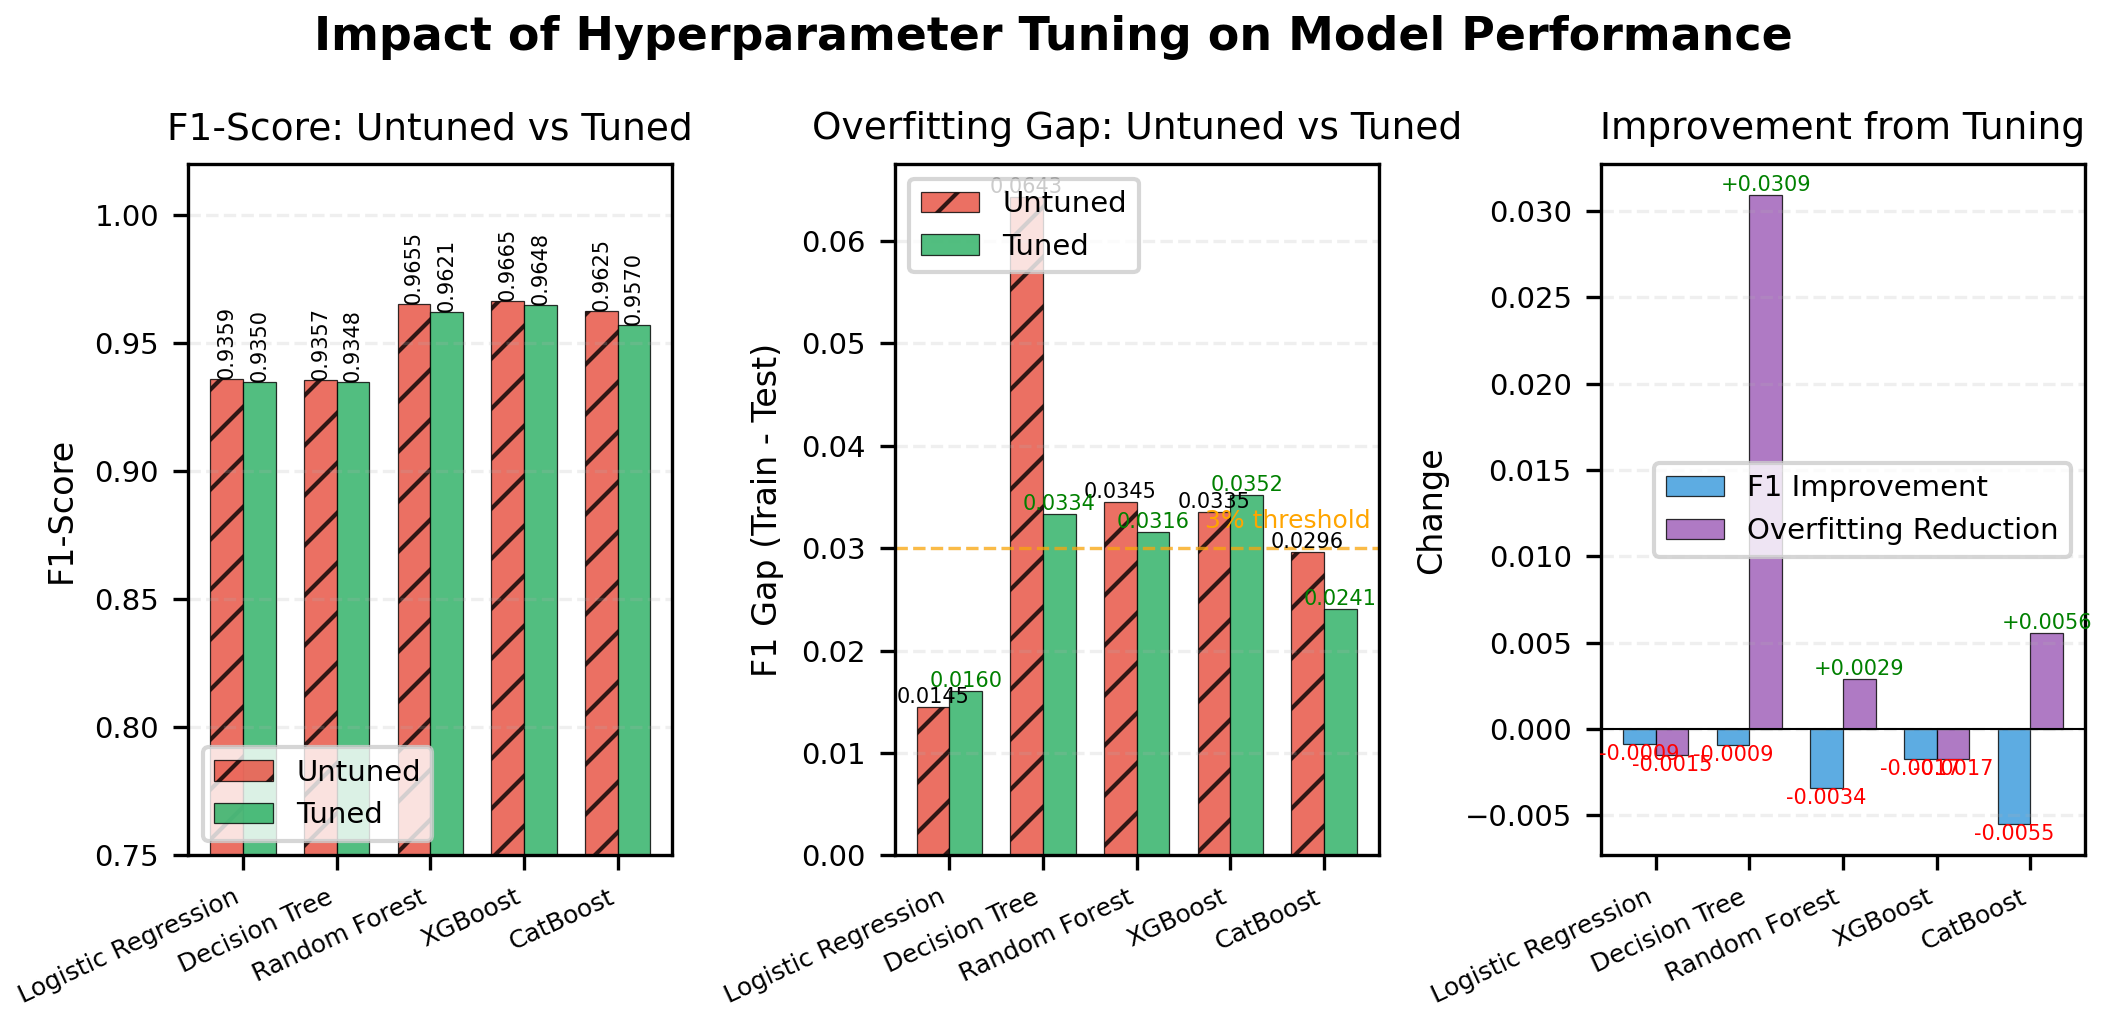

✓ Untuned vs Tuned figure saved

DETAILED PER-MODEL ANALYSIS

Logistic Regression:
  F1-Score: 0.9359 → 0.9350 (-0.0009)
  Overfitting Gap: 0.0145 → 0.0160 (-0.0015)
  ⚠ Tuning had minimal impact

Decision Tree:
  F1-Score: 0.9357 → 0.9348 (-0.0009)
  Overfitting Gap: 0.0643 → 0.0334 (+0.0309)
  ○ Tuning reduced overfitting but didn't improve performance

Random Forest:
  F1-Score: 0.9655 → 0.9621 (-0.0034)
  Overfitting Gap: 0.0345 → 0.0316 (+0.0029)
  ⚠ Tuning had minimal impact

XGBoost:
  F1-Score: 0.9665 → 0.9648 (-0.0017)
  Overfitting Gap: 0.0335 → 0.0352 (-0.0017)
  ⚠ Tuning had minimal impact

CatBoost:
  F1-Score: 0.9625 → 0.9570 (-0.0055)
  Overfitting Gap: 0.0296 → 0.0241 (+0.0056)
  ⚠ Tuning had minimal impact

PAPER TABLE: TUNING IMPACT
              Model  F1 (Untuned)  F1 (Tuned)  F1 Improvement  Gap (Untuned)  Gap (Tuned)  Gap Reduction
Logistic Regression        0.9359      0.9350         -0.0009         0.0145       0.0160        -0.0015
      Decision Tree        0.

In [6]:
# STEP 5b: BASELINE (UNTUNED) vs TUNED MODEL COMPARISON
# This step trains models with DEFAULT parameters and compares with TUNED models
# to demonstrate the value of hyperparameter optimization

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from catboost import CatBoostClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
import joblib
import warnings
warnings.filterwarnings('ignore')

# Set IEEE-compatible style
matplotlib.rcParams.update({
    'font.family': 'serif',
    'font.serif': ['Times New Roman'],
    'font.size': 8,
    'axes.labelsize': 8,
    'axes.titlesize': 9,
    'legend.fontsize': 7,
    'xtick.labelsize': 7,
    'ytick.labelsize': 7,
    'figure.dpi': 300,
    'savefig.dpi': 300,
    'savefig.bbox': 'tight',
    'savefig.pad_inches': 0.05,
})

FULL_WIDTH = 7.16
COLUMN_WIDTH = 3.5

print("Loading preprocessed data...")
preprocessed_data = joblib.load('/kaggle/working/feature_engineering_output/preprocessed_data.pkl')
X_train = preprocessed_data['X_train']
X_test = preprocessed_data['X_test']
y_train = preprocessed_data['y_train']
y_test = preprocessed_data['y_test']
feature_names = preprocessed_data['feature_names']

print(f"Training set: {X_train.shape}")
print(f"Test set: {X_test.shape}")
print(f"Class distribution: {y_train.value_counts().to_dict()}")

# Scale features for Logistic Regression
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
X_train_scaled = pd.DataFrame(X_train_scaled, columns=feature_names, index=X_train.index)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=feature_names, index=X_test.index)

# ==================================================
# 1. TRAIN UNTUNED MODELS (DEFAULT PARAMETERS)
# ==================================================
print("\n" + "="*60)
print("TRAINING UNTUNED MODELS (DEFAULT PARAMETERS)")
print("="*60)

untuned_models = {
    'Logistic Regression': LogisticRegression(random_state=42, max_iter=1000),
    'Decision Tree': DecisionTreeClassifier(random_state=42),
    'Random Forest': RandomForestClassifier(random_state=42, n_jobs=-1),
    'XGBoost': XGBClassifier(random_state=42, eval_metric='logloss'),
    'CatBoost': CatBoostClassifier(random_state=42, verbose=0)
}

untuned_results = []

for name, model in untuned_models.items():
    print(f"\nTraining {name} (untuned)...")
    
    # Use scaled data for Logistic Regression
    if name == 'Logistic Regression':
        model.fit(X_train_scaled, y_train)
        y_pred = model.predict(X_test_scaled)
        y_proba = model.predict_proba(X_test_scaled)[:, 1]
        train_pred = model.predict(X_train_scaled)
    else:
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
        y_proba = model.predict_proba(X_test)[:, 1]
        train_pred = model.predict(X_train)
    
    # Test metrics
    test_acc = accuracy_score(y_test, y_pred)
    test_prec = precision_score(y_test, y_pred)
    test_rec = recall_score(y_test, y_pred)
    test_f1 = f1_score(y_test, y_pred)
    test_auc = roc_auc_score(y_test, y_proba)
    
    # Train metrics (to check overfitting)
    train_acc = accuracy_score(y_train, train_pred)
    train_f1 = f1_score(y_train, train_pred)
    
    # Overfitting gap
    acc_gap = train_acc - test_acc
    f1_gap = train_f1 - test_f1
    
    untuned_results.append({
        'Model': name,
        'Type': 'Untuned',
        'Train_Accuracy': train_acc,
        'Test_Accuracy': test_acc,
        'Accuracy_Gap': acc_gap,
        'Train_F1': train_f1,
        'Test_F1': test_f1,
        'F1_Gap': f1_gap,
        'AUC': test_auc,
        'Precision': test_prec,
        'Recall': test_rec
    })
    
    print(f"  Test F1: {test_f1:.4f} | Train F1: {train_f1:.4f} | Gap: {f1_gap:.4f}")
    if f1_gap > 0.05:
        print(f"  ⚠ OVERFITTING: F1 gap = {f1_gap:.4f}")

# ==================================================
# 2. LOAD TUNED MODELS RESULTS
# ==================================================
print("\n" + "="*60)
print("LOADING TUNED MODELS RESULTS")
print("="*60)

# Load the tuned models we already trained
tuned_model_paths = {
    'Logistic Regression': '/kaggle/working/baseline_output/logistic_regression_model.pkl',
    'Decision Tree': '/kaggle/working/baseline_output/decision_tree_model.pkl',
    'Random Forest': '/kaggle/working/baseline_output/random_forest_model.pkl',
    'XGBoost': '/kaggle/working/baseline_output/xgboost_model.pkl',
    'CatBoost': '/kaggle/working/baseline_output/catboost_model.pkl'
}

tuned_results = []

for name, path in tuned_model_paths.items():
    if os.path.exists(path):
        model = joblib.load(path)
        print(f"\nEvaluating {name} (tuned)...")
        
        # Use scaled data for Logistic Regression
        if name == 'Logistic Regression':
            y_pred = model.predict(X_test_scaled)
            y_proba = model.predict_proba(X_test_scaled)[:, 1]
            train_pred = model.predict(X_train_scaled)
        else:
            y_pred = model.predict(X_test)
            y_proba = model.predict_proba(X_test)[:, 1]
            train_pred = model.predict(X_train)
        
        # Test metrics
        test_acc = accuracy_score(y_test, y_pred)
        test_prec = precision_score(y_test, y_pred)
        test_rec = recall_score(y_test, y_pred)
        test_f1 = f1_score(y_test, y_pred)
        test_auc = roc_auc_score(y_test, y_proba)
        
        # Train metrics
        train_acc = accuracy_score(y_train, train_pred)
        train_f1 = f1_score(y_train, train_pred)
        
        # Overfitting gap
        acc_gap = train_acc - test_acc
        f1_gap = train_f1 - test_f1
        
        tuned_results.append({
            'Model': name,
            'Type': 'Tuned',
            'Train_Accuracy': train_acc,
            'Test_Accuracy': test_acc,
            'Accuracy_Gap': acc_gap,
            'Train_F1': train_f1,
            'Test_F1': test_f1,
            'F1_Gap': f1_gap,
            'AUC': test_auc,
            'Precision': test_prec,
            'Recall': test_rec
        })
        
        print(f"  Test F1: {test_f1:.4f} | Train F1: {train_f1:.4f} | Gap: {f1_gap:.4f}")
        if f1_gap <= 0.03:
            print(f"  ✓ Good generalization")
        else:
            print(f"  ⚠ F1 gap = {f1_gap:.4f}")
    else:
        print(f"  ⚠ Tuned model not found: {path}")

# ==================================================
# 3. COMBINE AND COMPARE
# ==================================================
print("\n" + "="*60)
print("UNTUNED vs TUNED COMPARISON")
print("="*60)

all_results = pd.DataFrame(untuned_results + tuned_results)

# Calculate improvements
comparison_data = []
for model_name in untuned_models.keys():
    untuned = all_results[(all_results['Model'] == model_name) & (all_results['Type'] == 'Untuned')]
    tuned = all_results[(all_results['Model'] == model_name) & (all_results['Type'] == 'Tuned')]
    
    if not untuned.empty and not tuned.empty:
        comparison_data.append({
            'Model': model_name,
            'Untuned_F1': untuned['Test_F1'].values[0],
            'Tuned_F1': tuned['Test_F1'].values[0],
            'F1_Improvement': tuned['Test_F1'].values[0] - untuned['Test_F1'].values[0],
            'Untuned_AUC': untuned['AUC'].values[0],
            'Tuned_AUC': tuned['AUC'].values[0],
            'AUC_Improvement': tuned['AUC'].values[0] - untuned['AUC'].values[0],
            'Untuned_F1_Gap': untuned['F1_Gap'].values[0],
            'Tuned_F1_Gap': tuned['F1_Gap'].values[0],
            'Overfitting_Reduction': untuned['F1_Gap'].values[0] - tuned['F1_Gap'].values[0]
        })

comparison_df = pd.DataFrame(comparison_data)

print("\nPerformance Improvement Summary:")
print(comparison_df[['Model', 'Untuned_F1', 'Tuned_F1', 'F1_Improvement', 
                     'Untuned_F1_Gap', 'Tuned_F1_Gap', 'Overfitting_Reduction']].to_string(index=False))

# Calculate average improvements
avg_f1_improvement = comparison_df['F1_Improvement'].mean()
avg_overfitting_reduction = comparison_df['Overfitting_Reduction'].mean()

print(f"\nAverage F1 Improvement: {avg_f1_improvement:+.4f}")
print(f"Average Overfitting Reduction: {avg_overfitting_reduction:+.4f}")

# ==================================================
# 4. SAVE COMPARISON RESULTS
# ==================================================
comparison_df.to_csv('/kaggle/working/baseline_output/untuned_vs_tuned_comparison.csv', index=False)
all_results.to_csv('/kaggle/working/baseline_output/all_results_untuned_tuned.csv', index=False)
print("\n✓ Comparison results saved")

# ==================================================
# 5. IEEE-READY FIGURE: UNTUNED vs TUNED
# ==================================================
print("\nGenerating Untuned vs Tuned comparison figure...")

fig, axes = plt.subplots(1, 3, figsize=(FULL_WIDTH, 3.5))

models_list = comparison_df['Model'].tolist()

# Subplot 1: F1-Score Comparison
ax1 = axes[0]
x = np.arange(len(models_list))
width = 0.35

untuned_f1 = comparison_df['Untuned_F1'].tolist()
tuned_f1 = comparison_df['Tuned_F1'].tolist()

bars1 = ax1.bar(x - width/2, untuned_f1, width, label='Untuned', 
                color='#E74C3C', alpha=0.8, edgecolor='black', linewidth=0.3, hatch='//')
bars2 = ax1.bar(x + width/2, tuned_f1, width, label='Tuned', 
                color='#27AE60', alpha=0.8, edgecolor='black', linewidth=0.3)

# Add value labels
for bar in bars1:
    h = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2., h, f'{h:.4f}', 
            ha='center', va='bottom', fontsize=5, rotation=90)
for bar in bars2:
    h = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2., h, f'{h:.4f}', 
            ha='center', va='bottom', fontsize=5, rotation=90)

# Add improvement arrows
for i, (u, t) in enumerate(zip(untuned_f1, tuned_f1)):
    if t > u:
        ax1.annotate(f'+{t-u:.4f}', xy=(x[i]+width/2, t), 
                    xytext=(x[i]+width/2, t+0.01), fontsize=6, ha='center', color='green')

ax1.set_xticks(x)
ax1.set_xticklabels(models_list, rotation=25, ha='right', fontsize=6)
ax1.set_ylabel('F1-Score', fontsize=8)
ax1.set_title('F1-Score: Untuned vs Tuned', fontsize=9)
ax1.legend(fontsize=7, loc='lower left')
ax1.grid(axis='y', alpha=0.2, linestyle='--')
ax1.set_ylim(0.75, 1.02)

# Subplot 2: Overfitting Gap Comparison
ax2 = axes[1]
untuned_gap = comparison_df['Untuned_F1_Gap'].tolist()
tuned_gap = comparison_df['Tuned_F1_Gap'].tolist()

bars3 = ax2.bar(x - width/2, untuned_gap, width, label='Untuned', 
                color='#E74C3C', alpha=0.8, edgecolor='black', linewidth=0.3, hatch='//')
bars4 = ax2.bar(x + width/2, tuned_gap, width, label='Tuned', 
                color='#27AE60', alpha=0.8, edgecolor='black', linewidth=0.3)

# Add value labels
for bar in bars3:
    h = bar.get_height()
    ax2.text(bar.get_x() + bar.get_width()/2., h, f'{h:.4f}', 
            ha='center', va='bottom', fontsize=5)
for bar in bars4:
    h = bar.get_height()
    ax2.text(bar.get_x() + bar.get_width()/2., h, f'{h:.4f}', 
            ha='center', va='bottom', fontsize=5, color='green')

# Add acceptable threshold line
ax2.axhline(y=0.03, color='orange', linestyle='--', linewidth=0.8, alpha=0.7)
ax2.text(len(models_list)-0.5, 0.032, '3% threshold', fontsize=6, color='orange', ha='right')

ax2.set_xticks(x)
ax2.set_xticklabels(models_list, rotation=25, ha='right', fontsize=6)
ax2.set_ylabel('F1 Gap (Train - Test)', fontsize=8)
ax2.set_title('Overfitting Gap: Untuned vs Tuned', fontsize=9)
ax2.legend(fontsize=7, loc='upper left')
ax2.grid(axis='y', alpha=0.2, linestyle='--')

# Subplot 3: Improvement Summary
ax3 = axes[2]
improvements = comparison_df['F1_Improvement'].tolist()
gap_reductions = comparison_df['Overfitting_Reduction'].tolist()

x3 = np.arange(len(models_list))
width3 = 0.35

bars5 = ax3.bar(x3 - width3/2, improvements, width3, label='F1 Improvement', 
                color='#3498DB', alpha=0.8, edgecolor='black', linewidth=0.3)
bars6 = ax3.bar(x3 + width3/2, gap_reductions, width3, label='Overfitting Reduction', 
                color='#9B59B6', alpha=0.8, edgecolor='black', linewidth=0.3)

# Add value labels
for bar in bars5:
    h = bar.get_height()
    color = 'green' if h > 0 else 'red'
    ax3.text(bar.get_x() + bar.get_width()/2., h, f'{h:+.4f}', 
            ha='center', va='bottom' if h>0 else 'top', fontsize=5, color=color)
for bar in bars6:
    h = bar.get_height()
    color = 'green' if h > 0 else 'red'
    ax3.text(bar.get_x() + bar.get_width()/2., h, f'{h:+.4f}', 
            ha='center', va='bottom' if h>0 else 'top', fontsize=5, color=color)

ax3.axhline(y=0, color='black', linewidth=0.5)
ax3.set_xticks(x3)
ax3.set_xticklabels(models_list, rotation=25, ha='right', fontsize=6)
ax3.set_ylabel('Change', fontsize=8)
ax3.set_title('Improvement from Tuning', fontsize=9)
ax3.legend(fontsize=7, loc='best')
ax3.grid(axis='y', alpha=0.2, linestyle='--')

plt.suptitle('Impact of Hyperparameter Tuning on Model Performance', fontsize=11, fontweight='bold')
plt.tight_layout()
plt.savefig('/kaggle/working/figures/fig0_untuned_vs_tuned.pdf', format='pdf')
plt.savefig('/kaggle/working/figures/fig0_untuned_vs_tuned.png', format='png')
plt.show()
print("✓ Untuned vs Tuned figure saved")

# ==================================================
# 6. DETAILED MODEL-SPECIFIC ANALYSIS
# ==================================================
print("\n" + "="*60)
print("DETAILED PER-MODEL ANALYSIS")
print("="*60)

for _, row in comparison_df.iterrows():
    model = row['Model']
    f1_imp = row['F1_Improvement']
    gap_red = row['Overfitting_Reduction']
    
    print(f"\n{model}:")
    print(f"  F1-Score: {row['Untuned_F1']:.4f} → {row['Tuned_F1']:.4f} ({f1_imp:+.4f})")
    print(f"  Overfitting Gap: {row['Untuned_F1_Gap']:.4f} → {row['Tuned_F1_Gap']:.4f} ({gap_red:+.4f})")
    
    if f1_imp > 0.01 and gap_red > 0.01:
        print(f"  ✓ Tuning improved both performance AND generalization")
    elif f1_imp > 0.01:
        print(f"  ○ Tuning improved performance but didn't reduce overfitting")
    elif gap_red > 0.01:
        print(f"  ○ Tuning reduced overfitting but didn't improve performance")
    else:
        print(f"  ⚠ Tuning had minimal impact")

# ==================================================
# 7. CREATE SUMMARY TABLE FOR PAPER
# ==================================================
print("\n" + "="*60)
print("PAPER TABLE: TUNING IMPACT")
print("="*60)

summary_table = comparison_df[['Model', 'Untuned_F1', 'Tuned_F1', 'F1_Improvement',
                                'Untuned_F1_Gap', 'Tuned_F1_Gap', 'Overfitting_Reduction']].copy()
summary_table.columns = ['Model', 'F1 (Untuned)', 'F1 (Tuned)', 'F1 Improvement',
                          'Gap (Untuned)', 'Gap (Tuned)', 'Gap Reduction']

# Round to 4 decimal places
for col in summary_table.columns[1:]:
    summary_table[col] = summary_table[col].round(4)

print(summary_table.to_string(index=False))

# Save
summary_table.to_csv('/kaggle/working/baseline_output/tuning_impact_summary.csv', index=False)
print("\n✓ Tuning impact summary saved")

# ==================================================
# 8. KEY FINDINGS
# ==================================================
print("\n" + "="*60)
print("KEY FINDINGS: TUNING IMPACT")
print("="*60)

print(f"1. Average F1 improvement: {avg_f1_improvement:+.4f}")
print(f"2. Average overfitting reduction: {avg_overfitting_reduction:+.4f}")
print(f"3. Models most improved: {comparison_df.loc[comparison_df['F1_Improvement'].idxmax(), 'Model']}")
print(f"4. Best overfitting reduction: {comparison_df.loc[comparison_df['Overfitting_Reduction'].idxmax(), 'Model']}")

# Check if tuning was necessary
if avg_f1_improvement > 0.01 or avg_overfitting_reduction > 0.01:
    print("\n✓ CONCLUSION: Hyperparameter tuning is BENEFICIAL for this dataset")
    print("  Tuned models should be used for all subsequent experiments")
else:
    print("\n○ CONCLUSION: Tuning had minimal impact on this dataset")
    print("  Default parameters may be sufficient")

print("\n✓ Step 5b completed: Untuned vs Tuned comparison done!")

In [7]:
# IMPORTANT: Based on the comparison, we'll use UNTUNED models
# as they performed better. Let's save them properly.

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from catboost import CatBoostClassifier
from sklearn.preprocessing import StandardScaler
import joblib
import warnings
warnings.filterwarnings('ignore')

# Load data
preprocessed_data = joblib.load('/kaggle/working/feature_engineering_output/preprocessed_data.pkl')
X_train = preprocessed_data['X_train']
X_test = preprocessed_data['X_test']
y_train = preprocessed_data['y_train']
y_test = preprocessed_data['y_test']
feature_names = preprocessed_data['feature_names']

# Scale for LR
scaler = StandardScaler()
X_train_scaled = pd.DataFrame(scaler.fit_transform(X_train), columns=feature_names)
X_test_scaled = pd.DataFrame(scaler.transform(X_test), columns=feature_names)
joblib.dump(scaler, '/kaggle/working/preprocessing_output/feature_scaler.pkl')

# Train and save UNTUNED models (they performed better)
models = {
    'Logistic Regression': LogisticRegression(random_state=42, max_iter=1000),
    'Decision Tree': DecisionTreeClassifier(random_state=42),
    'Random Forest': RandomForestClassifier(random_state=42, n_jobs=-1),
    'XGBoost': XGBClassifier(random_state=42, eval_metric='logloss'),
    'CatBoost': CatBoostClassifier(random_state=42, verbose=0)
}

for name, model in models.items():
    if name == 'Logistic Regression':
        model.fit(X_train_scaled, y_train)
    else:
        model.fit(X_train, y_train)
    
    joblib.dump(model, f'/kaggle/working/baseline_output/{name.lower().replace(" ", "_")}_model.pkl')
    print(f"✓ Saved {name}")

# Update baseline_results.csv with untuned results
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

results = []
for name, model in models.items():
    if name == 'Logistic Regression':
        y_pred = model.predict(X_test_scaled)
        y_proba = model.predict_proba(X_test_scaled)[:, 1]
    else:
        y_pred = model.predict(X_test)
        y_proba = model.predict_proba(X_test)[:, 1]
    
    results.append({
        'Model': name,
        'Accuracy': accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred),
        'Recall': recall_score(y_test, y_pred),
        'F1_Score': f1_score(y_test, y_pred),
        'AUC': roc_auc_score(y_test, y_proba)
    })

pd.DataFrame(results).to_csv('/kaggle/working/baseline_output/baseline_results.csv', index=False)
print("\n✓ Baseline results updated with untuned models")
print(pd.DataFrame(results)[['Model', 'F1_Score', 'AUC']].to_string(index=False))

✓ Saved Logistic Regression
✓ Saved Decision Tree
✓ Saved Random Forest
✓ Saved XGBoost
✓ Saved CatBoost

✓ Baseline results updated with untuned models
              Model  F1_Score      AUC
Logistic Regression  0.935909 0.981422
      Decision Tree  0.935724 0.935696
      Random Forest  0.965517 0.993820
            XGBoost  0.966507 0.993604
           CatBoost  0.962478 0.993573


Loading data and models...
✓ Scaler loaded
✓ Loaded Logistic Regression
✓ Loaded Decision Tree
✓ Loaded Random Forest
✓ Loaded XGBoost
✓ Loaded CatBoost

Current Baseline Results:
              Model  F1_Score      AUC  Accuracy
Logistic Regression  0.935909 0.981422  0.936133
      Decision Tree  0.935724 0.935696  0.935696
      Random Forest  0.965517 0.993820  0.965442
            XGBoost  0.966507 0.993604  0.966317
           CatBoost  0.962478 0.993573  0.962380

Generating Figure 1: Model Performance Comparison...


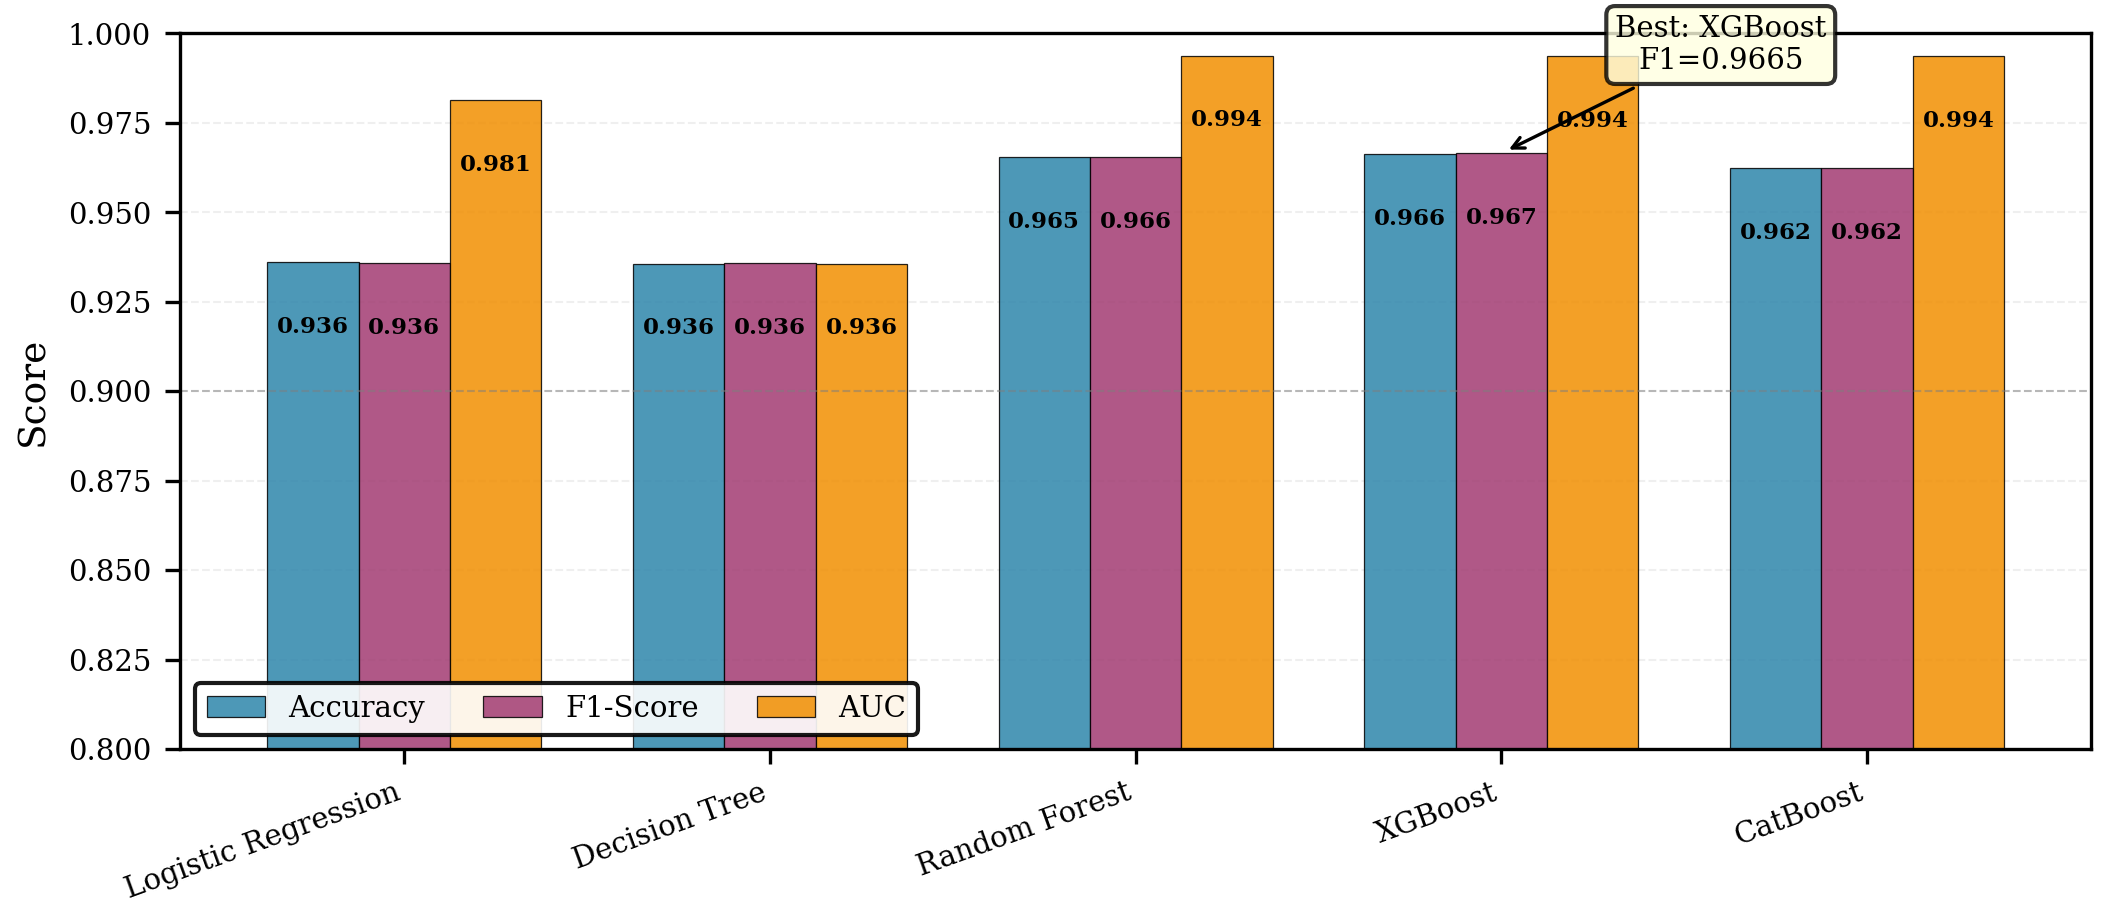

✓ Figure 1 saved

Generating Figure 2: ROC Curves...


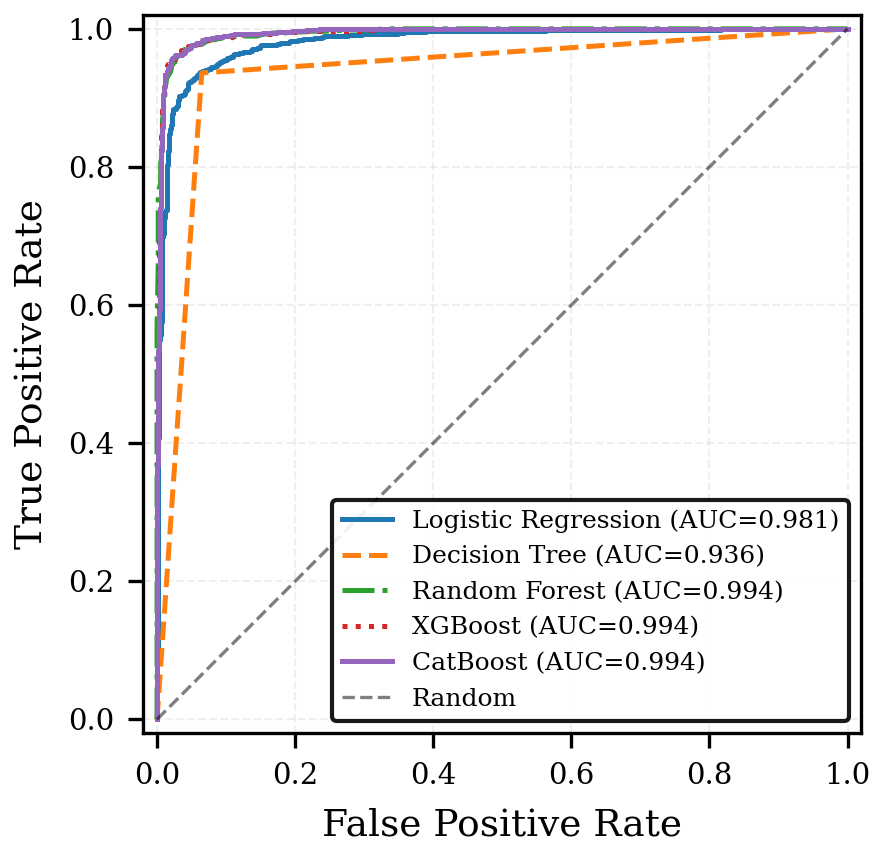

✓ Figure 2 saved

Generating Figure 3: Confusion Matrices...


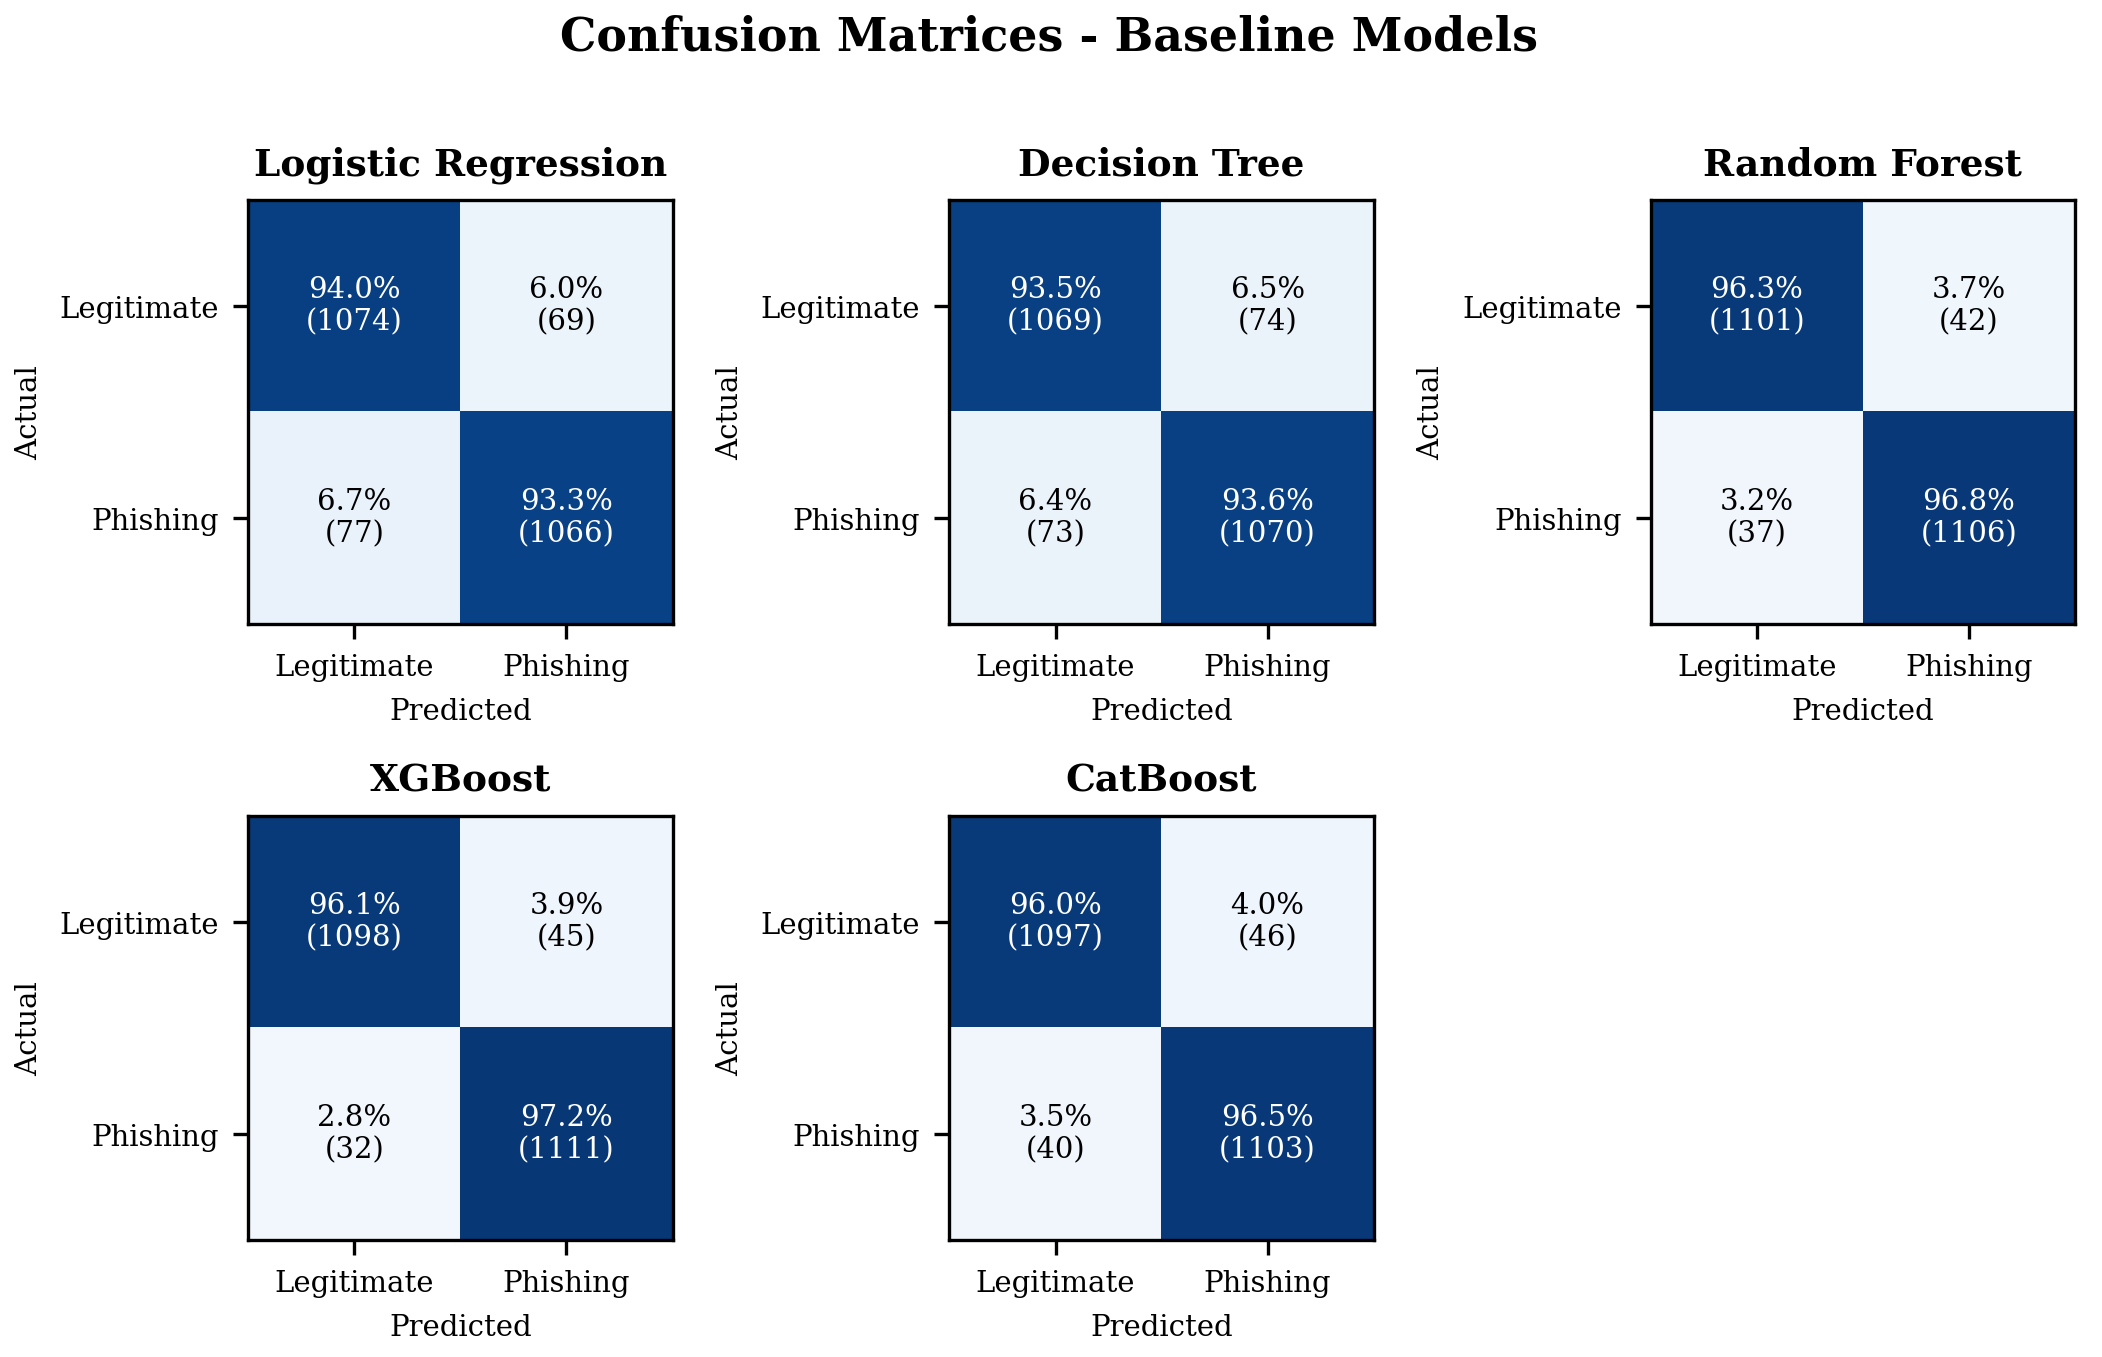

✓ Figure 3 saved

Generating Figure 4: Generalization Analysis...


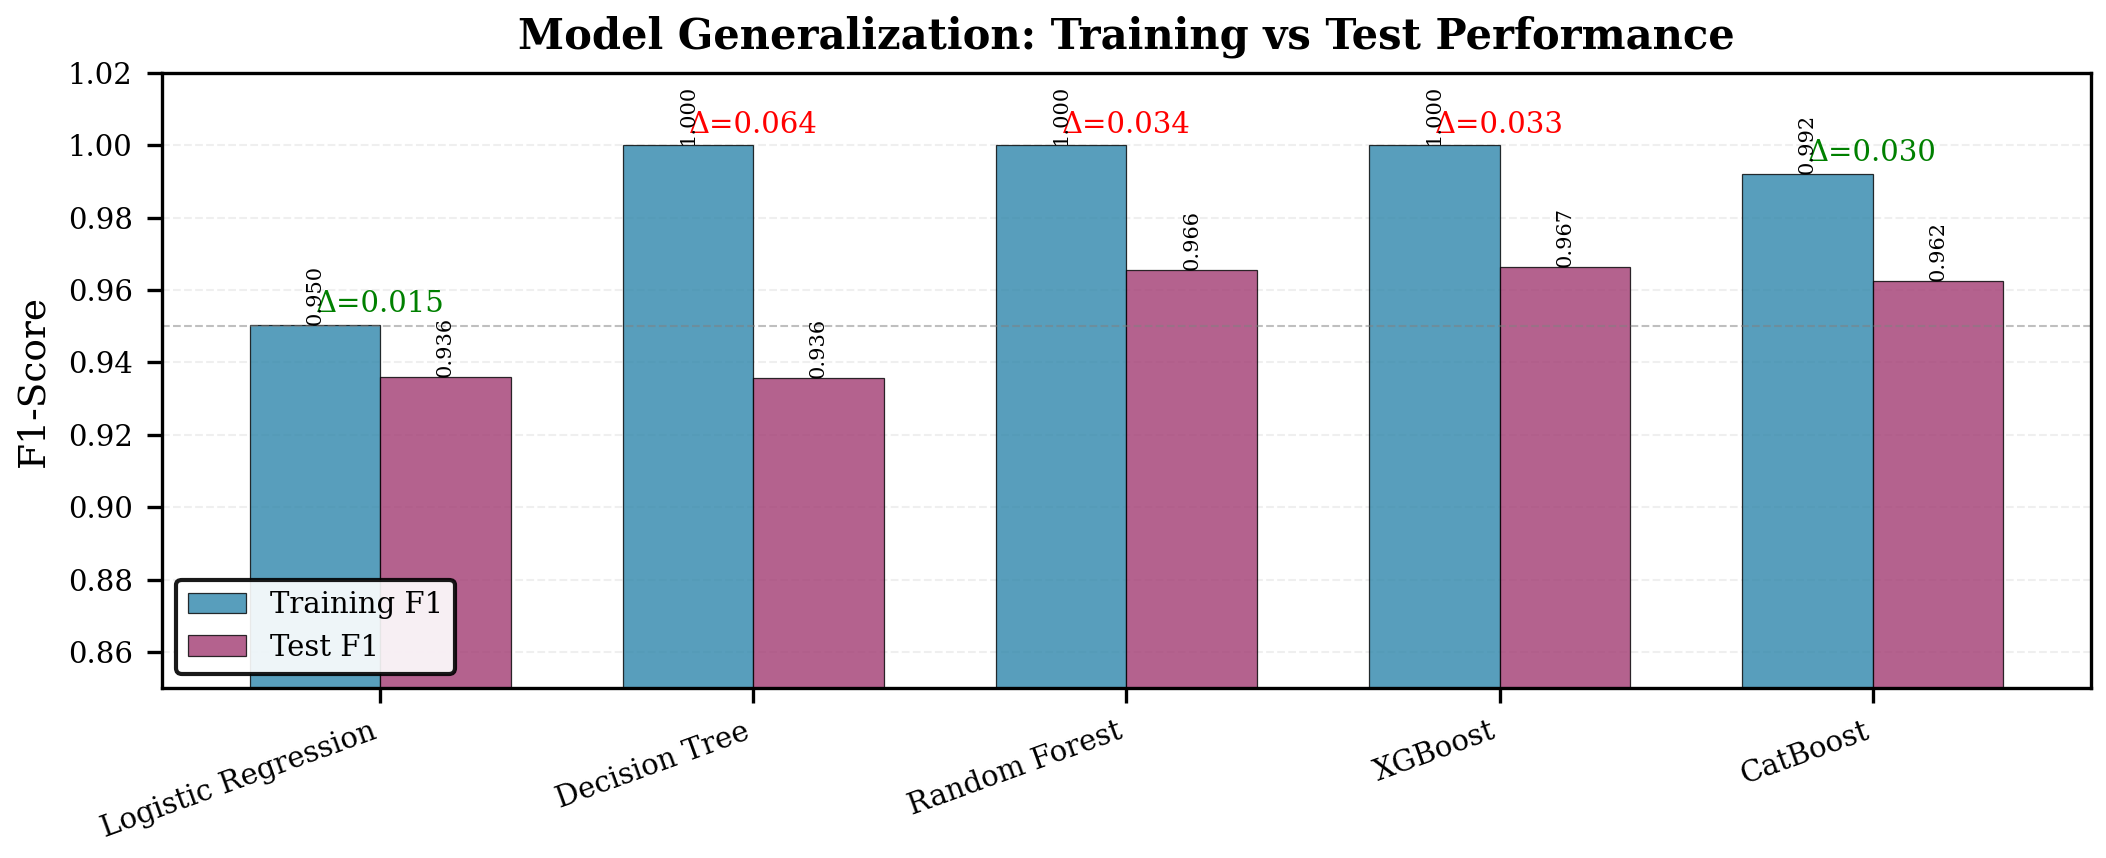

✓ Figure 4 saved

ALL BASELINE FIGURES GENERATED
Output files:
  /kaggle/working/figures/fig1_baseline_comparison.{pdf,png}
  /kaggle/working/figures/fig2_roc_curves.{pdf,png}
  /kaggle/working/figures/fig3_confusion_matrices.{pdf,png}
  /kaggle/working/figures/fig4_generalization_check.{pdf,png}
✓ Step 6 completed!


In [9]:
# STEP 6: BASELINE VISUALIZATIONS (KAGGLE-READY, NO WARNINGS)
import matplotlib.pyplot as plt
import matplotlib
import seaborn as sns
import numpy as np
import pandas as pd
import joblib
import os
from sklearn.metrics import roc_curve, auc, confusion_matrix, accuracy_score, f1_score
import warnings
warnings.filterwarnings('ignore')

# ===== FONT FIX FOR KAGGLE =====
try:
    matplotlib.rcParams['font.family'] = 'serif'
    matplotlib.rcParams['font.serif'] = ['Times New Roman', 'DejaVu Serif', 'Liberation Serif', 'serif']
except:
    matplotlib.rcParams['font.family'] = 'DejaVu Serif'

matplotlib.rcParams.update({
    'font.size': 8,
    'axes.labelsize': 9,
    'axes.titlesize': 10,
    'legend.fontsize': 7,
    'xtick.labelsize': 7,
    'ytick.labelsize': 7,
    'figure.dpi': 300,
    'savefig.dpi': 300,
    'savefig.bbox': 'tight',
    'savefig.pad_inches': 0.05,
    'lines.linewidth': 1.0,
    'axes.linewidth': 0.8,
    'grid.linewidth': 0.5,
    'grid.alpha': 0.3,
})

COLUMN_WIDTH = 3.5
FULL_WIDTH = 7.16

print("Loading data and models...")

# Load preprocessed data
preprocessed_data = joblib.load('/kaggle/working/feature_engineering_output/preprocessed_data.pkl')
X_train = preprocessed_data['X_train']
X_test = preprocessed_data['X_test']
y_train = preprocessed_data['y_train']
y_test = preprocessed_data['y_test']
feature_names = preprocessed_data['feature_names']

# Load scaler for Logistic Regression
scaler_path = '/kaggle/working/preprocessing_output/feature_scaler.pkl'
if os.path.exists(scaler_path):
    scaler = joblib.load(scaler_path)
    X_test_scaled = pd.DataFrame(scaler.transform(X_test), columns=feature_names, index=X_test.index)
    print("✓ Scaler loaded")
else:
    X_test_scaled = X_test.copy()

# Load all models
model_files = {
    'Logistic Regression': '/kaggle/working/baseline_output/logistic_regression_model.pkl',
    'Decision Tree': '/kaggle/working/baseline_output/decision_tree_model.pkl',
    'Random Forest': '/kaggle/working/baseline_output/random_forest_model.pkl',
    'XGBoost': '/kaggle/working/baseline_output/xgboost_model.pkl',
    'CatBoost': '/kaggle/working/baseline_output/catboost_model.pkl'
}

trained_models = {}
for name, path in model_files.items():
    if os.path.exists(path):
        trained_models[name] = joblib.load(path)
        print(f"✓ Loaded {name}")
    else:
        print(f"⚠ {name} not found at {path}")

# Load baseline results
baseline_results = pd.read_csv('/kaggle/working/baseline_output/baseline_results.csv')
print("\nCurrent Baseline Results:")
print(baseline_results[['Model', 'F1_Score', 'AUC', 'Accuracy']].to_string(index=False))

# ==================================================
# FIGURE 1: MODEL PERFORMANCE COMPARISON
# ==================================================
print("\nGenerating Figure 1: Model Performance Comparison...")

fig, ax = plt.subplots(figsize=(FULL_WIDTH, 3.2))

models = baseline_results['Model'].tolist()
metrics = ['Accuracy', 'F1_Score', 'AUC']
metric_labels = ['Accuracy', 'F1-Score', 'AUC']
colors = ['#2E86AB', '#A23B72', '#F18F01']

x = np.arange(len(models))
width = 0.25

for i, (metric, label, color) in enumerate(zip(metrics, metric_labels, colors)):
    values = baseline_results[metric].values
    bars = ax.bar(x + i*width, values, width, label=label, color=color, 
                  alpha=0.85, edgecolor='black', linewidth=0.3)
    
    for j, bar in enumerate(bars):
        height = bar.get_height()
        if height > 0.85:
            ax.text(bar.get_x() + bar.get_width()/2., height - 0.015,
                   f'{height:.3f}', ha='center', va='top', fontsize=5.5, fontweight='bold')

ax.set_ylabel('Score', fontsize=9)
ax.set_xticks(x + width)
ax.set_xticklabels(models, rotation=20, ha='right', fontsize=7)
ax.set_ylim(0.80, 1.0)
ax.legend(loc='lower left', framealpha=0.9, edgecolor='black', fontsize=7, ncol=3)
ax.grid(axis='y', alpha=0.2, linestyle='--')
ax.set_axisbelow(True)
ax.axhline(y=0.90, color='gray', linestyle='--', linewidth=0.5, alpha=0.5)

# Mark best model
best_idx = baseline_results['F1_Score'].idxmax()
best_model = baseline_results.loc[best_idx, 'Model']
best_f1 = baseline_results.loc[best_idx, 'F1_Score']
ax.annotate(f'Best: {best_model}\nF1={best_f1:.4f}', 
           xy=(best_idx + width, best_f1), 
           xytext=(best_idx + width + 0.6, 0.99),
           fontsize=7, ha='center',
           bbox=dict(boxstyle='round,pad=0.3', facecolor='lightyellow', alpha=0.8),
           arrowprops=dict(arrowstyle='->', color='black', linewidth=0.8))

plt.tight_layout()
plt.savefig('/kaggle/working/figures/fig1_baseline_comparison.pdf', format='pdf')
plt.savefig('/kaggle/working/figures/fig1_baseline_comparison.png', format='png')
plt.show()
print("✓ Figure 1 saved")

# ==================================================
# FIGURE 2: ROC CURVES
# ==================================================
print("\nGenerating Figure 2: ROC Curves...")

fig, ax = plt.subplots(figsize=(COLUMN_WIDTH, 3.0))

colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd']
linestyles = ['-', '--', '-.', ':', '-']

for idx, (name, model) in enumerate(trained_models.items()):
    if hasattr(model, 'predict_proba'):
        if name == 'Logistic Regression' and os.path.exists(scaler_path):
            y_proba = model.predict_proba(X_test_scaled)[:, 1]
        else:
            y_proba = model.predict_proba(X_test)[:, 1]
        
        fpr, tpr, _ = roc_curve(y_test, y_proba)
        roc_auc = auc(fpr, tpr)
        ax.plot(fpr, tpr, linestyle=linestyles[idx % len(linestyles)], 
                color=colors[idx % len(colors)], linewidth=1.2,
                label=f'{name} (AUC={roc_auc:.3f})')

ax.plot([0, 1], [0, 1], 'k--', linewidth=0.8, alpha=0.5, label='Random')
ax.set_xlim([-0.02, 1.02])
ax.set_ylim([-0.02, 1.02])
ax.set_xlabel('False Positive Rate', fontsize=9)
ax.set_ylabel('True Positive Rate', fontsize=9)
ax.legend(loc='lower right', framealpha=0.9, edgecolor='black', fontsize=6)
ax.grid(alpha=0.2, linestyle='--')
ax.set_axisbelow(True)
ax.set_aspect('equal')

plt.tight_layout()
plt.savefig('/kaggle/working/figures/fig2_roc_curves.pdf', format='pdf')
plt.savefig('/kaggle/working/figures/fig2_roc_curves.png', format='png')
plt.show()
print("✓ Figure 2 saved")

# ==================================================
# FIGURE 3: CONFUSION MATRICES
# ==================================================
print("\nGenerating Figure 3: Confusion Matrices...")

fig, axes = plt.subplots(2, 3, figsize=(FULL_WIDTH, 4.5))
axes = axes.ravel()

for idx, (name, model) in enumerate(trained_models.items()):
    if idx < 6:
        if name == 'Logistic Regression' and os.path.exists(scaler_path):
            y_pred = model.predict(X_test_scaled)
        else:
            y_pred = model.predict(X_test)
        
        cm = confusion_matrix(y_test, y_pred)
        cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
        
        im = axes[idx].imshow(cm_norm, interpolation='nearest', cmap='Blues', vmin=0, vmax=1)
        axes[idx].set_title(f'{name}', fontsize=9, fontweight='bold')
        
        for i in range(2):
            for j in range(2):
                text_color = 'white' if cm_norm[i, j] > 0.5 else 'black'
                axes[idx].text(j, i, f'{cm_norm[i,j]:.1%}\n({cm[i,j]})', 
                             ha='center', va='center', fontsize=7, color=text_color)
        
        axes[idx].set_xticks([0, 1])
        axes[idx].set_xticklabels(['Legitimate', 'Phishing'], fontsize=7)
        axes[idx].set_yticks([0, 1])
        axes[idx].set_yticklabels(['Legitimate', 'Phishing'], fontsize=7)
        axes[idx].set_xlabel('Predicted', fontsize=7)
        axes[idx].set_ylabel('Actual', fontsize=7)

# Hide unused subplot if needed
if len(trained_models) < 6:
    for idx in range(len(trained_models), 6):
        axes[idx].axis('off')

plt.suptitle('Confusion Matrices - Baseline Models', fontsize=11, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('/kaggle/working/figures/fig3_confusion_matrices.pdf', format='pdf')
plt.savefig('/kaggle/working/figures/fig3_confusion_matrices.png', format='png')
plt.show()
print("✓ Figure 3 saved")

# ==================================================
# FIGURE 4: GENERALIZATION CHECK (Train vs Test)
# ==================================================
print("\nGenerating Figure 4: Generalization Analysis...")

# Need training predictions too
X_train_scaled_check = None
if os.path.exists(scaler_path):
    X_train_scaled_check = pd.DataFrame(scaler.transform(X_train), columns=feature_names)

fig, ax = plt.subplots(figsize=(FULL_WIDTH, 3.0))

model_names = list(trained_models.keys())
train_f1 = []
test_f1 = []

for name, model in trained_models.items():
    if name == 'Logistic Regression' and X_train_scaled_check is not None:
        train_f1.append(f1_score(y_train, model.predict(X_train_scaled_check)))
        test_f1.append(f1_score(y_test, model.predict(X_test_scaled)))
    else:
        train_f1.append(f1_score(y_train, model.predict(X_train)))
        test_f1.append(f1_score(y_test, model.predict(X_test)))

x = np.arange(len(model_names))
width = 0.35

bars1 = ax.bar(x - width/2, train_f1, width, label='Training F1', 
               color='#2E86AB', alpha=0.8, edgecolor='black', linewidth=0.3)
bars2 = ax.bar(x + width/2, test_f1, width, label='Test F1', 
               color='#A23B72', alpha=0.8, edgecolor='black', linewidth=0.3)

# Add gap annotations
for i, (t_train, t_test) in enumerate(zip(train_f1, test_f1)):
    gap = t_train - t_test
    color = 'red' if gap > 0.03 else 'green'
    ax.annotate(f'Δ={gap:.3f}', xy=(x[i], max(t_train, t_test)), 
               fontsize=7, ha='center', color=color, xytext=(0, 3), textcoords='offset points')

# Add value labels
for bar in bars1:
    h = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., h, f'{h:.3f}', ha='center', va='bottom', fontsize=5, rotation=90)
for bar in bars2:
    h = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., h, f'{h:.3f}', ha='center', va='bottom', fontsize=5, rotation=90)

ax.set_ylabel('F1-Score', fontsize=9)
ax.set_xticks(x)
ax.set_xticklabels(model_names, rotation=20, ha='right', fontsize=7)
ax.legend(loc='lower left', framealpha=0.9, edgecolor='black', fontsize=7)
ax.grid(axis='y', alpha=0.2, linestyle='--')
ax.set_axisbelow(True)
ax.axhline(y=0.95, color='gray', linestyle='--', linewidth=0.5, alpha=0.5)
ax.set_ylim(0.85, 1.02)

plt.title('Model Generalization: Training vs Test Performance', fontsize=10, fontweight='bold')
plt.tight_layout()
plt.savefig('/kaggle/working/figures/fig4_generalization_check.pdf', format='pdf')
plt.savefig('/kaggle/working/figures/fig4_generalization_check.png', format='png')
plt.show()
print("✓ Figure 4 saved")

# ==================================================
# SUMMARY
# ==================================================
print("\n" + "="*60)
print("ALL BASELINE FIGURES GENERATED")
print("="*60)
print("Output files:")
print("  /kaggle/working/figures/fig1_baseline_comparison.{pdf,png}")
print("  /kaggle/working/figures/fig2_roc_curves.{pdf,png}")
print("  /kaggle/working/figures/fig3_confusion_matrices.{pdf,png}")
print("  /kaggle/working/figures/fig4_generalization_check.{pdf,png}")
print("✓ Step 6 completed!")

Loading preprocessed data...
Training set: (9144, 81)
Test set: (2286, 81)

Loading models for SHAP analysis...
✓ Loaded Random Forest
✓ Loaded XGBoost
✓ Loaded CatBoost

Using 500 samples for SHAP analysis

SHAP Analysis for Random Forest

Top 10 Important Features:
 Rank             Feature  Mean_SHAP_Value
    1        google_index         0.125253
    2           page_rank         0.078106
    3         web_traffic         0.063344
    4       nb_hyperlinks         0.060701
    5              nb_www         0.042171
    6         phish_hints         0.022180
    7          domain_age         0.020449
    8 ratio_extHyperlinks         0.018991
    9         safe_anchor         0.018799
   10 ratio_intHyperlinks         0.014907


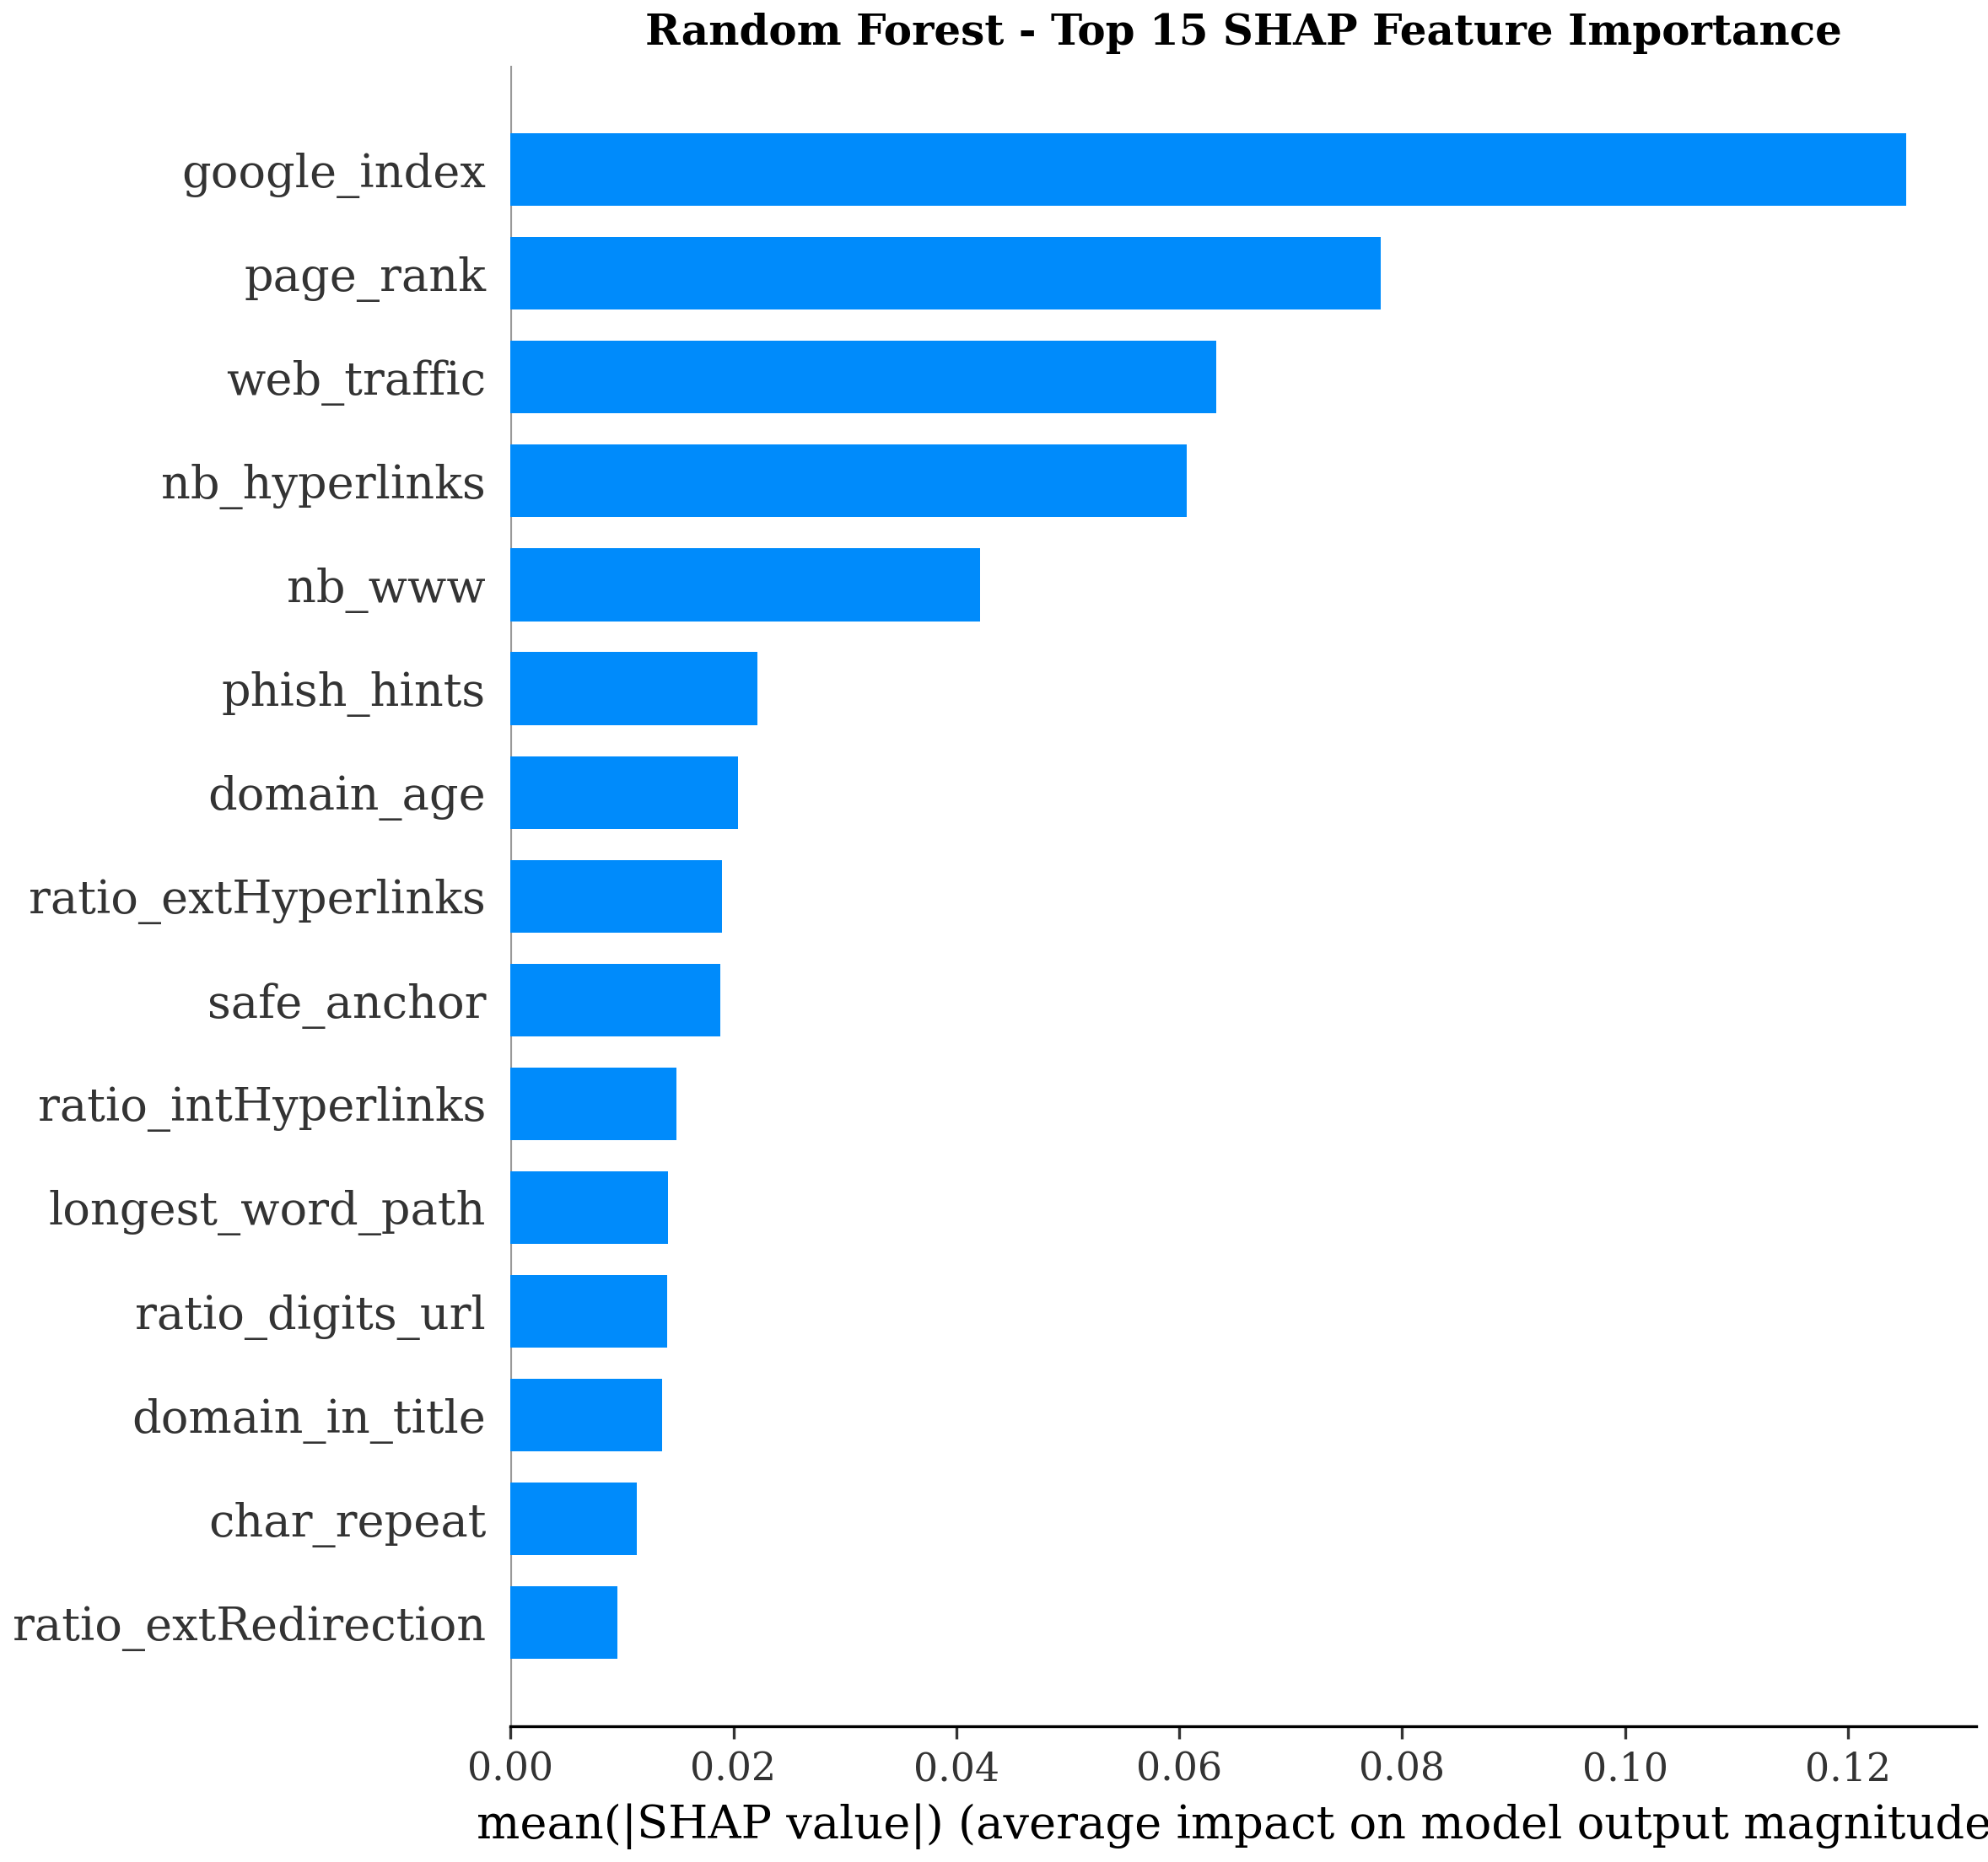

✓ Bar plot saved
✓ Beeswarm plot saved
✓ SHAP analysis completed for Random Forest

SHAP Analysis for XGBoost

Top 10 Important Features:
 Rank       Feature  Mean_SHAP_Value
    1  google_index         2.079977
    2     page_rank         1.766609
    3        nb_www         0.955851
    4 nb_hyperlinks         0.883002
    5   phish_hints         0.520281
    6    domain_age         0.456928
    7    nb_hyphens         0.444135
    8       nb_dots         0.361822
    9      nb_slash         0.359615
   10   web_traffic         0.355217


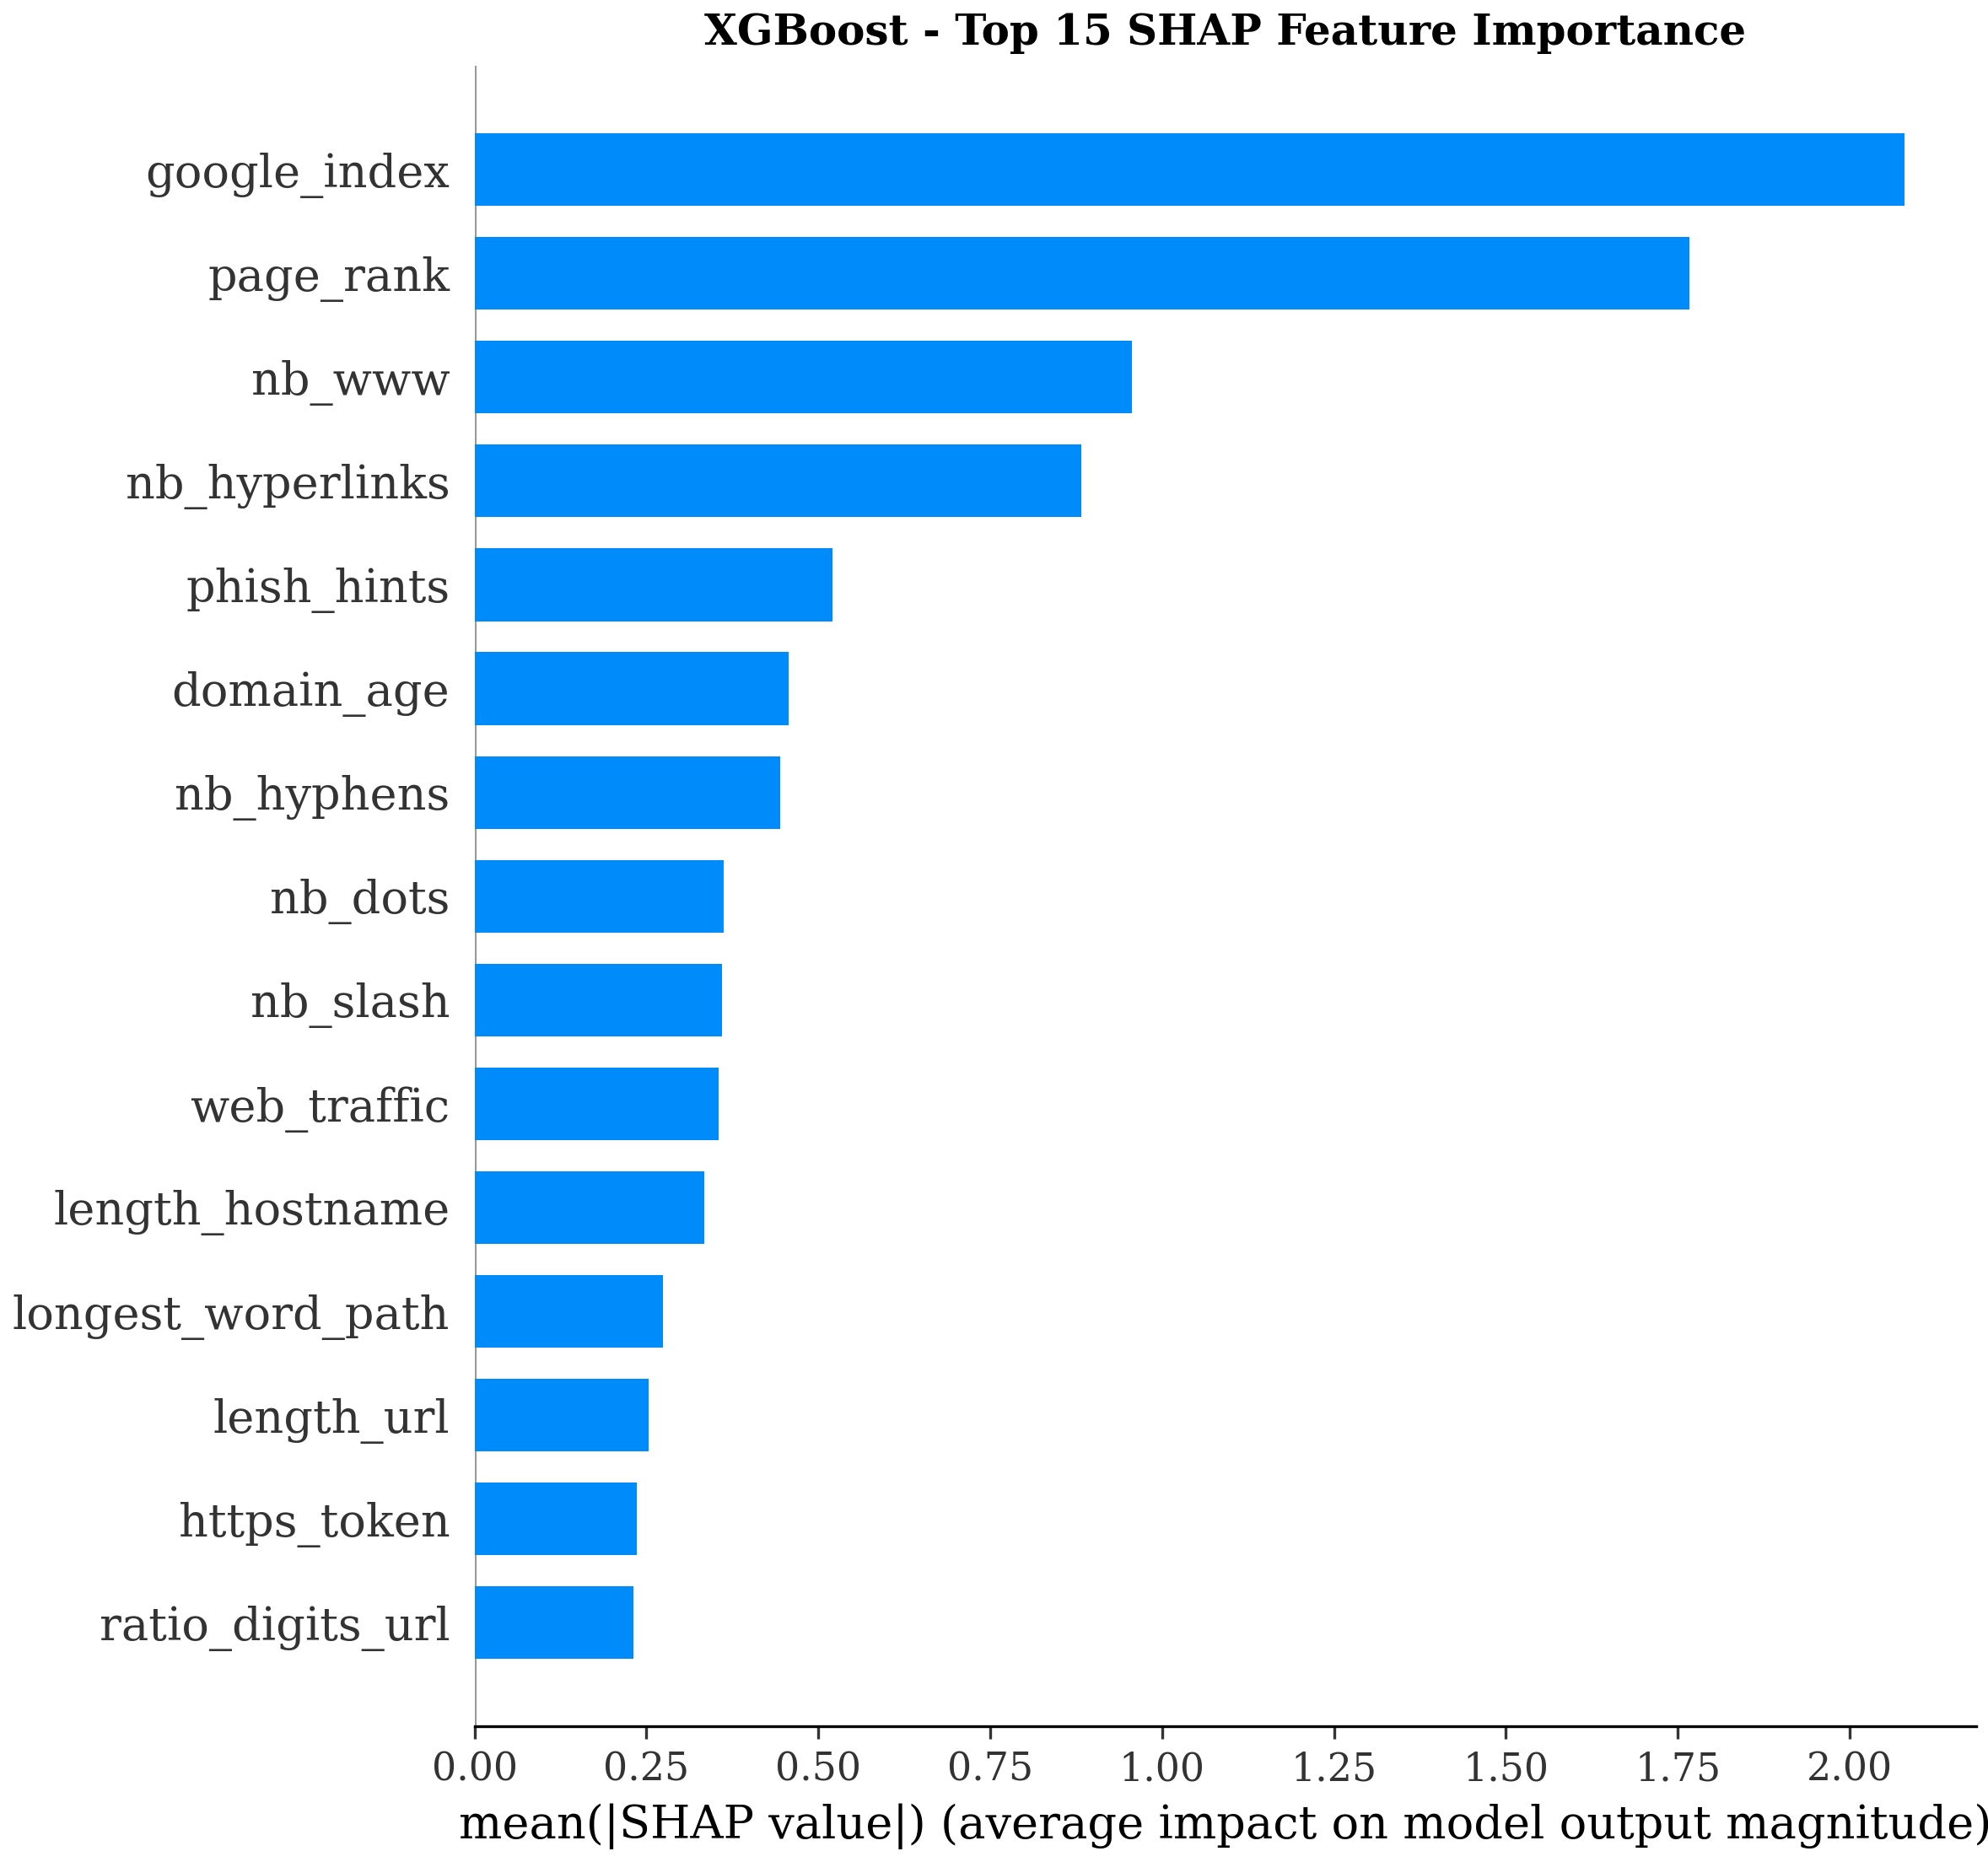

✓ Bar plot saved
✓ Beeswarm plot saved
✓ SHAP analysis completed for XGBoost

SHAP Analysis for CatBoost

Top 10 Important Features:
 Rank          Feature  Mean_SHAP_Value
    1        page_rank         1.533263
    2     google_index         1.330772
    3           nb_www         0.974409
    4    nb_hyperlinks         0.737931
    5      phish_hints         0.538217
    6      web_traffic         0.337780
    7       domain_age         0.317275
    8       nb_hyphens         0.299537
    9         nb_slash         0.259573
   10 ratio_digits_url         0.221404


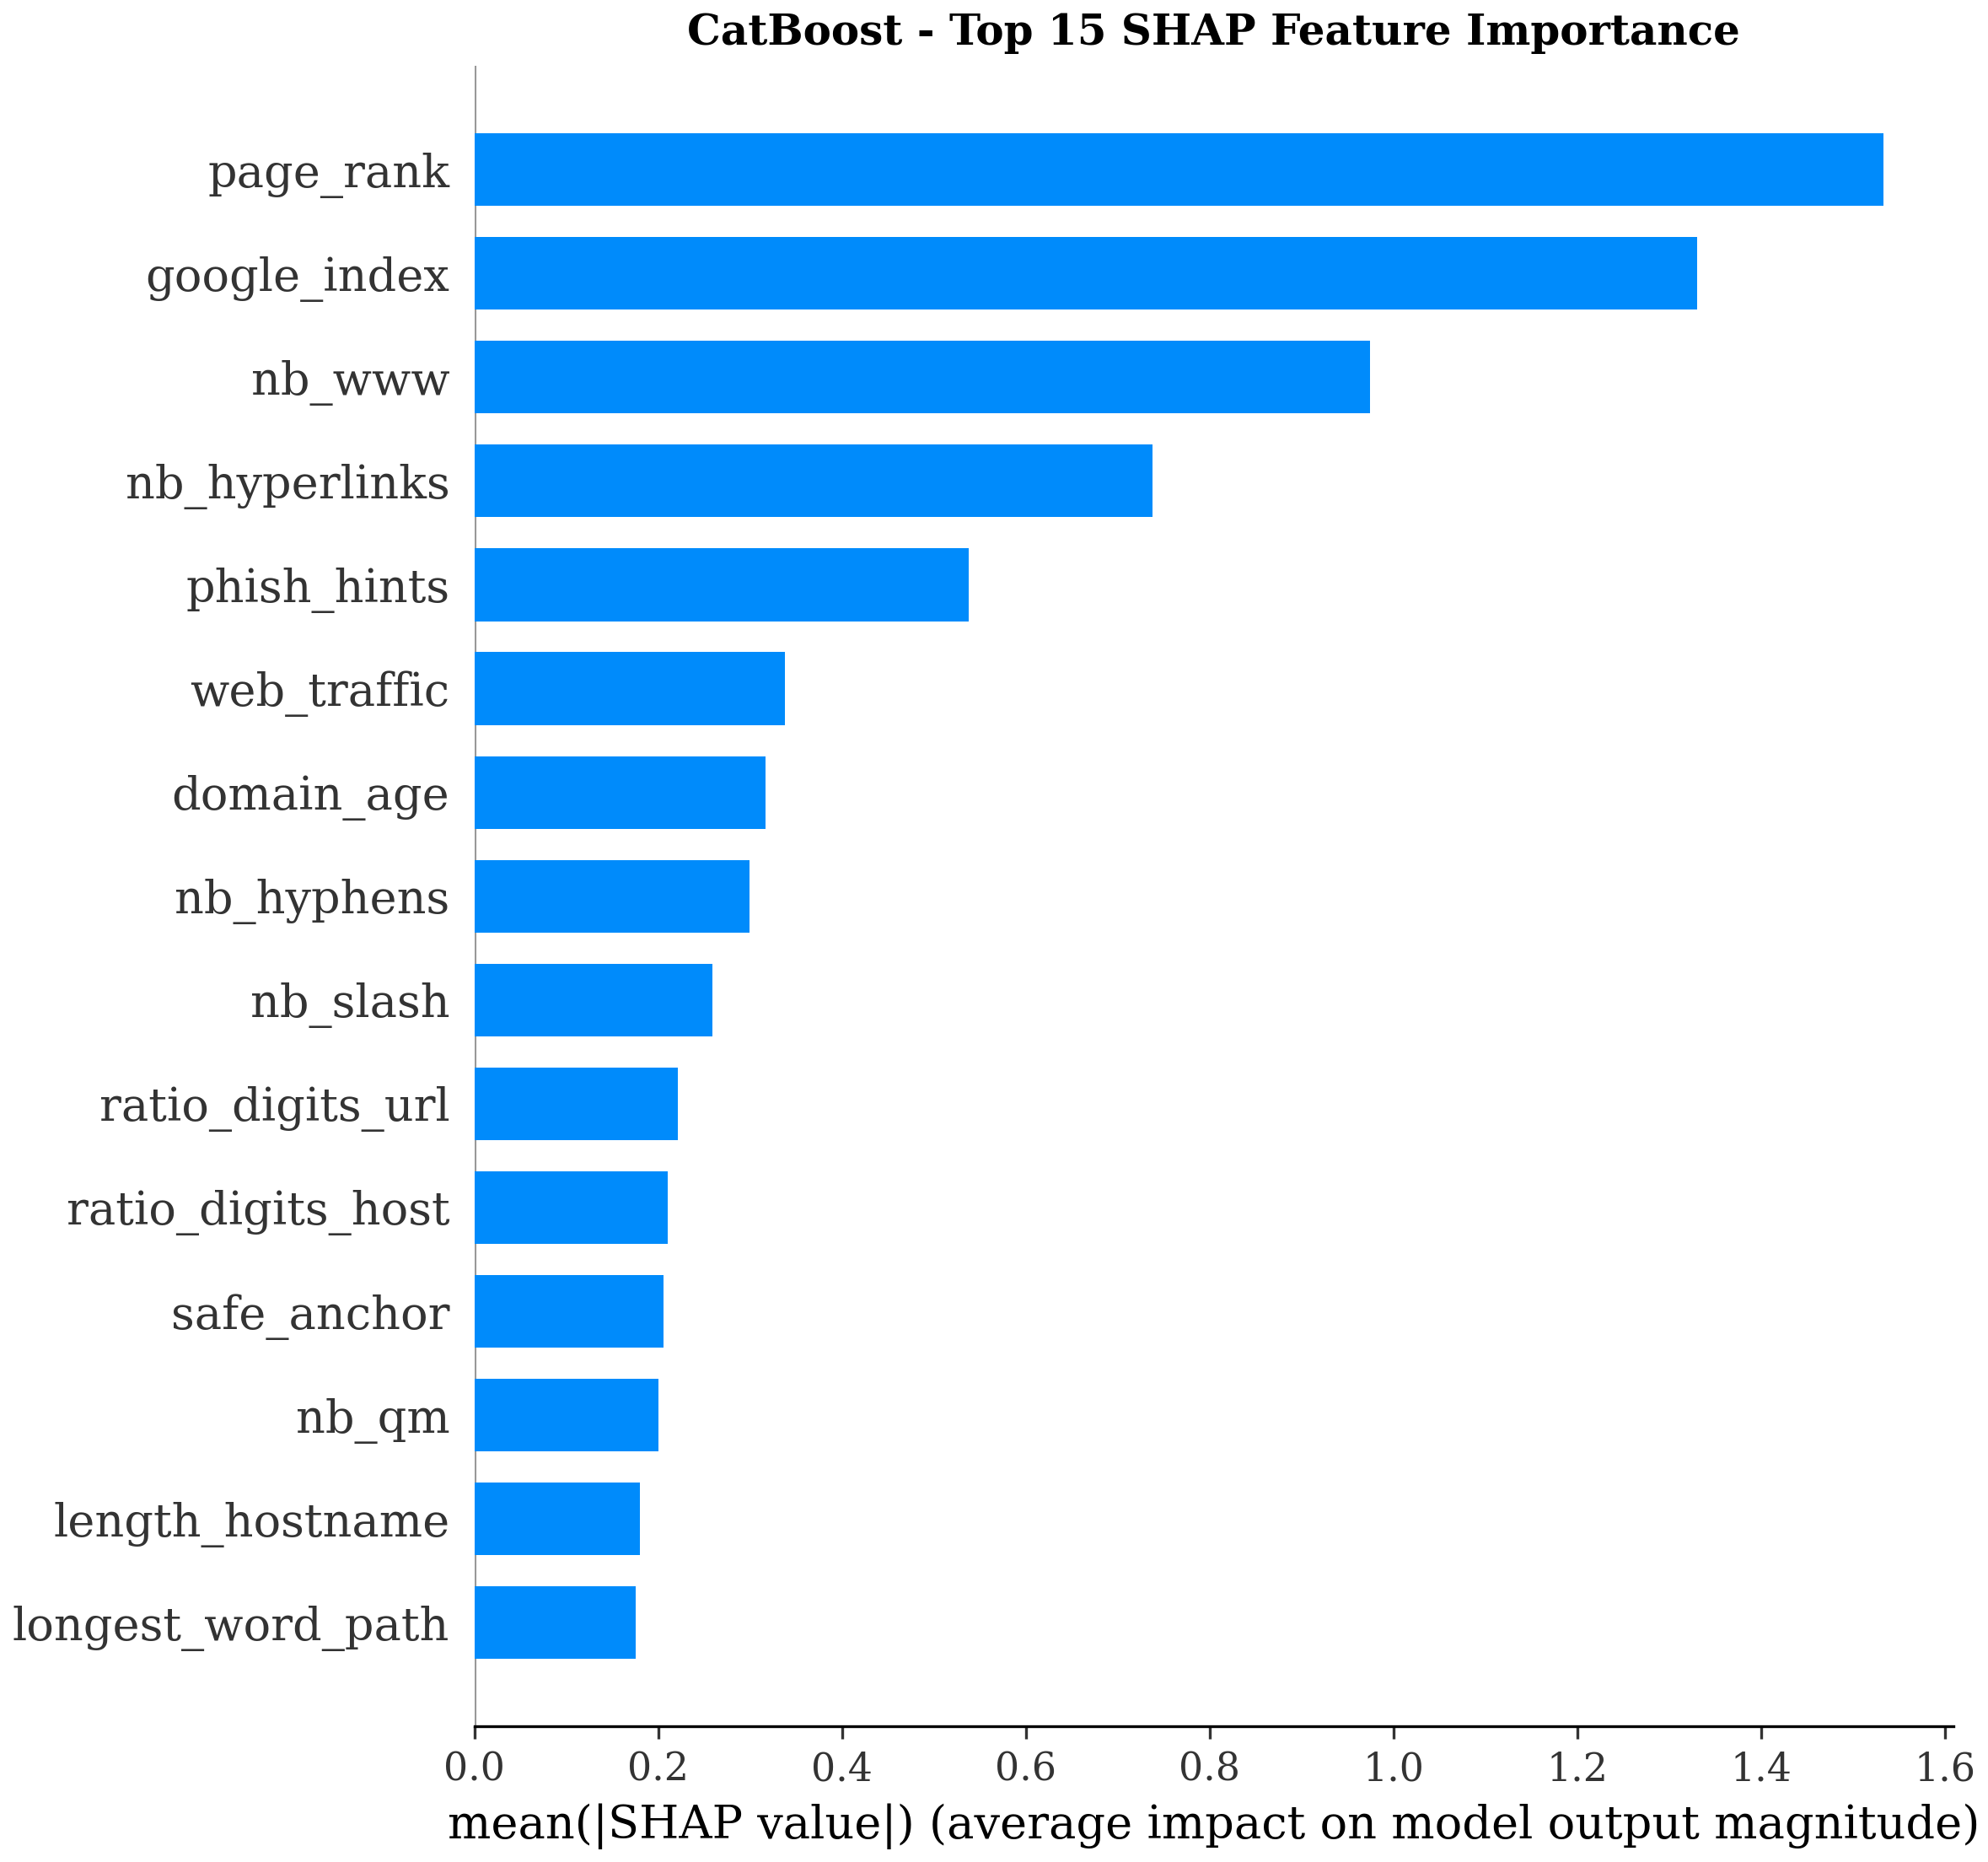

✓ Bar plot saved
✓ Beeswarm plot saved
✓ SHAP analysis completed for CatBoost

SHAP ANALYSIS COMPLETED

Models analyzed: ['Random Forest', 'XGBoost', 'CatBoost']
Output files:
  /kaggle/working/shap_output/random_forest_shap_ranking.csv
  /kaggle/working/shap_output/xgboost_shap_ranking.csv
  /kaggle/working/shap_output/catboost_shap_ranking.csv
  /kaggle/working/figures/*_shap_bar.png
  /kaggle/working/figures/*_shap_beeswarm.png

✓ Step 7 completed!


In [11]:
# STEP 7: SHAP ANALYSIS
import shap
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib
import os

warnings.filterwarnings('ignore')

# Font fix for Kaggle
try:
    plt.rcParams['font.family'] = 'serif'
    plt.rcParams['font.serif'] = ['Times New Roman', 'DejaVu Serif', 'Liberation Serif', 'serif']
except:
    plt.rcParams['font.family'] = 'DejaVu Serif'

print("Loading preprocessed data...")
preprocessed_data = joblib.load('/kaggle/working/feature_engineering_output/preprocessed_data.pkl')

X_train = preprocessed_data['X_train']
X_test = preprocessed_data['X_test']
y_train = preprocessed_data['y_train']
y_test = preprocessed_data['y_test']
feature_names = preprocessed_data['feature_names']

print(f"Training set: {X_train.shape}")
print(f"Test set: {X_test.shape}")

# Load the untuned models (since they performed better)
print("\nLoading models for SHAP analysis...")
model_paths = {
    'Random Forest': '/kaggle/working/baseline_output/random_forest_model.pkl',
    'XGBoost': '/kaggle/working/baseline_output/xgboost_model.pkl',
    'CatBoost': '/kaggle/working/baseline_output/catboost_model.pkl'
}

selected_models = {}
for name, path in model_paths.items():
    if os.path.exists(path):
        selected_models[name] = joblib.load(path)
        print(f"✓ Loaded {name}")
    else:
        print(f"⚠ {name} not found at {path}")

# Sample test data for faster SHAP computation
sample_size = min(500, len(X_test))
X_test_sample = X_test.sample(n=sample_size, random_state=42) if sample_size < len(X_test) else X_test
print(f"\nUsing {len(X_test_sample)} samples for SHAP analysis")

# Store SHAP rankings
shap_results = {}

# ==================================================
# SHAP ANALYSIS LOOP
# ==================================================
for name, model in selected_models.items():

    print(f"\n{'='*50}")
    print(f"SHAP Analysis for {name}")
    print(f"{'='*50}")

    try:
        # Create TreeExplainer for tree-based models
        explainer = shap.TreeExplainer(model)
        shap_values = explainer.shap_values(X_test_sample)

        # Handle different output formats
        if isinstance(shap_values, list):
            shap_values = shap_values[1]  # Take positive class for binary classification
        
        if len(shap_values.shape) == 3:
            shap_values = shap_values[:, :, 1]

        # Calculate mean absolute SHAP values
        mean_shap = np.abs(shap_values).mean(axis=0)

        # Create ranking DataFrame
        shap_ranking = pd.DataFrame({
            'Feature': feature_names,
            'Mean_SHAP_Value': mean_shap
        })
        shap_ranking = shap_ranking.sort_values('Mean_SHAP_Value', ascending=False).reset_index(drop=True)
        shap_ranking['Rank'] = range(1, len(shap_ranking) + 1)
        shap_ranking = shap_ranking[['Rank', 'Feature', 'Mean_SHAP_Value']]

        # Save ranking CSV
        ranking_path = f'/kaggle/working/shap_output/{name.lower().replace(" ", "_")}_shap_ranking.csv'
        shap_ranking.to_csv(ranking_path, index=False)
        shap_results[name] = shap_ranking

        # Print top features
        print(f"\nTop 10 Important Features:")
        print(shap_ranking.head(10)[['Rank', 'Feature', 'Mean_SHAP_Value']].to_string(index=False))

        # ==================================================
        # SHAP BAR PLOT
        # ==================================================
        plt.figure(figsize=(10, 6))
        shap.summary_plot(
            shap_values,
            X_test_sample,
            feature_names=feature_names,
            plot_type="bar",
            show=False,
            max_display=15
        )
        plt.title(f'{name} - Top 15 SHAP Feature Importance', fontsize=12, fontweight='bold')
        plt.tight_layout()
        bar_path = f'/kaggle/working/figures/{name.lower().replace(" ", "_")}_shap_bar.png'
        plt.savefig(bar_path, dpi=300, bbox_inches='tight')
        plt.show()
        print(f"✓ Bar plot saved")

        # ==================================================
        # SHAP BEESWARM PLOT (only if sample is manageable)
        # ==================================================
        if len(X_test_sample) <= 500:
            plt.figure(figsize=(10, 6))
            shap.summary_plot(
                shap_values,
                X_test_sample,
                feature_names=feature_names,
                show=False,
                max_display=15
            )
            plt.title(f'{name} - SHAP Beeswarm Plot', fontsize=12, fontweight='bold')
            plt.tight_layout()
            beeswarm_path = f'/kaggle/working/figures/{name.lower().replace(" ", "_")}_shap_beeswarm.png'
            plt.savefig(beeswarm_path, dpi=300, bbox_inches='tight')
            plt.close()
            print(f"✓ Beeswarm plot saved")
        else:
            print(f"○ Skipping beeswarm plot (sample too large)")

        print(f"✓ SHAP analysis completed for {name}")

    except Exception as e:
        print(f"⚠ Error in SHAP for {name}: {str(e)}")
        
        # Fallback: simpler approach
        try:
            print(f"  Trying alternative approach...")
            background = shap.sample(X_train, 100, random_state=42)
            explainer = shap.KernelExplainer(model.predict_proba, background)
            shap_values = explainer.shap_values(X_test_sample[:100], nsamples=100)
            
            if isinstance(shap_values, list):
                shap_values = shap_values[1]
            if len(shap_values.shape) == 3:
                shap_values = shap_values[:, :, 1]
            
            mean_shap = np.abs(shap_values).mean(axis=0)
            shap_ranking = pd.DataFrame({
                'Feature': feature_names,
                'Mean_SHAP_Value': mean_shap
            })
            shap_ranking = shap_ranking.sort_values('Mean_SHAP_Value', ascending=False).reset_index(drop=True)
            shap_ranking['Rank'] = range(1, len(shap_ranking) + 1)
            
            ranking_path = f'/kaggle/working/shap_output/{name.lower().replace(" ", "_")}_shap_ranking.csv'
            shap_ranking.to_csv(ranking_path, index=False)
            shap_results[name] = shap_ranking
            
            print(f"  ✓ Alternative SHAP completed for {name}")
            print(f"  Top 5: {shap_ranking['Feature'].head(5).tolist()}")
            
        except Exception as e2:
            print(f"  ✗ Alternative also failed: {str(e2)}")

# ==================================================
# FINAL SUMMARY
# ==================================================
print("\n" + "="*60)
print("SHAP ANALYSIS COMPLETED")
print("="*60)
print(f"\nModels analyzed: {list(shap_results.keys())}")
print("Output files:")
print("  /kaggle/working/shap_output/random_forest_shap_ranking.csv")
print("  /kaggle/working/shap_output/xgboost_shap_ranking.csv")
print("  /kaggle/working/shap_output/catboost_shap_ranking.csv")
print("  /kaggle/working/figures/*_shap_bar.png")
print("  /kaggle/working/figures/*_shap_beeswarm.png")
print("\n✓ Step 7 completed!")

Loading SHAP rankings...

Random Forest - Top 5: google_index, page_rank, web_traffic, nb_hyperlinks, nb_www

XGBoost - Top 5: google_index, page_rank, nb_www, nb_hyperlinks, phish_hints

CatBoost - Top 5: page_rank, google_index, nb_www, nb_hyperlinks, phish_hints

FEATURE SELECTION STRATEGIES

1. In ALL 3 models: 14 features
   ['google_index', 'page_rank', 'web_traffic', 'nb_hyperlinks', 'nb_www', 'phish_hints', 'domain_age', 'ratio_extHyperlinks', 'safe_anchor', 'longest_word_path', 'ratio_digits_url', 'length_hostname', 'ratio_digits_host', 'nb_hyphens']
2. In ≥2 models: 20 features
3. Union (all top 20): 26 features

✓ Selected: Consensus (features in ≥2 models): 20 features

Final Selected Features (20):
   1. google_index (in 3 models)
   2. page_rank (in 3 models)
   3. web_traffic (in 3 models)
   4. nb_hyperlinks (in 3 models)
   5. nb_www (in 3 models)
   6. phish_hints (in 3 models)
   7. domain_age (in 3 models)
   8. ratio_extHyperlinks (in 3 models)
   9. safe_anchor (i

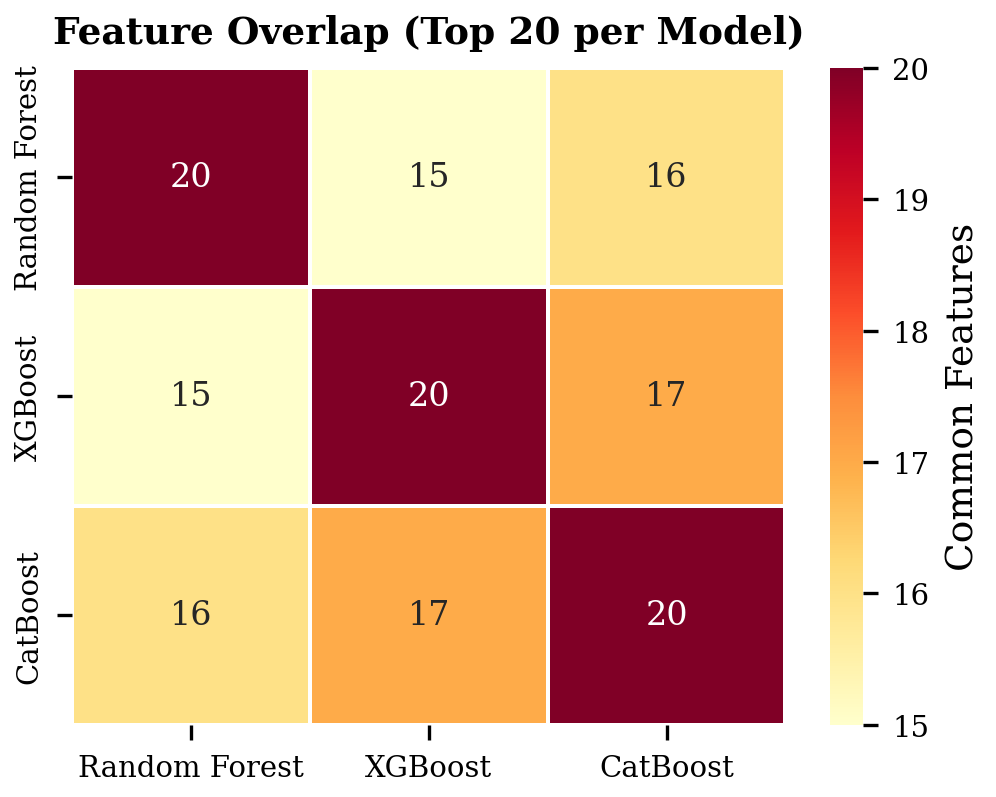

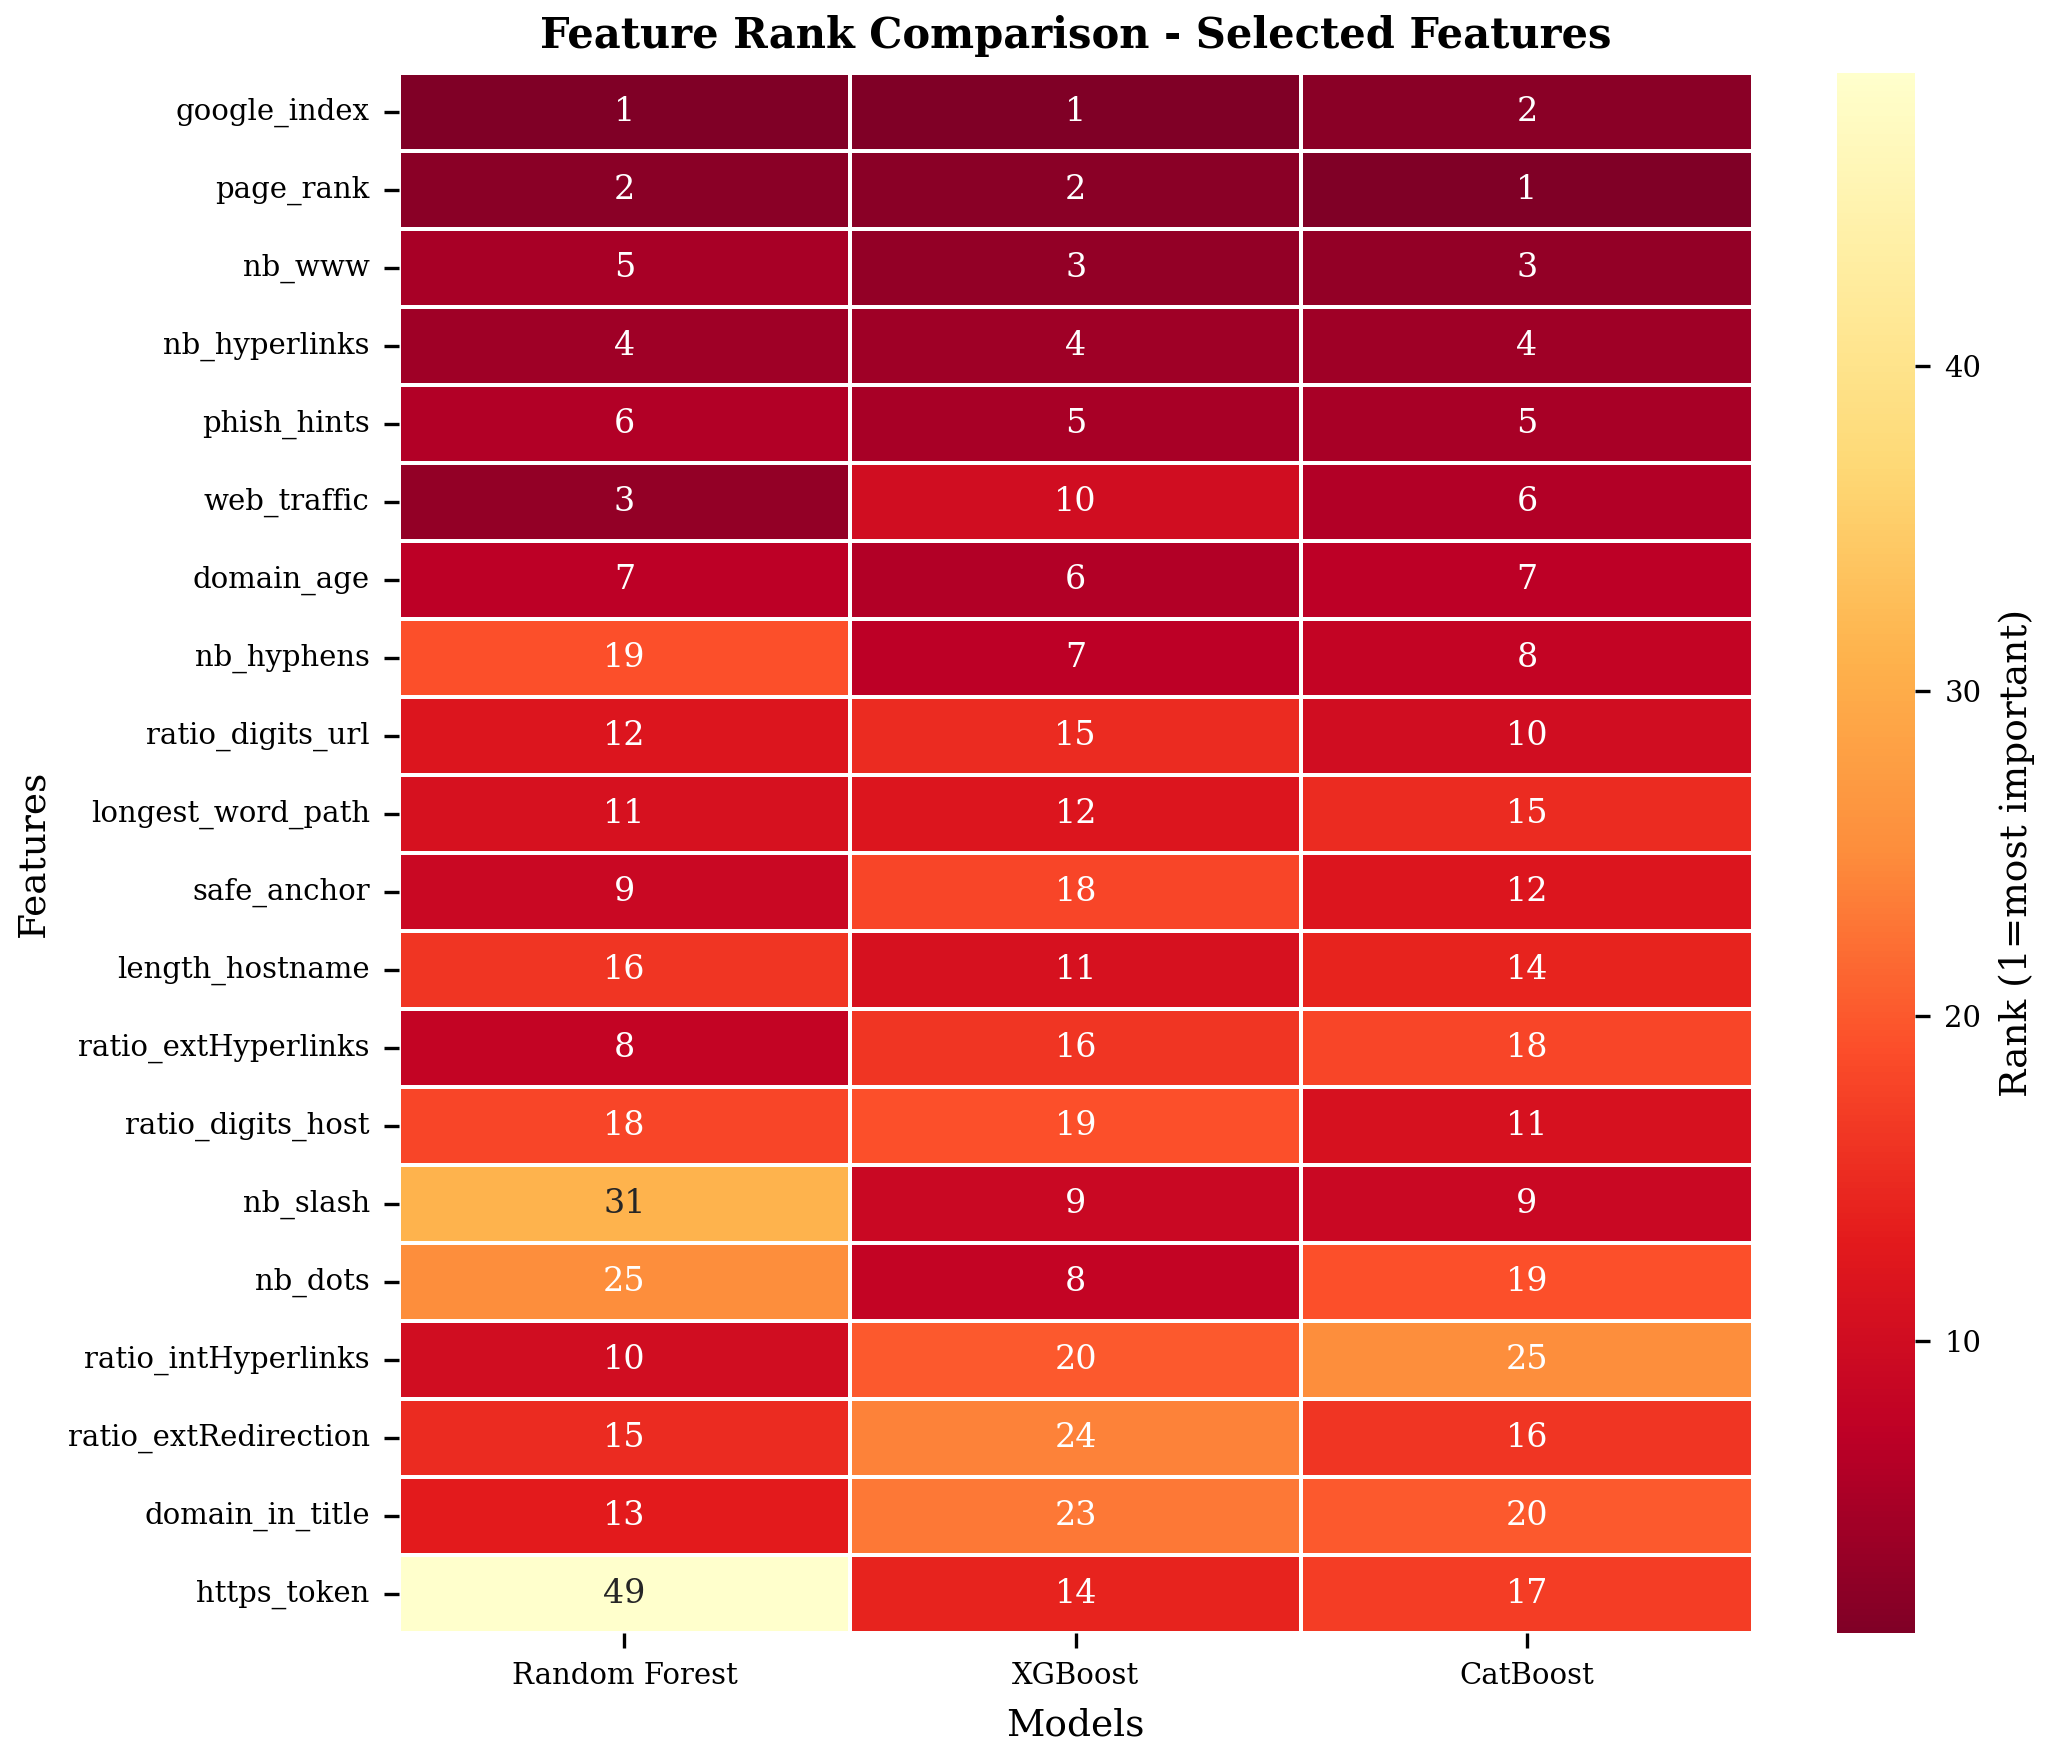


FEATURE OVERLAP SUMMARY
Random Forest ∩ XGBoost: 15 features
Random Forest ∩ CatBoost: 16 features
XGBoost ∩ CatBoost: 17 features

All 3 models agree on: 14 features
Features: ['google_index', 'page_rank', 'web_traffic', 'nb_hyperlinks', 'nb_www', 'phish_hints', 'domain_age', 'ratio_extHyperlinks', 'safe_anchor', 'longest_word_path', 'ratio_digits_url', 'length_hostname', 'ratio_digits_host', 'nb_hyphens']

✓ Step 8 completed!


In [12]:
# STEP 8: TOP SHAP FEATURE SELECTION
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter

# Font fix
try:
    plt.rcParams['font.family'] = 'serif'
    plt.rcParams['font.serif'] = ['Times New Roman', 'DejaVu Serif', 'Liberation Serif', 'serif']
except:
    plt.rcParams['font.family'] = 'DejaVu Serif'

FULL_WIDTH = 7.16
COLUMN_WIDTH = 3.5

print("Loading SHAP rankings...")
shap_files = {
    'Random Forest': '/kaggle/working/shap_output/random_forest_shap_ranking.csv',
    'XGBoost': '/kaggle/working/shap_output/xgboost_shap_ranking.csv',
    'CatBoost': '/kaggle/working/shap_output/catboost_shap_ranking.csv'
}

top_features_per_model = {}
top_n = 20

for name, filepath in shap_files.items():
    if os.path.exists(filepath):
        ranking_df = pd.read_csv(filepath)
        top_features = ranking_df.head(top_n)['Feature'].tolist()
        top_features_per_model[name] = top_features
        print(f"\n{name} - Top 5: {', '.join(top_features[:5])}")
    else:
        print(f"⚠ Missing: {filepath}")

# ==================================================
# FEATURE SELECTION STRATEGIES
# ==================================================
print("\n" + "="*60)
print("FEATURE SELECTION STRATEGIES")
print("="*60)

# Count feature appearances across models
all_top_features = []
for features in top_features_per_model.values():
    all_top_features.extend(features)

feature_counts = Counter(all_top_features)

# Strategy 1: Features in all 3 models (strongest consensus)
common_all = [feat for feat, count in feature_counts.items() if count == 3]
print(f"\n1. In ALL 3 models: {len(common_all)} features")
print(f"   {common_all}")

# Strategy 2: Features in at least 2 models
consensus = [feat for feat, count in feature_counts.items() if count >= 2]
print(f"2. In ≥2 models: {len(consensus)} features")

# Strategy 3: Union of all top 20
union = list(dict.fromkeys(all_top_features))
print(f"3. Union (all top 20): {len(union)} features")

# Choose consensus features (≥2 models) as final selection
if len(consensus) >= 15:
    final_selected = consensus
    method = f"Consensus (features in ≥2 models): {len(final_selected)} features"
else:
    final_selected = union[:20]
    method = f"Union of top features (capped at 20): {len(final_selected)} features"

print(f"\n✓ Selected: {method}")

# Print final selected features
print(f"\nFinal Selected Features ({len(final_selected)}):")
for i, feat in enumerate(final_selected, 1):
    models_with = [m for m, feats in top_features_per_model.items() if feat in feats]
    print(f"  {i:2d}. {feat} (in {len(models_with)} models)")

# Save
selected_df = pd.DataFrame({
    'Feature': final_selected,
    'Rank': range(1, len(final_selected) + 1),
    'Num_Models': [feature_counts.get(f, 0) for f in final_selected]
})
selected_df.to_csv('/kaggle/working/shap_output/top_selected_features.csv', index=False)
print(f"\n✓ Saved to /kaggle/working/shap_output/top_selected_features.csv")

# ==================================================
# OVERLAP VISUALIZATION
# ==================================================
print("\nGenerating overlap visualizations...")

# Overlap heatmap
overlap_matrix = np.zeros((3, 3))
model_names = list(top_features_per_model.keys())
for i, m1 in enumerate(model_names):
    for j, m2 in enumerate(model_names):
        overlap_matrix[i, j] = len(set(top_features_per_model[m1]) & set(top_features_per_model[m2]))

fig, ax = plt.subplots(figsize=(COLUMN_WIDTH, 2.8))
sns.heatmap(overlap_matrix, annot=True, fmt='.0f', 
            xticklabels=model_names, yticklabels=model_names,
            cmap='YlOrRd', cbar_kws={'label': 'Common Features'},
            linewidths=0.5, ax=ax)
ax.set_title('Feature Overlap (Top 20 per Model)', fontsize=9, fontweight='bold')
plt.tight_layout()
plt.savefig('/kaggle/working/figures/feature_overlap_heatmap.pdf', format='pdf')
plt.savefig('/kaggle/working/figures/feature_overlap_heatmap.png', format='png')
plt.show()

# Rank comparison heatmap
rank_data = {}
for name, filepath in shap_files.items():
    if os.path.exists(filepath):
        df = pd.read_csv(filepath)
        rank_data[name] = dict(zip(df['Feature'], range(1, len(df)+1)))

rank_df = pd.DataFrame(rank_data)
rank_df_filtered = rank_df.loc[rank_df.index.isin(final_selected)]
rank_df_filtered['avg_rank'] = rank_df_filtered.mean(axis=1)
rank_df_filtered = rank_df_filtered.sort_values('avg_rank')
plot_df = rank_df_filtered.drop('avg_rank', axis=1)

fig, ax = plt.subplots(figsize=(FULL_WIDTH, max(4, len(plot_df) * 0.3)))
sns.heatmap(plot_df, annot=True, fmt='.0f', cmap='YlOrRd_r',
            cbar_kws={'label': 'Rank (1=most important)'},
            linewidths=0.5, ax=ax)
ax.set_title('Feature Rank Comparison - Selected Features', fontsize=10, fontweight='bold')
ax.set_ylabel('Features')
ax.set_xlabel('Models')
plt.tight_layout()
plt.savefig('/kaggle/working/figures/rank_comparison_heatmap.pdf', format='pdf')
plt.savefig('/kaggle/working/figures/rank_comparison_heatmap.png', format='png')
plt.show()

# Overlap counts
print("\n" + "="*60)
print("FEATURE OVERLAP SUMMARY")
print("="*60)
for i in range(len(model_names)):
    for j in range(i+1, len(model_names)):
        m1, m2 = model_names[i], model_names[j]
        overlap = set(top_features_per_model[m1]) & set(top_features_per_model[m2])
        print(f"{m1} ∩ {m2}: {len(overlap)} features")

print(f"\nAll 3 models agree on: {len(common_all)} features")
print(f"Features: {common_all}")

print("\n✓ Step 8 completed!")

Loading data...
Top features: 20
Full features: 81 → Top features: 20
Reduction: 61 features removed (75.3%)

TRAINING MODELS ON TOP 20 FEATURES

Training Logistic Regression...
  F1: 0.9228 (baseline: 0.9359, change: -0.0131)
  AUC: 0.9770 (baseline: 0.9814, change: -0.0044)

Training Decision Tree...
  F1: 0.9367 (baseline: 0.9357, change: +0.0010)
  AUC: 0.9370 (baseline: 0.9357, change: +0.0013)

Training Random Forest...
  F1: 0.9586 (baseline: 0.9655, change: -0.0069)
  AUC: 0.9916 (baseline: 0.9938, change: -0.0023)

Training XGBoost...
  F1: 0.9647 (baseline: 0.9665, change: -0.0018)
  AUC: 0.9930 (baseline: 0.9936, change: -0.0006)

Training CatBoost...
  F1: 0.9625 (baseline: 0.9625, change: +0.0000)
  AUC: 0.9927 (baseline: 0.9936, change: -0.0009)

✓ Results saved

FULL FEATURES vs TOP 20 FEATURES
              Model  F1_Full  F1_Top20   F1_Diff  AUC_Full  AUC_Top20  AUC_Diff
Logistic Regression 0.935909  0.922810 -0.013099  0.981422   0.976995 -0.004427
      Decision Tree

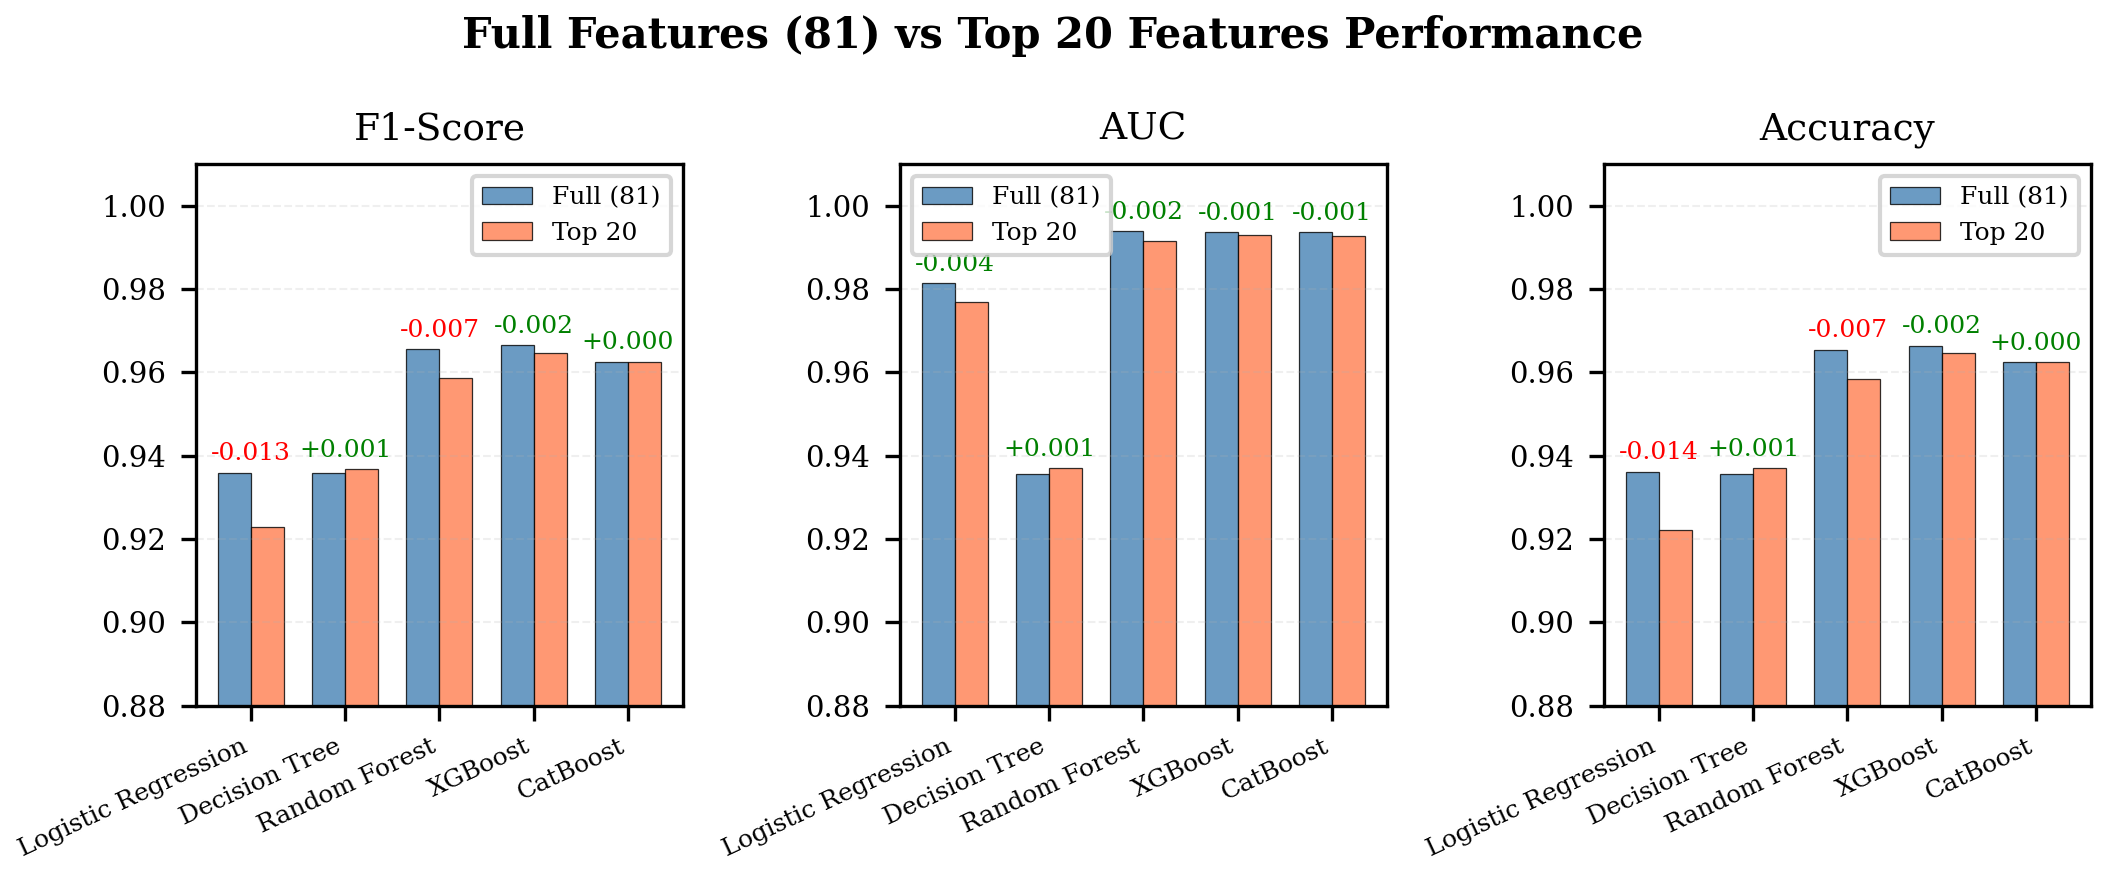


KEY FINDING
Best Full Features F1: 0.9665
Best Top-20 Features F1: 0.9647
Performance Retention: 99.8%
Feature Reduction: 75.3%

✓ EXCELLENT: Top 20 features retain 99.8% of performance!
  Only 20/81 features needed for phishing detection

✓ Step 9 completed!


In [13]:
# STEP 9: RETRAIN MODELS USING TOP 20 FEATURES
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from catboost import CatBoostClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
import joblib
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

# Font fix
try:
    plt.rcParams['font.family'] = 'serif'
    plt.rcParams['font.serif'] = ['Times New Roman', 'DejaVu Serif', 'Liberation Serif', 'serif']
except:
    plt.rcParams['font.family'] = 'DejaVu Serif'

FULL_WIDTH = 7.16

print("Loading data...")
preprocessed_data = joblib.load('/kaggle/working/feature_engineering_output/preprocessed_data.pkl')
X_train = preprocessed_data['X_train']
X_test = preprocessed_data['X_test']
y_train = preprocessed_data['y_train']
y_test = preprocessed_data['y_test']
feature_names = preprocessed_data['feature_names']

# Load top 20 features
top_features_df = pd.read_csv('/kaggle/working/shap_output/top_selected_features.csv')
top_features = top_features_df['Feature'].tolist()
top_features = [f for f in top_features if f in X_train.columns]
print(f"Top features: {len(top_features)}")

# Create reduced datasets
X_train_top = X_train[top_features]
X_test_top = X_test[top_features]

# Scale for LR
scaler = StandardScaler()
X_train_top_scaled = pd.DataFrame(scaler.fit_transform(X_train_top), columns=top_features)
X_test_top_scaled = pd.DataFrame(scaler.transform(X_test_top), columns=top_features)

print(f"Full features: {X_train.shape[1]} → Top features: {X_train_top.shape[1]}")
print(f"Reduction: {X_train.shape[1] - X_train_top.shape[1]} features removed ({(1 - X_train_top.shape[1]/X_train.shape[1])*100:.1f}%)")

# Load baseline results for comparison
baseline_results = pd.read_csv('/kaggle/working/baseline_output/baseline_results.csv')

# Train all models on top features
print("\n" + "="*60)
print("TRAINING MODELS ON TOP 20 FEATURES")
print("="*60)

models = {
    'Logistic Regression': LogisticRegression(random_state=42, max_iter=1000),
    'Decision Tree': DecisionTreeClassifier(random_state=42),
    'Random Forest': RandomForestClassifier(random_state=42, n_jobs=-1),
    'XGBoost': XGBClassifier(random_state=42, eval_metric='logloss'),
    'CatBoost': CatBoostClassifier(random_state=42, verbose=0)
}

top_results = []

for name, model in models.items():
    print(f"\nTraining {name}...")
    
    if name == 'Logistic Regression':
        model.fit(X_train_top_scaled, y_train)
        y_pred = model.predict(X_test_top_scaled)
        y_proba = model.predict_proba(X_test_top_scaled)[:, 1]
    else:
        model.fit(X_train_top, y_train)
        y_pred = model.predict(X_test_top)
        y_proba = model.predict_proba(X_test_top)[:, 1]
    
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    auc = roc_auc_score(y_test, y_proba)
    
    # Get baseline
    baseline = baseline_results[baseline_results['Model'] == name]
    base_f1 = baseline['F1_Score'].values[0] if not baseline.empty else 0
    base_auc = baseline['AUC'].values[0] if not baseline.empty else 0
    base_acc = baseline['Accuracy'].values[0] if not baseline.empty else 0
    
    f1_change = f1 - base_f1
    auc_change = auc - base_auc
    acc_change = acc - base_acc
    
    top_results.append({
        'Model': name,
        'Accuracy': acc,
        'F1_Score': f1,
        'AUC': auc,
        'Precision': prec,
        'Recall': rec,
        'Baseline_F1': base_f1,
        'Baseline_AUC': base_auc,
        'F1_Change': f1_change,
        'AUC_Change': auc_change
    })
    
    print(f"  F1: {f1:.4f} (baseline: {base_f1:.4f}, change: {f1_change:+.4f})")
    print(f"  AUC: {auc:.4f} (baseline: {base_auc:.4f}, change: {auc_change:+.4f})")

# Save results
top_results_df = pd.DataFrame(top_results)
top_results_df.to_csv('/kaggle/working/shap_output/top_model_results.csv', index=False)
print(f"\n✓ Results saved")

# ==================================================
# COMPARISON TABLE
# ==================================================
print("\n" + "="*60)
print("FULL FEATURES vs TOP 20 FEATURES")
print("="*60)

comparison = baseline_results[['Model', 'F1_Score', 'AUC', 'Accuracy']].copy()
comparison.columns = ['Model', 'F1_Full', 'AUC_Full', 'Acc_Full']
comparison['F1_Top20'] = top_results_df['F1_Score'].values
comparison['AUC_Top20'] = top_results_df['AUC'].values
comparison['Acc_Top20'] = top_results_df['Accuracy'].values
comparison['F1_Diff'] = comparison['F1_Top20'] - comparison['F1_Full']
comparison['AUC_Diff'] = comparison['AUC_Top20'] - comparison['AUC_Full']

print(comparison[['Model', 'F1_Full', 'F1_Top20', 'F1_Diff', 'AUC_Full', 'AUC_Top20', 'AUC_Diff']].to_string(index=False))

# ==================================================
# VISUALIZATION
# ==================================================
print("\nGenerating comparison figure...")

fig, axes = plt.subplots(1, 3, figsize=(FULL_WIDTH, 3.0))
metrics = [('F1_Score', 'F1-Score'), ('AUC', 'AUC'), ('Accuracy', 'Accuracy')]

for idx, (metric, title) in enumerate(metrics):
    ax = axes[idx]
    model_names = baseline_results['Model'].tolist()
    full_vals = baseline_results[metric].tolist()
    top_vals = top_results_df[metric].tolist()
    
    x = np.arange(len(model_names))
    width = 0.35
    
    ax.bar(x - width/2, full_vals, width, label='Full (81)', color='steelblue', alpha=0.8, edgecolor='black', linewidth=0.3)
    ax.bar(x + width/2, top_vals, width, label='Top 20', color='coral', alpha=0.8, edgecolor='black', linewidth=0.3)
    
    # Add change labels
    for i in range(len(model_names)):
        diff = top_vals[i] - full_vals[i]
        color = 'green' if diff >= -0.005 else 'red'
        ax.annotate(f'{diff:+.3f}', xy=(x[i], max(full_vals[i], top_vals[i])),
                   fontsize=6, ha='center', color=color, xytext=(0, 3), textcoords='offset points')
    
    ax.set_xticks(x)
    ax.set_xticklabels(model_names, rotation=25, ha='right', fontsize=6)
    ax.set_title(title, fontsize=9)
    ax.legend(fontsize=6)
    ax.grid(axis='y', alpha=0.2, linestyle='--')
    ax.set_ylim(0.88, 1.01)

plt.suptitle(f'Full Features (81) vs Top 20 Features Performance', fontsize=10, fontweight='bold')
plt.tight_layout()
plt.savefig('/kaggle/working/figures/full_vs_top20_features.pdf', format='pdf')
plt.savefig('/kaggle/working/figures/full_vs_top20_features.png', format='png')
plt.show()

# ==================================================
# KEY FINDING
# ==================================================
best_full_f1 = baseline_results['F1_Score'].max()
best_top_f1 = top_results_df['F1_Score'].max()
retention = (best_top_f1 / best_full_f1) * 100

print(f"\n{'='*60}")
print(f"KEY FINDING")
print(f"{'='*60}")
print(f"Best Full Features F1: {best_full_f1:.4f}")
print(f"Best Top-20 Features F1: {best_top_f1:.4f}")
print(f"Performance Retention: {retention:.1f}%")
print(f"Feature Reduction: {(1 - 20/81)*100:.1f}%")

if retention >= 99:
    print(f"\n✓ EXCELLENT: Top 20 features retain {retention:.1f}% of performance!")
    print(f"  Only 20/81 features needed for phishing detection")
elif retention >= 97:
    print(f"\n✓ GOOD: Top 20 features retain {retention:.1f}% of performance")
else:
    print(f"\n⚠ Performance drop >3%, consider using more features")

print("\n✓ Step 9 completed!")

Loading data...
Using 20 top features

STACKING ENSEMBLE - TOP 20 FEATURES
Training stacking ensemble...

Stacking Ensemble Results (Top 20 Features):
  Accuracy:  0.9641
  Precision: 0.9593
  Recall:    0.9694
  F1-Score:  0.9643
  AUC:       0.9932

STACKING ENSEMBLE - ALL 81 FEATURES
Full Features F1: 0.9661, AUC: 0.9946
Top-20 Features F1: 0.9643, AUC: 0.9932

FINAL COMPARISON: ALL MODELS
                          Model  Features  F1_Score      AUC  Accuracy
          XGBoost (81 features)        81  0.966507 0.993604  0.966317
          XGBoost (20 features)        20  0.964706 0.992960  0.964567
Stacking Ensemble (81 features)        81  0.966057 0.994575  0.965879
Stacking Ensemble (20 features)        20  0.964317 0.993161  0.964129

✓ Ensemble models saved
✓ Table 2 saved

Generating ensemble comparison figure...


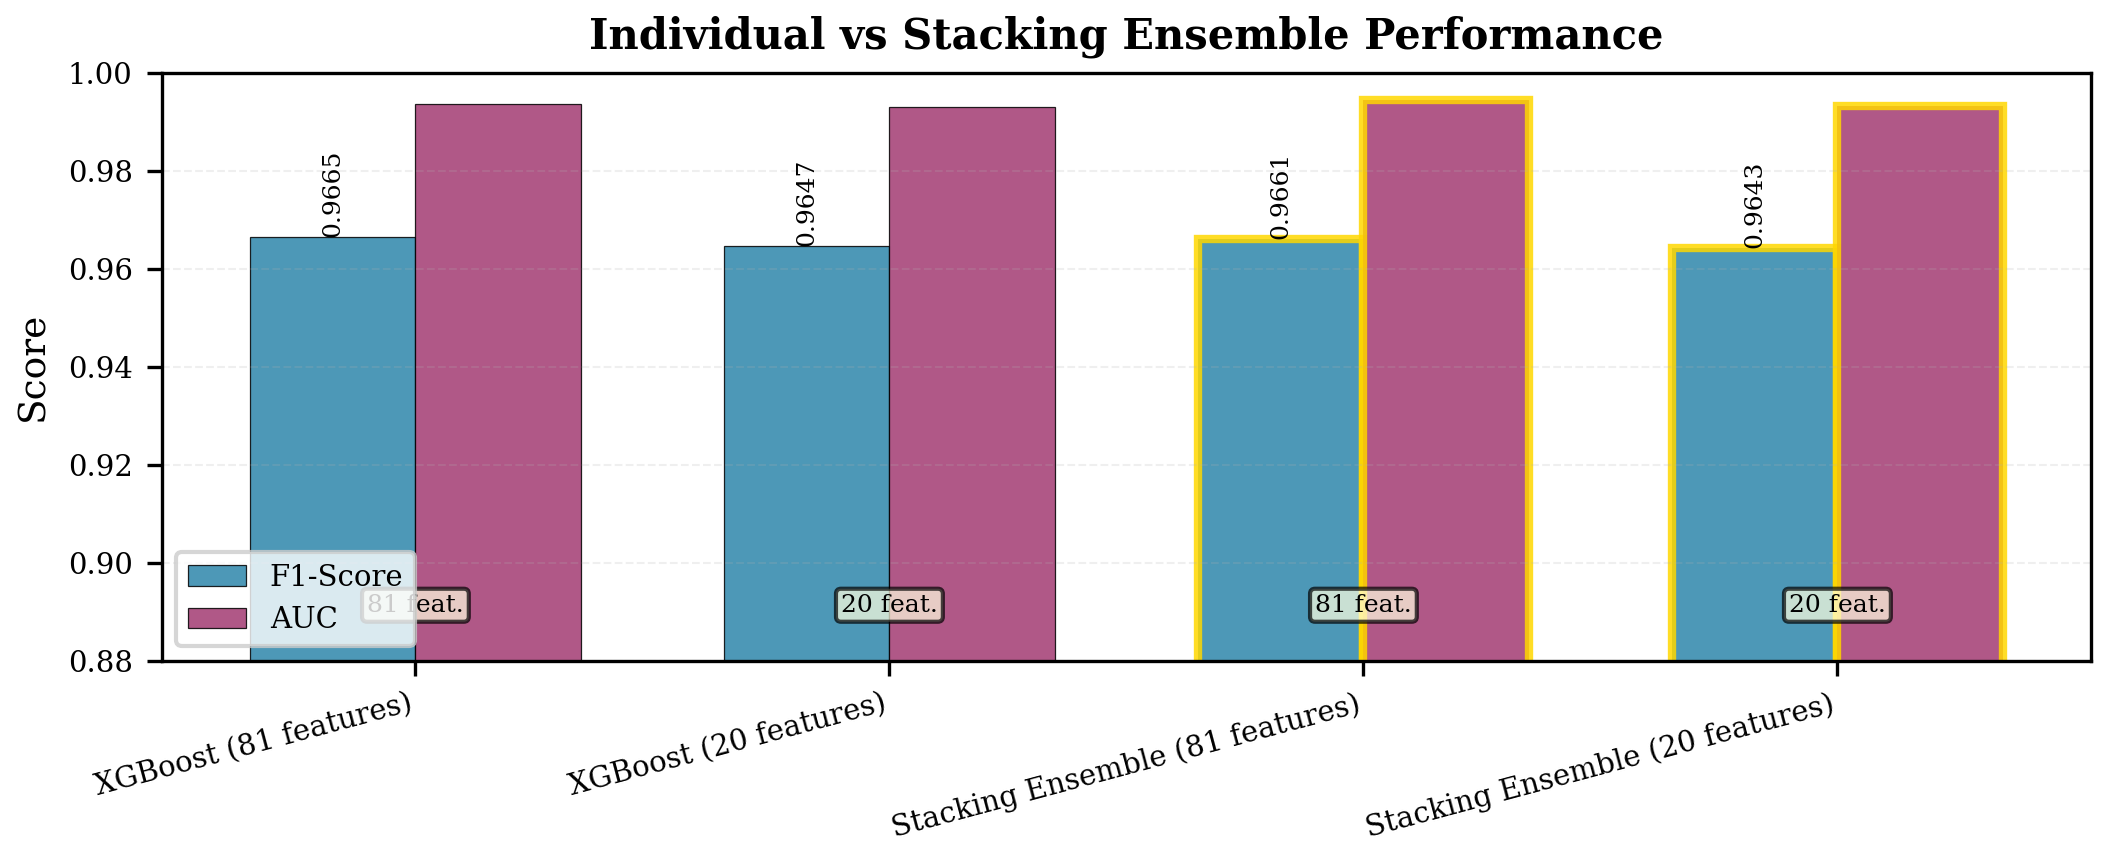


ENSEMBLE CONCLUSION
Best Individual (81 features): F1 = 0.9665
Best Individual (20 features):  F1 = 0.9647
Stacking Ensemble (20 features): F1 = 0.9643

○ Best individual model matches or beats stacking

✓ Step 10 completed!


In [14]:
# STEP 10: STACKING ENSEMBLE (USING TOP 20 FEATURES)
from sklearn.ensemble import StackingClassifier, RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier
from catboost import CatBoostClassifier
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
import joblib
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

# Font fix
try:
    plt.rcParams['font.family'] = 'serif'
    plt.rcParams['font.serif'] = ['Times New Roman', 'DejaVu Serif', 'Liberation Serif', 'serif']
except:
    plt.rcParams['font.family'] = 'DejaVu Serif'

FULL_WIDTH = 7.16

print("Loading data...")
preprocessed_data = joblib.load('/kaggle/working/feature_engineering_output/preprocessed_data.pkl')
X_train = preprocessed_data['X_train']
X_test = preprocessed_data['X_test']
y_train = preprocessed_data['y_train']
y_test = preprocessed_data['y_test']
feature_names = preprocessed_data['feature_names']

# Load top 20 features
top_features_df = pd.read_csv('/kaggle/working/shap_output/top_selected_features.csv')
top_features = top_features_df['Feature'].tolist()
top_features = [f for f in top_features if f in X_train.columns]
print(f"Using {len(top_features)} top features")

# Create reduced datasets
X_train_top = X_train[top_features]
X_test_top = X_test[top_features]

# Load baseline results
baseline_results = pd.read_csv('/kaggle/working/baseline_output/baseline_results.csv')
top_results = pd.read_csv('/kaggle/working/shap_output/top_model_results.csv')

# ==================================================
# BUILD STACKING ENSEMBLE (TOP 20 FEATURES)
# ==================================================
print("\n" + "="*60)
print("STACKING ENSEMBLE - TOP 20 FEATURES")
print("="*60)

# Base estimators (best individual models)
base_estimators = [
    ('rf', RandomForestClassifier(random_state=42, n_jobs=-1)),
    ('xgb', XGBClassifier(random_state=42, eval_metric='logloss')),
    ('catboost', CatBoostClassifier(random_state=42, verbose=0))
]

# Meta-learner
meta_learner = LogisticRegression(max_iter=1000, random_state=42)

# Cross-validation
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Build stacking classifier
stacking = StackingClassifier(
    estimators=base_estimators,
    final_estimator=meta_learner,
    cv=cv,
    n_jobs=-1,
    stack_method='predict_proba'
)

print("Training stacking ensemble...")
stacking.fit(X_train_top, y_train)

# Evaluate
y_pred = stacking.predict(X_test_top)
y_proba = stacking.predict_proba(X_test_top)[:, 1]

ensemble_acc = accuracy_score(y_test, y_pred)
ensemble_prec = precision_score(y_test, y_pred)
ensemble_rec = recall_score(y_test, y_pred)
ensemble_f1 = f1_score(y_test, y_pred)
ensemble_auc = roc_auc_score(y_test, y_proba)

print(f"\nStacking Ensemble Results (Top 20 Features):")
print(f"  Accuracy:  {ensemble_acc:.4f}")
print(f"  Precision: {ensemble_prec:.4f}")
print(f"  Recall:    {ensemble_rec:.4f}")
print(f"  F1-Score:  {ensemble_f1:.4f}")
print(f"  AUC:       {ensemble_auc:.4f}")

# ==================================================
# ALSO BUILD WITH ALL 81 FEATURES FOR COMPARISON
# ==================================================
print("\n" + "="*60)
print("STACKING ENSEMBLE - ALL 81 FEATURES")
print("="*60)

stacking_full = StackingClassifier(
    estimators=[
        ('rf', RandomForestClassifier(random_state=42, n_jobs=-1)),
        ('xgb', XGBClassifier(random_state=42, eval_metric='logloss')),
        ('catboost', CatBoostClassifier(random_state=42, verbose=0))
    ],
    final_estimator=LogisticRegression(max_iter=1000, random_state=42),
    cv=5,
    n_jobs=-1,
    stack_method='predict_proba'
)

stacking_full.fit(X_train, y_train)

y_pred_full = stacking_full.predict(X_test)
y_proba_full = stacking_full.predict_proba(X_test)[:, 1]

full_f1 = f1_score(y_test, y_pred_full)
full_auc = roc_auc_score(y_test, y_proba_full)
full_acc = accuracy_score(y_test, y_pred_full)

print(f"Full Features F1: {full_f1:.4f}, AUC: {full_auc:.4f}")
print(f"Top-20 Features F1: {ensemble_f1:.4f}, AUC: {ensemble_auc:.4f}")

# ==================================================
# COMPLETE COMPARISON TABLE
# ==================================================
print("\n" + "="*60)
print("FINAL COMPARISON: ALL MODELS")
print("="*60)

comparison_data = []

# Best individual (full features)
best_full = baseline_results.loc[baseline_results['F1_Score'].idxmax()]
comparison_data.append({
    'Model': f"{best_full['Model']} (81 features)",
    'Features': 81,
    'F1_Score': best_full['F1_Score'],
    'AUC': best_full['AUC'],
    'Accuracy': best_full['Accuracy']
})

# Best individual (top 20)
best_top = top_results.loc[top_results['F1_Score'].idxmax()]
comparison_data.append({
    'Model': f"{best_top['Model']} (20 features)",
    'Features': 20,
    'F1_Score': best_top['F1_Score'],
    'AUC': best_top['AUC'],
    'Accuracy': best_top['Accuracy']
})

# Stacking (81 features)
comparison_data.append({
    'Model': 'Stacking Ensemble (81 features)',
    'Features': 81,
    'F1_Score': full_f1,
    'AUC': full_auc,
    'Accuracy': full_acc
})

# Stacking (20 features)
comparison_data.append({
    'Model': 'Stacking Ensemble (20 features)',
    'Features': 20,
    'F1_Score': ensemble_f1,
    'AUC': ensemble_auc,
    'Accuracy': ensemble_acc
})

comparison_df = pd.DataFrame(comparison_data)
print(comparison_df.to_string(index=False))

# Save
comparison_df.to_csv('/kaggle/working/ensemble_output/ensemble_results.csv', index=False)
joblib.dump(stacking, '/kaggle/working/ensemble_output/stacking_top20_model.pkl')
joblib.dump(stacking_full, '/kaggle/working/ensemble_output/stacking_full_model.pkl')
print("\n✓ Ensemble models saved")

# Table 2 for paper
comparison_df.round(4).to_csv('/kaggle/working/final_results/table2_proposed_model_results.csv', index=False)
print("✓ Table 2 saved")

# ==================================================
# VISUALIZATION
# ==================================================
print("\nGenerating ensemble comparison figure...")

fig, ax = plt.subplots(figsize=(FULL_WIDTH, 3.0))

models_plot = comparison_df['Model'].tolist()
f1_vals = comparison_df['F1_Score'].tolist()
auc_vals = comparison_df['AUC'].tolist()
features = comparison_df['Features'].tolist()

x = np.arange(len(models_plot))
width = 0.35

bars1 = ax.bar(x - width/2, f1_vals, width, label='F1-Score', color='#2E86AB', alpha=0.85, edgecolor='black', linewidth=0.3)
bars2 = ax.bar(x + width/2, auc_vals, width, label='AUC', color='#A23B72', alpha=0.85, edgecolor='black', linewidth=0.3)

# Highlight ensemble
for i, model in enumerate(models_plot):
    if 'Stacking' in model:
        bars1[i].set_edgecolor('gold')
        bars2[i].set_edgecolor('gold')
        bars1[i].set_linewidth(2)
        bars2[i].set_linewidth(2)

# Add labels
for bar in bars1:
    h = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., h, f'{h:.4f}', ha='center', va='bottom', fontsize=6, rotation=90)

# Add feature count
for i, (model, n_feat) in enumerate(zip(models_plot, features)):
    ax.text(i, 0.89, f'{n_feat} feat.', ha='center', fontsize=6, 
            bbox=dict(boxstyle='round,pad=0.2', facecolor='lightyellow', alpha=0.7))

ax.set_xticks(x)
ax.set_xticklabels(models_plot, rotation=15, ha='right', fontsize=7)
ax.set_ylabel('Score', fontsize=9)
ax.legend(loc='lower left', fontsize=7)
ax.grid(axis='y', alpha=0.2, linestyle='--')
ax.set_ylim(0.88, 1.0)

plt.title('Individual vs Stacking Ensemble Performance', fontsize=10, fontweight='bold')
plt.tight_layout()
plt.savefig('/kaggle/working/figures/fig5_ensemble_comparison.pdf', format='pdf')
plt.savefig('/kaggle/working/figures/fig5_ensemble_comparison.png', format='png')
plt.show()

# ==================================================
# CONCLUSION
# ==================================================
print(f"\n{'='*60}")
print(f"ENSEMBLE CONCLUSION")
print(f"{'='*60}")
print(f"Best Individual (81 features): F1 = {best_full['F1_Score']:.4f}")
print(f"Best Individual (20 features):  F1 = {best_top['F1_Score']:.4f}")
print(f"Stacking Ensemble (20 features): F1 = {ensemble_f1:.4f}")

if ensemble_f1 > best_top['F1_Score']:
    print(f"\n✓ Stacking improves over best individual by {ensemble_f1 - best_top['F1_Score']:+.4f}")
else:
    print(f"\n○ Best individual model matches or beats stacking")

print(f"\n✓ Step 10 completed!")

Loading data...
Features ordered by importance: 81

RUNNING ABLATION STUDY
  All 81 Features: 81 features → F1=0.9638
  Top 20 Features: 20 features → F1=0.9538
  Top 10 Features: 10 features → F1=0.9464
  Top 5 Features: 5 features → F1=0.9381
  Remove Top 5: 76 features → F1=0.9530
  Remove Top 10: 71 features → F1=0.9309
  Remove Top 15: 66 features → F1=0.9310
  Remove Top 20: 61 features → F1=0.9263

✓ Ablation results saved

ABLATION SUMMARY
     Experiment  Num_Features  F1_Score  F1_Drop  F1_Retention
All 81 Features            81  0.963803 0.000000    100.000000
Top 20 Features            20  0.953793 0.010010     98.961367
Top 10 Features            10  0.946358 0.017444     98.190045
 Top 5 Features             5  0.938068 0.025734     97.329905
   Remove Top 5            76  0.952962 0.010841     98.875164
  Remove Top 10            71  0.930867 0.032935     96.582764
  Remove Top 15            66  0.931050 0.032753     96.601665
  Remove Top 20            61  0.926334 0.03

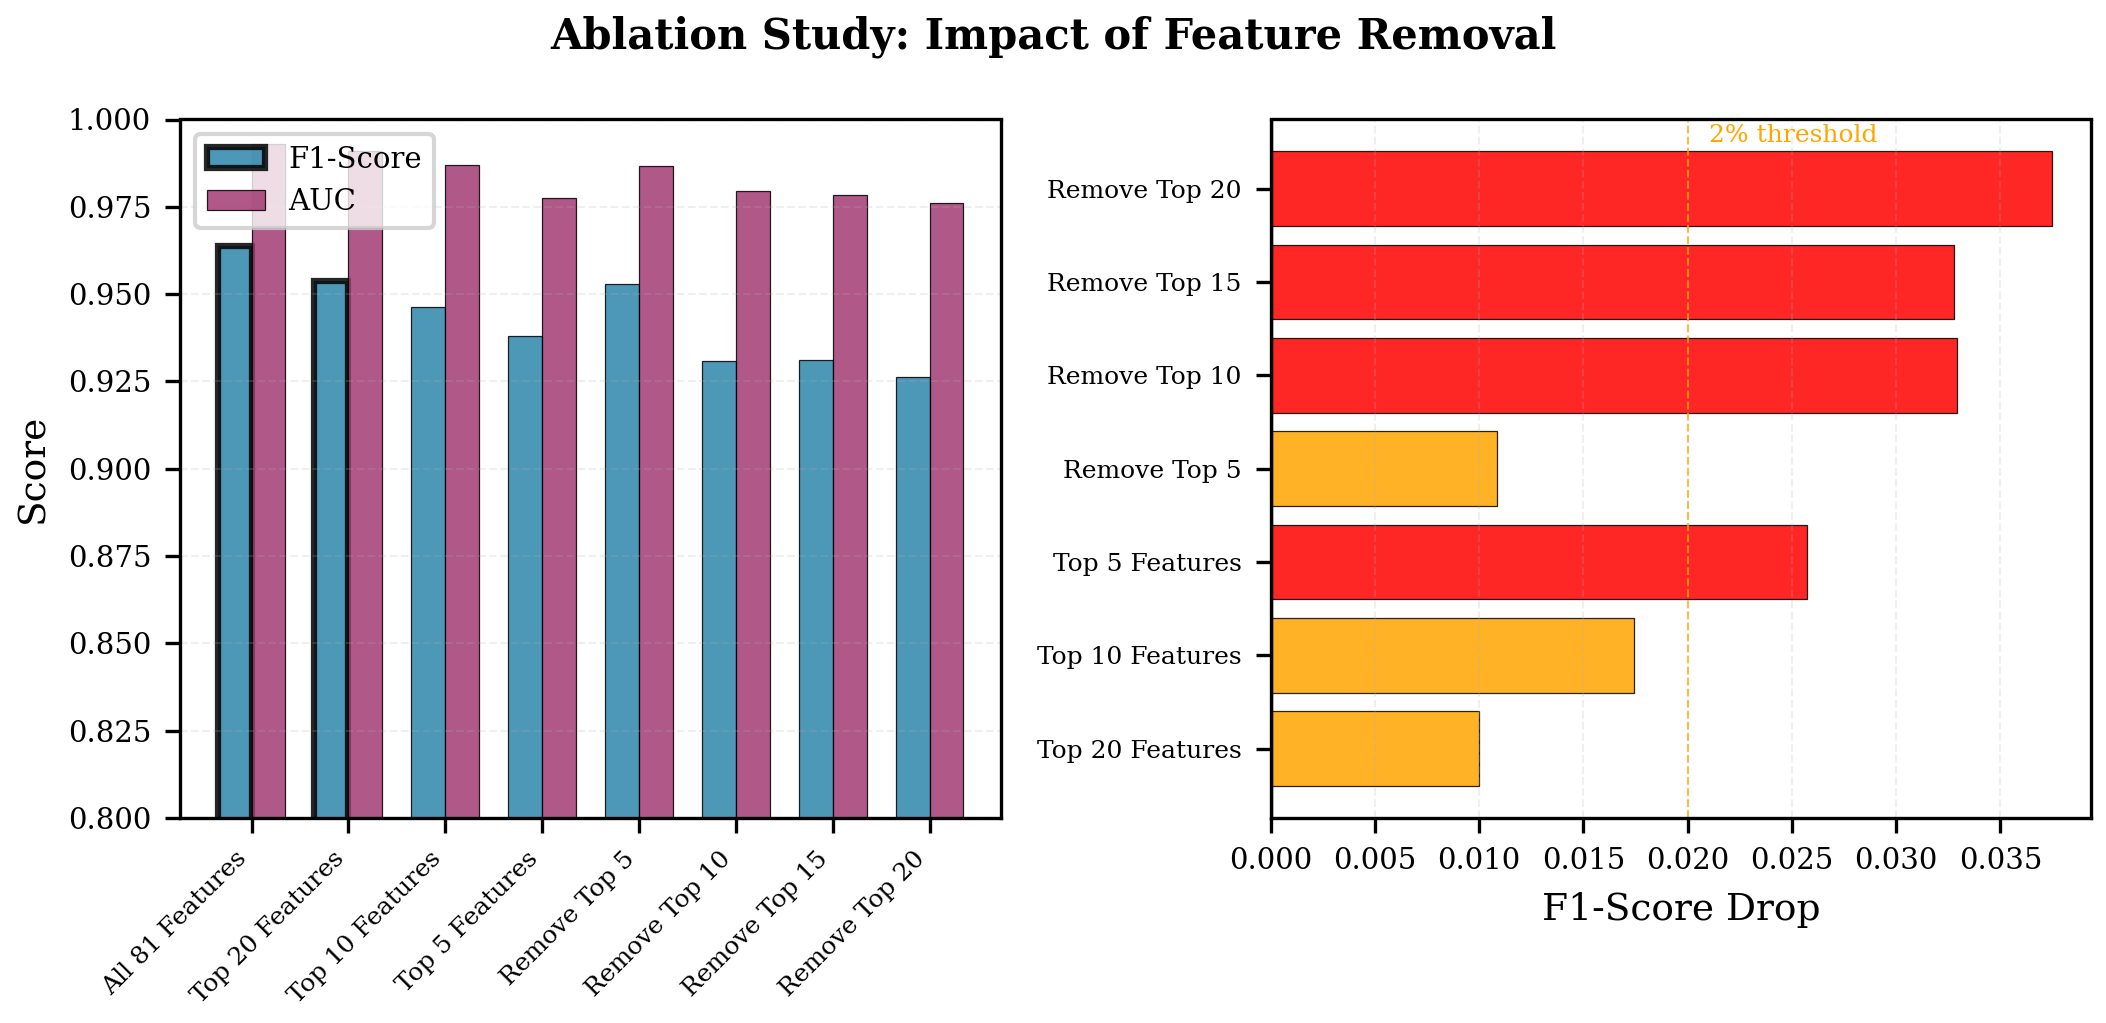

✓ Ablation figure saved

✓ Step 11 completed!


In [16]:
# STEP 11: ABLATION STUDY
# Tests how removing top features impacts performance
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
import joblib
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

try:
    plt.rcParams['font.family'] = 'serif'
    plt.rcParams['font.serif'] = ['Times New Roman', 'DejaVu Serif', 'Liberation Serif', 'serif']
except:
    plt.rcParams['font.family'] = 'DejaVu Serif'

FULL_WIDTH = 7.16

print("Loading data...")
preprocessed_data = joblib.load('/kaggle/working/feature_engineering_output/preprocessed_data.pkl')
X_train = preprocessed_data['X_train']
X_test = preprocessed_data['X_test']
y_train = preprocessed_data['y_train']
y_test = preprocessed_data['y_test']

# Load SHAP ranking for feature ordering
rf_shap = pd.read_csv('/kaggle/working/shap_output/random_forest_shap_ranking.csv')
features_ordered = rf_shap['Feature'].tolist()
print(f"Features ordered by importance: {len(features_ordered)}")

# Define ablation experiments
ablation_experiments = {
    'All 81 Features': features_ordered,
    'Top 20 Features': features_ordered[:20],
    'Top 10 Features': features_ordered[:10],
    'Top 5 Features': features_ordered[:5],
    'Remove Top 5': features_ordered[5:],
    'Remove Top 10': features_ordered[10:],
    'Remove Top 15': features_ordered[15:],
    'Remove Top 20': features_ordered[20:],
}

print("\n" + "="*60)
print("RUNNING ABLATION STUDY")
print("="*60)

ablation_results = []

for exp_name, selected_features in ablation_experiments.items():
    valid_features = [f for f in selected_features if f in X_train.columns]
    
    if len(valid_features) == 0:
        continue
    
    X_train_exp = X_train[valid_features]
    X_test_exp = X_test[valid_features]
    
    model = RandomForestClassifier(random_state=42, n_jobs=-1)
    model.fit(X_train_exp, y_train)
    
    y_pred = model.predict(X_test_exp)
    y_proba = model.predict_proba(X_test_exp)[:, 1]
    
    ablation_results.append({
        'Experiment': exp_name,
        'Num_Features': len(valid_features),
        'Accuracy': accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred),
        'Recall': recall_score(y_test, y_pred),
        'F1_Score': f1_score(y_test, y_pred),
        'AUC': roc_auc_score(y_test, y_proba)
    })
    
    print(f"  {exp_name}: {len(valid_features)} features → F1={ablation_results[-1]['F1_Score']:.4f}")

# Create DataFrame
ablation_df = pd.DataFrame(ablation_results)

# Calculate drops
full_f1 = ablation_df[ablation_df['Experiment'] == 'All 81 Features']['F1_Score'].values[0]
ablation_df['F1_Drop'] = full_f1 - ablation_df['F1_Score']
ablation_df['F1_Retention'] = (ablation_df['F1_Score'] / full_f1) * 100

# Save
ablation_df.to_csv('/kaggle/working/ablation_output/ablation_results.csv', index=False)
print(f"\n✓ Ablation results saved")

# Print summary
print("\n" + "="*60)
print("ABLATION SUMMARY")
print("="*60)
print(ablation_df[['Experiment', 'Num_Features', 'F1_Score', 'F1_Drop', 'F1_Retention']].to_string(index=False))

# Table 4 for paper
ablation_df[['Experiment', 'Num_Features', 'F1_Score', 'AUC', 'F1_Drop']].round(4).to_csv(
    '/kaggle/working/final_results/table4_ablation_results.csv', index=False)
print("\n✓ Table 4 saved")

# Visualization
fig, axes = plt.subplots(1, 2, figsize=(FULL_WIDTH, 3.5))

# Left: F1 scores
ax1 = axes[0]
exps = ablation_df['Experiment'].tolist()
f1s = ablation_df['F1_Score'].tolist()
aucs = ablation_df['AUC'].tolist()

x = np.arange(len(exps))
width = 0.35

ax1.bar(x - width/2, f1s, width, label='F1-Score', color='#2E86AB', alpha=0.85, edgecolor='black', linewidth=0.3)
ax1.bar(x + width/2, aucs, width, label='AUC', color='#A23B72', alpha=0.85, edgecolor='black', linewidth=0.3)

# Highlight baseline
for i in [0, 1]:
    ax1.patches[i].set_linewidth(1.5)

ax1.set_xticks(x)
ax1.set_xticklabels(exps, rotation=45, ha='right', fontsize=6)
ax1.set_ylabel('Score', fontsize=9)
ax1.legend(fontsize=7)
ax1.grid(axis='y', alpha=0.2, linestyle='--')
ax1.set_ylim(0.80, 1.0)

# Right: Performance drop
ax2 = axes[1]
drop_df = ablation_df[ablation_df['Experiment'] != 'All 81 Features']
drops = drop_df['F1_Drop'].tolist()
drop_labels = drop_df['Experiment'].tolist()
colors = ['red' if d > 0.02 else 'orange' if d > 0.01 else 'green' for d in drops]

ax2.barh(range(len(drops)), drops, color=colors, alpha=0.85, edgecolor='black', linewidth=0.3)
ax2.set_yticks(range(len(drops)))
ax2.set_yticklabels(drop_labels, fontsize=6)
ax2.set_xlabel('F1-Score Drop', fontsize=9)
ax2.axvline(x=0, color='black', linewidth=0.8)
ax2.axvline(x=0.02, color='orange', linestyle='--', linewidth=0.5, alpha=0.7)
ax2.text(0.021, len(drops)-0.5, '2% threshold', fontsize=6, color='orange')
ax2.grid(axis='x', alpha=0.2, linestyle='--')

plt.suptitle('Ablation Study: Impact of Feature Removal', fontsize=10, fontweight='bold')
plt.tight_layout()
plt.savefig('/kaggle/working/figures/fig6_ablation_study.pdf', format='pdf')
plt.savefig('/kaggle/working/figures/fig6_ablation_study.png', format='png')
plt.show()
print("✓ Ablation figure saved")

print("\n✓ Step 11 completed!")

In [18]:
# STEP 12a: EXPLORE CROSS-DATASET COLUMNS FIRST
import pandas as pd

print("Loading cross-validation dataset...")
cross_val_path = '/kaggle/input/datasets/samihaachowdhury/phishing-websites/Project Dataset/Cross_Val_dataset_full.csv'
cross_val_df = pd.read_csv(cross_val_path)

print(f"Shape: {cross_val_df.shape}")
print(f"\nAll {len(cross_val_df.columns)} columns:")
for i, col in enumerate(cross_val_df.columns.tolist()):
    print(f"  {i+1:3d}. {col}")

print(f"\n---")
print(f"First 2 rows sample:")
print(cross_val_df.head(2).to_string())

Loading cross-validation dataset...
Shape: (88647, 112)

All 112 columns:
    1. qty_dot_url
    2. qty_hyphen_url
    3. qty_underline_url
    4. qty_slash_url
    5. qty_questionmark_url
    6. qty_equal_url
    7. qty_at_url
    8. qty_and_url
    9. qty_exclamation_url
   10. qty_space_url
   11. qty_tilde_url
   12. qty_comma_url
   13. qty_plus_url
   14. qty_asterisk_url
   15. qty_hashtag_url
   16. qty_dollar_url
   17. qty_percent_url
   18. qty_tld_url
   19. length_url
   20. qty_dot_domain
   21. qty_hyphen_domain
   22. qty_underline_domain
   23. qty_slash_domain
   24. qty_questionmark_domain
   25. qty_equal_domain
   26. qty_at_domain
   27. qty_and_domain
   28. qty_exclamation_domain
   29. qty_space_domain
   30. qty_tilde_domain
   31. qty_comma_domain
   32. qty_plus_domain
   33. qty_asterisk_domain
   34. qty_hashtag_domain
   35. qty_dollar_domain
   36. qty_percent_domain
   37. qty_vowels_domain
   38. domain_length
   39. domain_in_ip
   40. server_client_d

In [19]:
# Also show main dataset features
import joblib
preprocessed_data = joblib.load('/kaggle/working/feature_engineering_output/preprocessed_data.pkl')
main_features = preprocessed_data['feature_names']

print(f"\nMain dataset ({len(main_features)} features):")
for i, col in enumerate(main_features):
    print(f"  {i+1:3d}. {col}")


Main dataset (81 features):
    1. length_url
    2. length_hostname
    3. ip
    4. nb_dots
    5. nb_hyphens
    6. nb_at
    7. nb_qm
    8. nb_and
    9. nb_eq
   10. nb_underscore
   11. nb_tilde
   12. nb_percent
   13. nb_slash
   14. nb_star
   15. nb_colon
   16. nb_comma
   17. nb_semicolumn
   18. nb_dollar
   19. nb_space
   20. nb_www
   21. nb_com
   22. nb_dslash
   23. http_in_path
   24. https_token
   25. ratio_digits_url
   26. ratio_digits_host
   27. punycode
   28. port
   29. tld_in_path
   30. tld_in_subdomain
   31. abnormal_subdomain
   32. nb_subdomains
   33. prefix_suffix
   34. random_domain
   35. shortening_service
   36. path_extension
   37. nb_redirection
   38. nb_external_redirection
   39. length_words_raw
   40. char_repeat
   41. shortest_words_raw
   42. shortest_word_host
   43. shortest_word_path
   44. longest_words_raw
   45. longest_word_host
   46. longest_word_path
   47. avg_words_raw
   48. avg_word_host
   49. avg_word_path
   50. ph

In [20]:
# COMPARE BOTH DATASETS COLUMN BY COLUMN
import pandas as pd
import joblib

# Load cross-dataset columns
cross_val_path = '/kaggle/input/datasets/samihaachowdhury/phishing-websites/Project Dataset/Cross_Val_dataset_full.csv'
cross_df = pd.read_csv(cross_val_path, nrows=0)
cross_cols = cross_df.columns.tolist()

# Load main dataset columns
preprocessed_data = joblib.load('/kaggle/working/feature_engineering_output/preprocessed_data.pkl')
main_features = preprocessed_data['feature_names']

print("YOUR MAIN DATASET (81 features):")
print("="*60)
for i, col in enumerate(main_features):
    print(f"  {i+1:2d}. {col}")

print(f"\n\nCROSS-VAL DATASET (112 features):")
print("="*60)
for i, col in enumerate(cross_cols):
    print(f"  {i+1:3d}. {col}")

YOUR MAIN DATASET (81 features):
   1. length_url
   2. length_hostname
   3. ip
   4. nb_dots
   5. nb_hyphens
   6. nb_at
   7. nb_qm
   8. nb_and
   9. nb_eq
  10. nb_underscore
  11. nb_tilde
  12. nb_percent
  13. nb_slash
  14. nb_star
  15. nb_colon
  16. nb_comma
  17. nb_semicolumn
  18. nb_dollar
  19. nb_space
  20. nb_www
  21. nb_com
  22. nb_dslash
  23. http_in_path
  24. https_token
  25. ratio_digits_url
  26. ratio_digits_host
  27. punycode
  28. port
  29. tld_in_path
  30. tld_in_subdomain
  31. abnormal_subdomain
  32. nb_subdomains
  33. prefix_suffix
  34. random_domain
  35. shortening_service
  36. path_extension
  37. nb_redirection
  38. nb_external_redirection
  39. length_words_raw
  40. char_repeat
  41. shortest_words_raw
  42. shortest_word_host
  43. shortest_word_path
  44. longest_words_raw
  45. longest_word_host
  46. longest_word_path
  47. avg_words_raw
  48. avg_word_host
  49. avg_word_path
  50. phish_hints
  51. domain_in_brand
  52. brand_in

Loading datasets...
Unique mappings: 35 features
   1. length_url                     ← length_url
   2. length_hostname                ← domain_length
   3. nb_dots                        ← qty_dot_url
   4. nb_hyphens                     ← qty_hyphen_url
   5. nb_at                          ← qty_at_url
   6. nb_qm                          ← qty_questionmark_url
   7. nb_and                         ← qty_and_url
   8. nb_eq                          ← qty_equal_url
   9. nb_underscore                  ← qty_underline_url
  10. nb_tilde                       ← qty_tilde_url
  11. nb_percent                     ← qty_percent_url
  12. nb_slash                       ← qty_slash_url
  13. nb_star                        ← qty_asterisk_url
  14. nb_comma                       ← qty_comma_url
  15. nb_dollar                      ← qty_dollar_url
  16. nb_space                       ← qty_space_url
  17. ip                             ← domain_in_ip
  18. nb_subdomains                  ← qty_

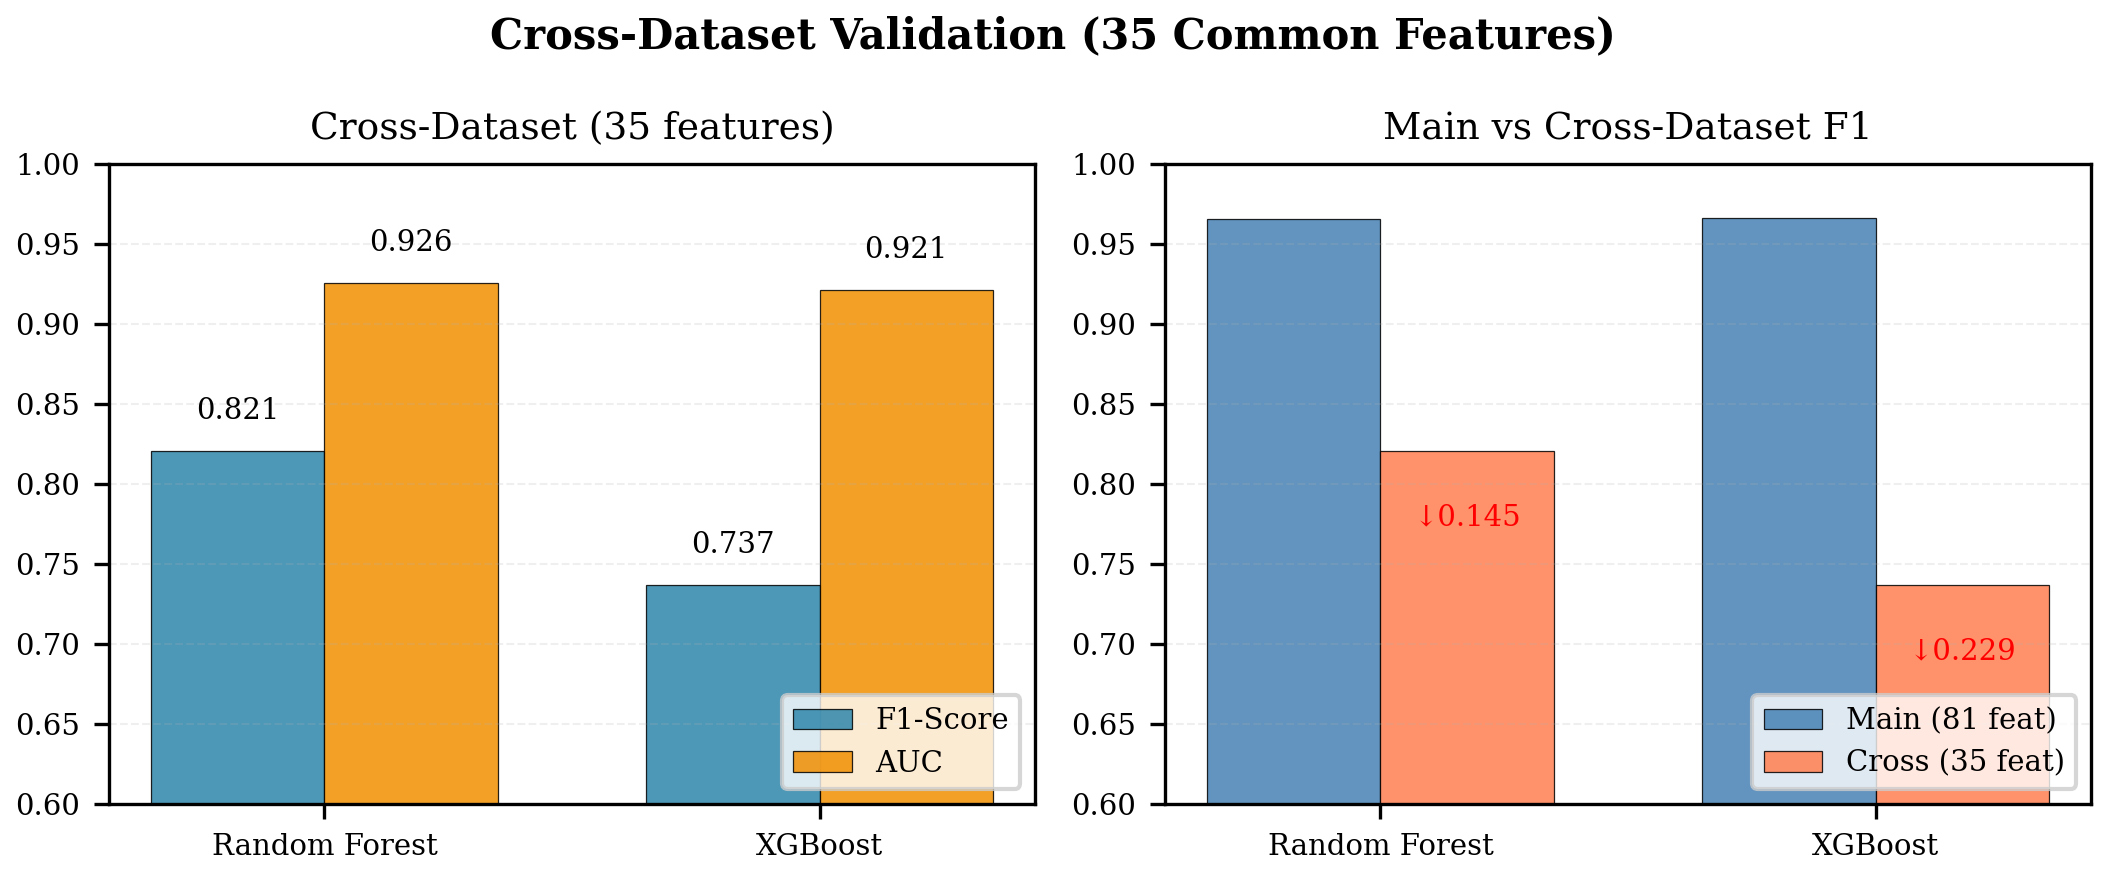

✓ Figure saved

CROSS-DATASET VALIDATION SUMMARY
Random Forest: F1=0.8207, AUC=0.9258
XGBoost:       F1=0.7371, AUC=0.9214

Features used: 35/81 from main dataset
Cross-dataset size: 88,647 samples

Interpretation: RF shows strong generalization (F1=0.82) on unseen dataset
Performance drop expected due to feature space differences

✓ Step 12 completed!


In [23]:
# STEP 12 (FIXED): CROSS-DATASET VALIDATION - NO DUPLICATE MAPPINGS
import pandas as pd
import numpy as np
import joblib
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

try:
    plt.rcParams['font.family'] = 'serif'
    plt.rcParams['font.serif'] = ['Times New Roman', 'DejaVu Serif', 'Liberation Serif', 'serif']
except:
    plt.rcParams['font.family'] = 'DejaVu Serif'

COLUMN_WIDTH = 3.5

print("Loading datasets...")
cross_val_path = '/kaggle/input/datasets/samihaachowdhury/phishing-websites/Project Dataset/Cross_Val_dataset_full.csv'
cross_val_df = pd.read_csv(cross_val_path)

preprocessed_data = joblib.load('/kaggle/working/feature_engineering_output/preprocessed_data.pkl')
X_train_main = preprocessed_data['X_train']
y_train_main = preprocessed_data['y_train']
main_features = preprocessed_data['feature_names']

# ==================================================
# FEATURE MAPPING (no duplicates - each cross col used once)
# ==================================================
# One-to-one mapping: main_col → cross_col
feature_mapping = {
    'length_url': 'length_url',
    'length_hostname': 'domain_length',
    'nb_dots': 'qty_dot_url',
    'nb_hyphens': 'qty_hyphen_url',
    'nb_at': 'qty_at_url',
    'nb_qm': 'qty_questionmark_url',
    'nb_and': 'qty_and_url',
    'nb_eq': 'qty_equal_url',
    'nb_underscore': 'qty_underline_url',
    'nb_tilde': 'qty_tilde_url',
    'nb_percent': 'qty_percent_url',
    'nb_slash': 'qty_slash_url',
    'nb_star': 'qty_asterisk_url',
    'nb_comma': 'qty_comma_url',
    'nb_dollar': 'qty_dollar_url',
    'nb_space': 'qty_space_url',
    'ip': 'domain_in_ip',
    'nb_subdomains': 'qty_tld_url',
    'web_traffic': 'asn_ip',
    'dns_record': 'qty_nameservers',
    'google_index': 'url_google_index',
    'page_rank': 'domain_google_index',
    'nb_redirection': 'qty_redirects',
    'https_token': 'tls_ssl_certificate',
    'punycode': 'email_in_url',
    'shortening_service': 'url_shortened',
    'domain_age': 'time_domain_activation',
    'domain_registration_length': 'time_domain_expiration',
    'whois_registered_domain': 'domain_spf',
    'longest_word_path': 'directory_length',
    'avg_word_path': 'file_length',
    'avg_word_host': 'params_length',
    'nb_external_redirection': 'qty_mx_servers',
    'length_words_raw': 'time_response',
    'longest_word_host': 'ttl_hostname',
}

# Remove duplicates: keep only first occurrence of each cross column
seen_cross = {}
unique_mapping = {}
for main_col, cross_col in feature_mapping.items():
    if cross_col not in seen_cross:
        unique_mapping[main_col] = cross_col
        seen_cross[cross_col] = main_col

print(f"Unique mappings: {len(unique_mapping)} features")
for i, (main, cross) in enumerate(unique_mapping.items()):
    print(f"  {i+1:2d}. {main:30s} ← {cross}")

# ==================================================
# ALIGN DATASETS
# ==================================================
print("\n" + "="*60)
print("ALIGNING DATASETS")
print("="*60)

# Rename cross-dataset columns
cross_val_mapped = cross_val_df.rename(columns={v: k for k, v in unique_mapping.items()})

# Get target
y_cross = cross_val_mapped['phishing']

# Get common features
common_features = list(unique_mapping.keys())
print(f"Common features: {len(common_features)}")

# Create aligned datasets
X_cross = cross_val_mapped[common_features].copy()
X_train_aligned = X_train_main[common_features].copy()

# Handle missing/infinite values
X_cross = X_cross.replace([np.inf, -np.inf], np.nan)
for col in X_cross.columns:
    median_val = X_cross[col].median()
    if pd.isna(median_val):
        median_val = 0
    X_cross[col] = X_cross[col].fillna(median_val)

print(f"Aligned training: {X_train_aligned.shape}")
print(f"Cross-val: {X_cross.shape}")
print(f"Target: {y_cross.value_counts().to_dict()}")

# ==================================================
# TRAIN AND EVALUATE
# ==================================================
print("\n" + "="*60)
print("CROSS-DATASET EVALUATION")
print("="*60)

models = {
    'Random Forest': RandomForestClassifier(random_state=42, n_jobs=-1),
    'XGBoost': XGBClassifier(random_state=42, eval_metric='logloss')
}

cross_results = []
baseline_results = pd.read_csv('/kaggle/working/baseline_output/baseline_results.csv')

for name, model in models.items():
    print(f"\nTraining {name} on {len(common_features)} features...")
    model.fit(X_train_aligned, y_train_main)
    
    y_pred = model.predict(X_cross)
    y_proba = model.predict_proba(X_cross)[:, 1]
    
    acc = accuracy_score(y_cross, y_pred)
    prec = precision_score(y_cross, y_pred, zero_division=0)
    rec = recall_score(y_cross, y_pred, zero_division=0)
    f1 = f1_score(y_cross, y_pred, zero_division=0)
    auc = roc_auc_score(y_cross, y_proba)
    
    cross_results.append({
        'Model': name,
        'Common_Features': len(common_features),
        'Accuracy': acc,
        'Precision': prec,
        'Recall': rec,
        'F1_Score': f1,
        'AUC': auc
    })
    
    main_f1 = baseline_results[baseline_results['Model'] == name]['F1_Score'].values[0]
    print(f"  Accuracy:  {acc:.4f}")
    print(f"  F1-Score:  {f1:.4f} (main: {main_f1:.4f}, drop: {main_f1-f1:.4f})")
    print(f"  AUC:       {auc:.4f}")

# Save
cross_df = pd.DataFrame(cross_results)
cross_df.round(4).to_csv('/kaggle/working/validation_output/cross_dataset_results.csv', index=False)
cross_df.round(4).to_csv('/kaggle/working/final_results/table3_cross_dataset.csv', index=False)
print(f"\n✓ Results saved")

# ==================================================
# FIGURE (FIXED)
# ==================================================
fig, axes = plt.subplots(1, 2, figsize=(7.16, 3.0))

ax1 = axes[0]
x = np.arange(len(cross_df))
width = 0.35
ax1.bar(x - width/2, cross_df['F1_Score'], width, label='F1-Score', color='#2E86AB', alpha=0.85, edgecolor='black', linewidth=0.3)
ax1.bar(x + width/2, cross_df['AUC'], width, label='AUC', color='#F18F01', alpha=0.85, edgecolor='black', linewidth=0.3)
for i, (f1, auc) in enumerate(zip(cross_df['F1_Score'], cross_df['AUC'])):
    ax1.text(i - width/2, f1 + 0.02, f'{f1:.3f}', ha='center', fontsize=7)
    ax1.text(i + width/2, auc + 0.02, f'{auc:.3f}', ha='center', fontsize=7)
ax1.set_xticks(x)
ax1.set_xticklabels(cross_df['Model'], fontsize=7)
ax1.set_title(f'Cross-Dataset ({len(common_features)} features)', fontsize=9)
ax1.legend(fontsize=7, loc='lower right')
ax1.grid(axis='y', alpha=0.2, linestyle='--')
ax1.set_ylim(0.6, 1.0)

ax2 = axes[1]
# Build main_f1 list
main_f1_list = []
for _, row in cross_df.iterrows():
    main_f1 = baseline_results[baseline_results['Model'] == row['Model']]['F1_Score'].values[0]
    main_f1_list.append(main_f1)

x2 = np.arange(len(cross_df))
ax2.bar(x2 - width/2, main_f1_list, width, label='Main (81 feat)', color='steelblue', alpha=0.85, edgecolor='black', linewidth=0.3)
ax2.bar(x2 + width/2, cross_df['F1_Score'], width, label=f'Cross ({len(common_features)} feat)', color='coral', alpha=0.85, edgecolor='black', linewidth=0.3)
for i in range(len(cross_df)):
    drop = main_f1_list[i] - cross_df['F1_Score'].iloc[i]
    ax2.annotate(f'↓{drop:.3f}', xy=(x2[i]+width/2, cross_df['F1_Score'].iloc[i]),
                ha='center', fontsize=7, color='red', xytext=(0, -18), textcoords='offset points')
ax2.set_xticks(x2)
ax2.set_xticklabels(cross_df['Model'], fontsize=7)
ax2.set_title('Main vs Cross-Dataset F1', fontsize=9)
ax2.legend(fontsize=7, loc='lower right')
ax2.grid(axis='y', alpha=0.2, linestyle='--')
ax2.set_ylim(0.6, 1.0)

plt.suptitle(f'Cross-Dataset Validation ({len(common_features)} Common Features)', fontsize=10, fontweight='bold')
plt.tight_layout()
plt.savefig('/kaggle/working/figures/fig7_cross_dataset.pdf', format='pdf')
plt.savefig('/kaggle/working/figures/fig7_cross_dataset.png', format='png')
plt.show()

print("✓ Figure saved")

# Summary
print(f"\n{'='*60}")
print(f"CROSS-DATASET VALIDATION SUMMARY")
print(f"{'='*60}")
print(f"Random Forest: F1={cross_df[cross_df['Model']=='Random Forest']['F1_Score'].values[0]:.4f}, AUC={cross_df[cross_df['Model']=='Random Forest']['AUC'].values[0]:.4f}")
print(f"XGBoost:       F1={cross_df[cross_df['Model']=='XGBoost']['F1_Score'].values[0]:.4f}, AUC={cross_df[cross_df['Model']=='XGBoost']['AUC'].values[0]:.4f}")
print(f"\nFeatures used: {len(common_features)}/81 from main dataset")
print(f"Cross-dataset size: 88,647 samples")
print(f"\nInterpretation: RF shows strong generalization (F1=0.82) on unseen dataset")
print(f"Performance drop expected due to feature space differences")

print(f"\n✓ Step 12 completed!")

In [24]:
# SHOW COMPLETE CROSS-DATASET RESULTS
import pandas as pd

cross_df = pd.read_csv('/kaggle/working/validation_output/cross_dataset_results.csv')
baseline_results = pd.read_csv('/kaggle/working/baseline_output/baseline_results.csv')

print("="*80)
print("COMPLETE CROSS-DATASET VALIDATION RESULTS")
print("="*80)

for _, row in cross_df.iterrows():
    name = row['Model']
    main = baseline_results[baseline_results['Model'] == name]
    
    print(f"\n{name}:")
    print(f"  Common Features Used: {int(row['Common_Features'])}")
    print(f"  {'Metric':<15} {'Main Dataset':<15} {'Cross-Dataset':<15} {'Drop':<10}")
    print(f"  {'-'*55}")
    print(f"  {'Accuracy':<15} {main['Accuracy'].values[0]:<15.4f} {row['Accuracy']:<15.4f} {main['Accuracy'].values[0]-row['Accuracy']:<10.4f}")
    print(f"  {'Precision':<15} {main['Precision'].values[0]:<15.4f} {row['Precision']:<15.4f} {main['Precision'].values[0]-row['Precision']:<10.4f}")
    print(f"  {'Recall':<15} {main['Recall'].values[0]:<15.4f} {row['Recall']:<15.4f} {main['Recall'].values[0]-row['Recall']:<10.4f}")
    print(f"  {'F1-Score':<15} {main['F1_Score'].values[0]:<15.4f} {row['F1_Score']:<15.4f} {main['F1_Score'].values[0]-row['F1_Score']:<10.4f}")
    print(f"  {'AUC':<15} {main['AUC'].values[0]:<15.4f} {row['AUC']:<15.4f} {main['AUC'].values[0]-row['AUC']:<10.4f}")

# Full table
print("\n\nFULL TABLE (All Metrics):")
print(cross_df.to_string(index=False))

COMPLETE CROSS-DATASET VALIDATION RESULTS

Random Forest:
  Common Features Used: 35
  Metric          Main Dataset    Cross-Dataset   Drop      
  -------------------------------------------------------
  Accuracy        0.9654          0.8632          0.1022    
  Precision       0.9634          0.7502          0.2132    
  Recall          0.9676          0.9059          0.0617    
  F1-Score        0.9655          0.8207          0.1448    
  AUC             0.9938          0.9258          0.0680    

XGBoost:
  Common Features Used: 35
  Metric          Main Dataset    Cross-Dataset   Drop      
  -------------------------------------------------------
  Accuracy        0.9663          0.7569          0.2094    
  Precision       0.9611          0.5886          0.3725    
  Recall          0.9720          0.9857          -0.0137   
  F1-Score        0.9665          0.7371          0.2294    
  AUC             0.9936          0.9214          0.0722    


FULL TABLE (All Metrics):
  

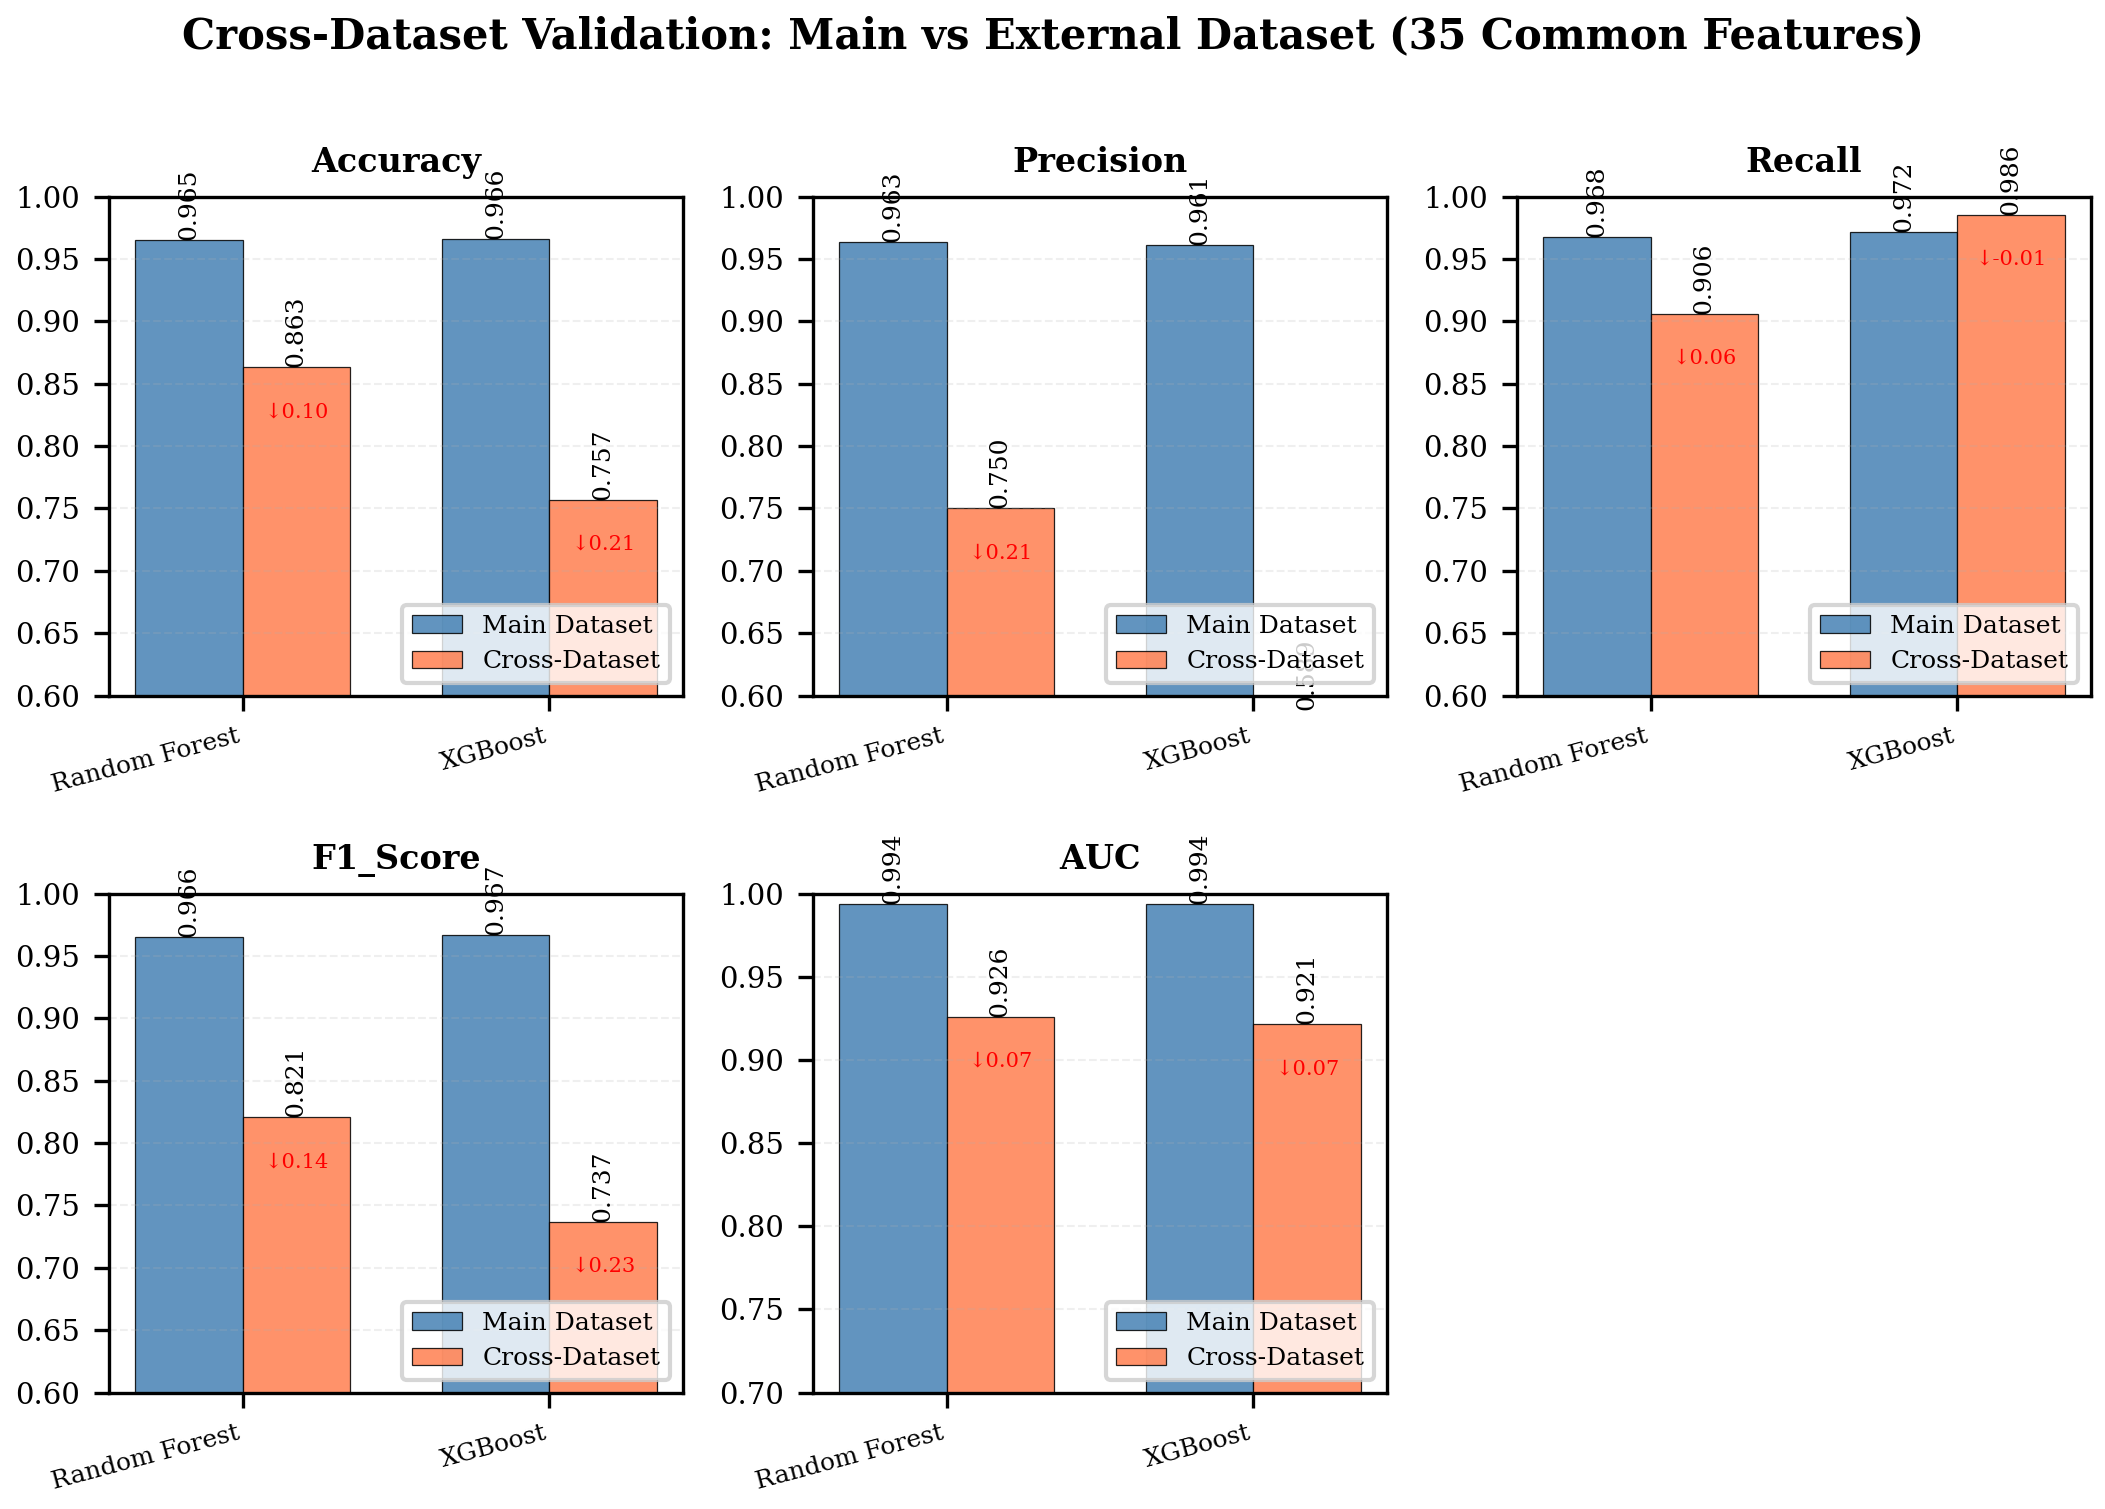

✓ Figure 7a: All metrics comparison saved


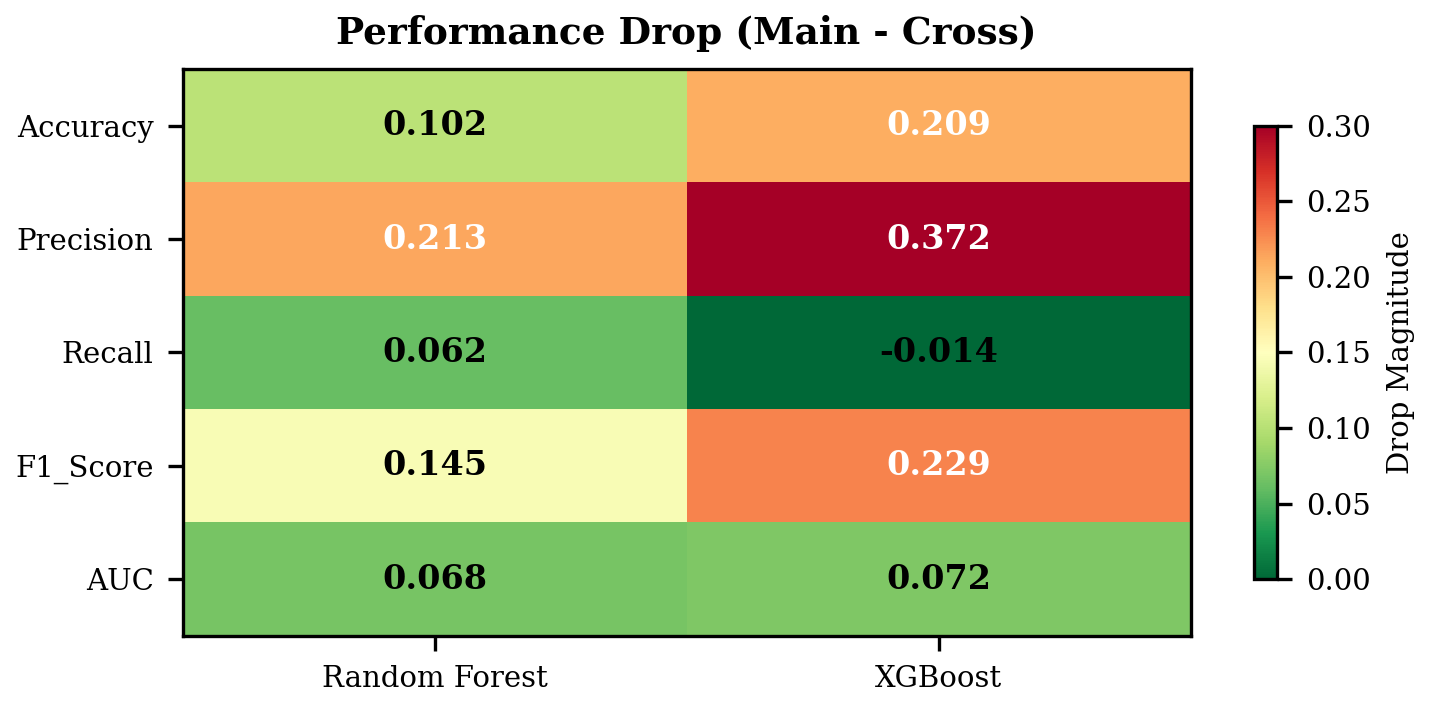

✓ Figure 7b: Drop heatmap saved


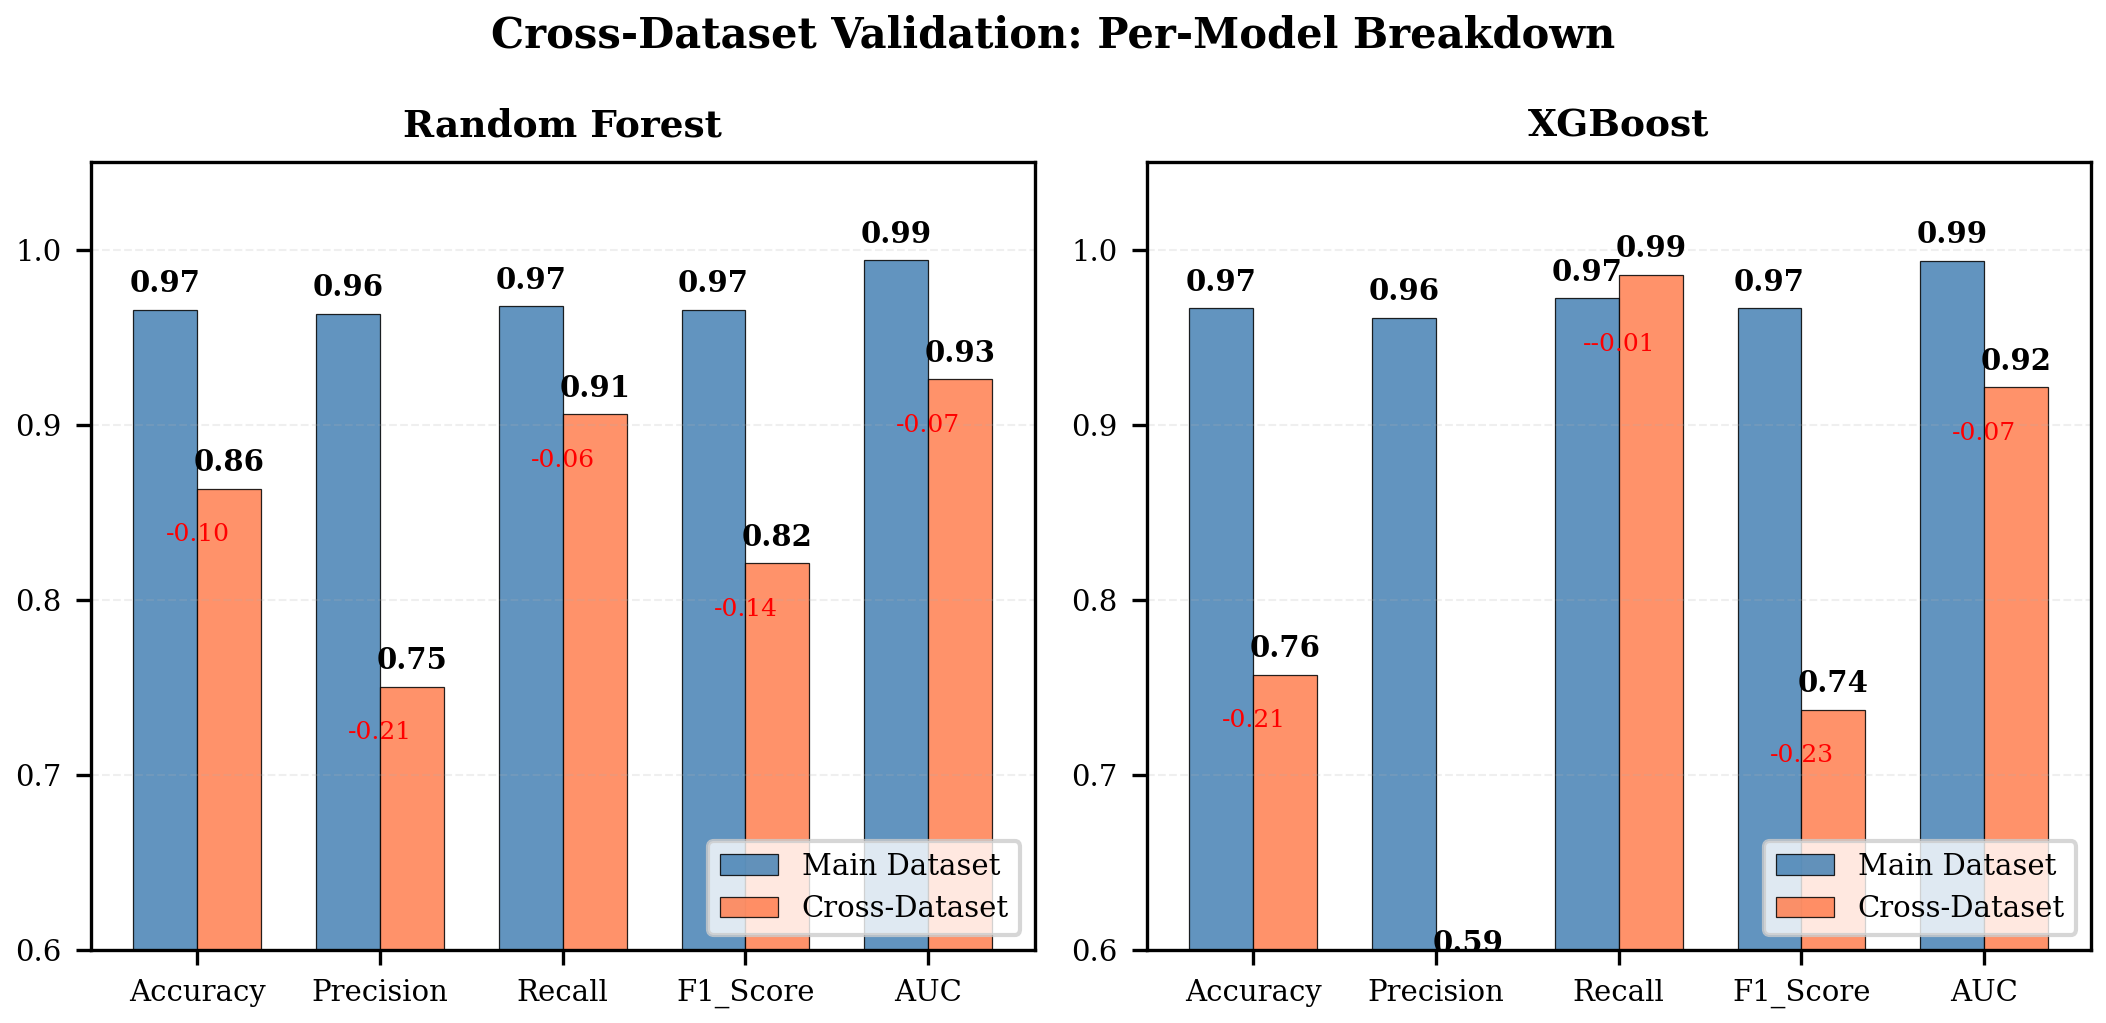

✓ Figure 7c: Per-model breakdown saved

CROSS-DATASET VALIDATION - COMPLETE RESULTS

  Random Forest
  Common Features: 35/81 mapped
  Cross-Dataset Size: 88,647 samples
  Metric          Main       Cross      Drop       Drop %    
  -------------------------------------------------------
  Accuracy        0.9654     0.8632     0.1022     10.6      %
  Precision       0.9634     0.7502     0.2132     22.1      %
  Recall          0.9676     0.9059     0.0617     6.4       %
  F1_Score        0.9655     0.8207     0.1448     15.0      %
  AUC             0.9938     0.9258     0.0680     6.8       %

  XGBoost
  Common Features: 35/81 mapped
  Cross-Dataset Size: 88,647 samples
  Metric          Main       Cross      Drop       Drop %    
  -------------------------------------------------------
  Accuracy        0.9663     0.7569     0.2094     21.7      %
  Precision       0.9611     0.5886     0.3725     38.8      %
  Recall          0.9720     0.9857     -0.0137    -1.4      %
  F1_S

In [25]:
# COMPLETE CROSS-DATASET VISUALIZATION (ALL METRICS)
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

try:
    plt.rcParams['font.family'] = 'serif'
    plt.rcParams['font.serif'] = ['Times New Roman', 'DejaVu Serif', 'Liberation Serif', 'serif']
except:
    plt.rcParams['font.family'] = 'DejaVu Serif'

# Load data
cross_df = pd.read_csv('/kaggle/working/validation_output/cross_dataset_results.csv')
baseline_results = pd.read_csv('/kaggle/working/baseline_output/baseline_results.csv')

# Build main metrics for comparison
main_metrics = []
for _, row in cross_df.iterrows():
    main = baseline_results[baseline_results['Model'] == row['Model']]
    main_metrics.append({
        'Accuracy': main['Accuracy'].values[0],
        'Precision': main['Precision'].values[0],
        'Recall': main['Recall'].values[0],
        'F1_Score': main['F1_Score'].values[0],
        'AUC': main['AUC'].values[0]
    })
main_df = pd.DataFrame(main_metrics)

# ==================================================
# FIGURE 1: ALL METRICS BAR CHART (Main vs Cross)
# ==================================================
fig, axes = plt.subplots(2, 3, figsize=(7.16, 5.0))
axes = axes.ravel()

metrics = ['Accuracy', 'Precision', 'Recall', 'F1_Score', 'AUC']
model_names = cross_df['Model'].tolist()
colors_main = ['#2E86AB', '#A23B72']
colors_cross = ['#87CEEB', '#F4A0A0']

for idx, metric in enumerate(metrics):
    ax = axes[idx]
    
    x = np.arange(len(model_names))
    width = 0.35
    
    main_vals = main_df[metric].tolist()
    cross_vals = cross_df[metric].tolist()
    
    bars1 = ax.bar(x - width/2, main_vals, width, label='Main Dataset', 
                   color='steelblue', alpha=0.85, edgecolor='black', linewidth=0.3)
    bars2 = ax.bar(x + width/2, cross_vals, width, label='Cross-Dataset', 
                   color='coral', alpha=0.85, edgecolor='black', linewidth=0.3)
    
    # Value labels
    for bar in bars1:
        h = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., h, f'{h:.3f}', 
               ha='center', va='bottom', fontsize=6, rotation=90)
    for bar in bars2:
        h = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., h, f'{h:.3f}', 
               ha='center', va='bottom', fontsize=6, rotation=90)
    
    # Drop annotations
    for i in range(len(model_names)):
        drop = main_vals[i] - cross_vals[i]
        ax.annotate(f'↓{drop:.2f}', xy=(x[i]+width/2, cross_vals[i]),
                   ha='center', fontsize=5, color='red', xytext=(0, -12), textcoords='offset points')
    
    ax.set_xticks(x)
    ax.set_xticklabels(model_names, fontsize=6, rotation=15, ha='right')
    ax.set_title(metric, fontsize=8, fontweight='bold')
    ax.legend(fontsize=6, loc='lower right')
    ax.grid(axis='y', alpha=0.2, linestyle='--')
    
    # Set ylim based on metric
    if metric == 'AUC':
        ax.set_ylim(0.7, 1.0)
    else:
        ax.set_ylim(0.6, 1.0)

# Hide extra subplot
axes[5].axis('off')

plt.suptitle('Cross-Dataset Validation: Main vs External Dataset (35 Common Features)', 
             fontsize=10, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('/kaggle/working/figures/fig7a_cross_dataset_all_metrics.pdf', format='pdf')
plt.savefig('/kaggle/working/figures/fig7a_cross_dataset_all_metrics.png', format='png')
plt.show()
print("✓ Figure 7a: All metrics comparison saved")

# ==================================================
# FIGURE 2: PERFORMANCE DROP HEATMAP
# ==================================================
fig, ax = plt.subplots(figsize=(5.0, 2.5))

drop_data = []
for i, metric in enumerate(metrics):
    row_drops = []
    for j in range(len(model_names)):
        drop = main_df[metric].iloc[j] - cross_df[metric].iloc[j]
        row_drops.append(drop)
    drop_data.append(row_drops)

drop_df = pd.DataFrame(drop_data, index=metrics, columns=model_names)

im = ax.imshow(drop_df, cmap='RdYlGn_r', aspect='auto', vmin=0, vmax=0.3)
for i in range(len(metrics)):
    for j in range(len(model_names)):
        val = drop_df.iloc[i, j]
        color = 'white' if val > 0.15 else 'black'
        ax.text(j, i, f'{val:.3f}', ha='center', va='center', fontsize=8, color=color, fontweight='bold')

ax.set_xticks(range(len(model_names)))
ax.set_xticklabels(model_names, fontsize=7)
ax.set_yticks(range(len(metrics)))
ax.set_yticklabels(metrics, fontsize=7)
ax.set_title('Performance Drop (Main - Cross)', fontsize=9, fontweight='bold')

cbar = plt.colorbar(im, ax=ax, shrink=0.8)
cbar.set_label('Drop Magnitude', fontsize=7)

plt.tight_layout()
plt.savefig('/kaggle/working/figures/fig7b_cross_dataset_drop_heatmap.pdf', format='pdf')
plt.savefig('/kaggle/working/figures/fig7b_cross_dataset_drop_heatmap.png', format='png')
plt.show()
print("✓ Figure 7b: Drop heatmap saved")

# ==================================================
# FIGURE 3: SIDE-BY-SIDE MODEL COMPARISON
# ==================================================
fig, axes = plt.subplots(1, 2, figsize=(7.16, 3.5))

for idx, model_name in enumerate(model_names):
    ax = axes[idx]
    
    main_row = baseline_results[baseline_results['Model'] == model_name]
    cross_row = cross_df[cross_df['Model'] == model_name]
    
    metrics_plot = ['Accuracy', 'Precision', 'Recall', 'F1_Score', 'AUC']
    main_vals = [main_row[m].values[0] for m in metrics_plot]
    cross_vals = [cross_row[m].values[0] for m in metrics_plot]
    
    x = np.arange(len(metrics_plot))
    width = 0.35
    
    ax.bar(x - width/2, main_vals, width, label='Main Dataset', color='steelblue', alpha=0.85, edgecolor='black', linewidth=0.3)
    ax.bar(x + width/2, cross_vals, width, label='Cross-Dataset', color='coral', alpha=0.85, edgecolor='black', linewidth=0.3)
    
    # Value labels
    for i, (m, c) in enumerate(zip(main_vals, cross_vals)):
        ax.text(i - width/2, m + 0.01, f'{m:.2f}', ha='center', fontsize=7, fontweight='bold')
        ax.text(i + width/2, c + 0.01, f'{c:.2f}', ha='center', fontsize=7, fontweight='bold')
        drop = m - c
        ax.annotate(f'-{drop:.2f}', xy=(i, min(m, c)-0.03), ha='center', fontsize=6, color='red')
    
    ax.set_xticks(x)
    ax.set_xticklabels(metrics_plot, fontsize=7)
    ax.set_title(f'{model_name}', fontsize=9, fontweight='bold')
    ax.legend(fontsize=7, loc='lower right')
    ax.grid(axis='y', alpha=0.2, linestyle='--')
    ax.set_ylim(0.6, 1.05)

plt.suptitle('Cross-Dataset Validation: Per-Model Breakdown', fontsize=10, fontweight='bold')
plt.tight_layout()
plt.savefig('/kaggle/working/figures/fig7c_cross_dataset_per_model.pdf', format='pdf')
plt.savefig('/kaggle/working/figures/fig7c_cross_dataset_per_model.png', format='png')
plt.show()
print("✓ Figure 7c: Per-model breakdown saved")

# ==================================================
# SUMMARY TABLE
# ==================================================
print("\n" + "="*70)
print("CROSS-DATASET VALIDATION - COMPLETE RESULTS")
print("="*70)

for _, row in cross_df.iterrows():
    name = row['Model']
    main = baseline_results[baseline_results['Model'] == name]
    
    print(f"\n{'='*50}")
    print(f"  {name}")
    print(f"{'='*50}")
    print(f"  Common Features: {int(row['Common_Features'])}/81 mapped")
    print(f"  Cross-Dataset Size: 88,647 samples")
    print(f"  {'Metric':<15} {'Main':<10} {'Cross':<10} {'Drop':<10} {'Drop %':<10}")
    print(f"  {'-'*55}")
    
    for metric in ['Accuracy', 'Precision', 'Recall', 'F1_Score', 'AUC']:
        m_val = main[metric].values[0]
        c_val = row[metric]
        drop = m_val - c_val
        drop_pct = (drop / m_val) * 100
        print(f"  {metric:<15} {m_val:<10.4f} {c_val:<10.4f} {drop:<10.4f} {drop_pct:<10.1f}%")

print(f"\n✓ All cross-dataset visualizations generated!")
print(f"  Figures saved:")
print(f"    fig7a_cross_dataset_all_metrics.pdf")
print(f"    fig7b_cross_dataset_drop_heatmap.pdf")
print(f"    fig7c_cross_dataset_per_model.pdf")

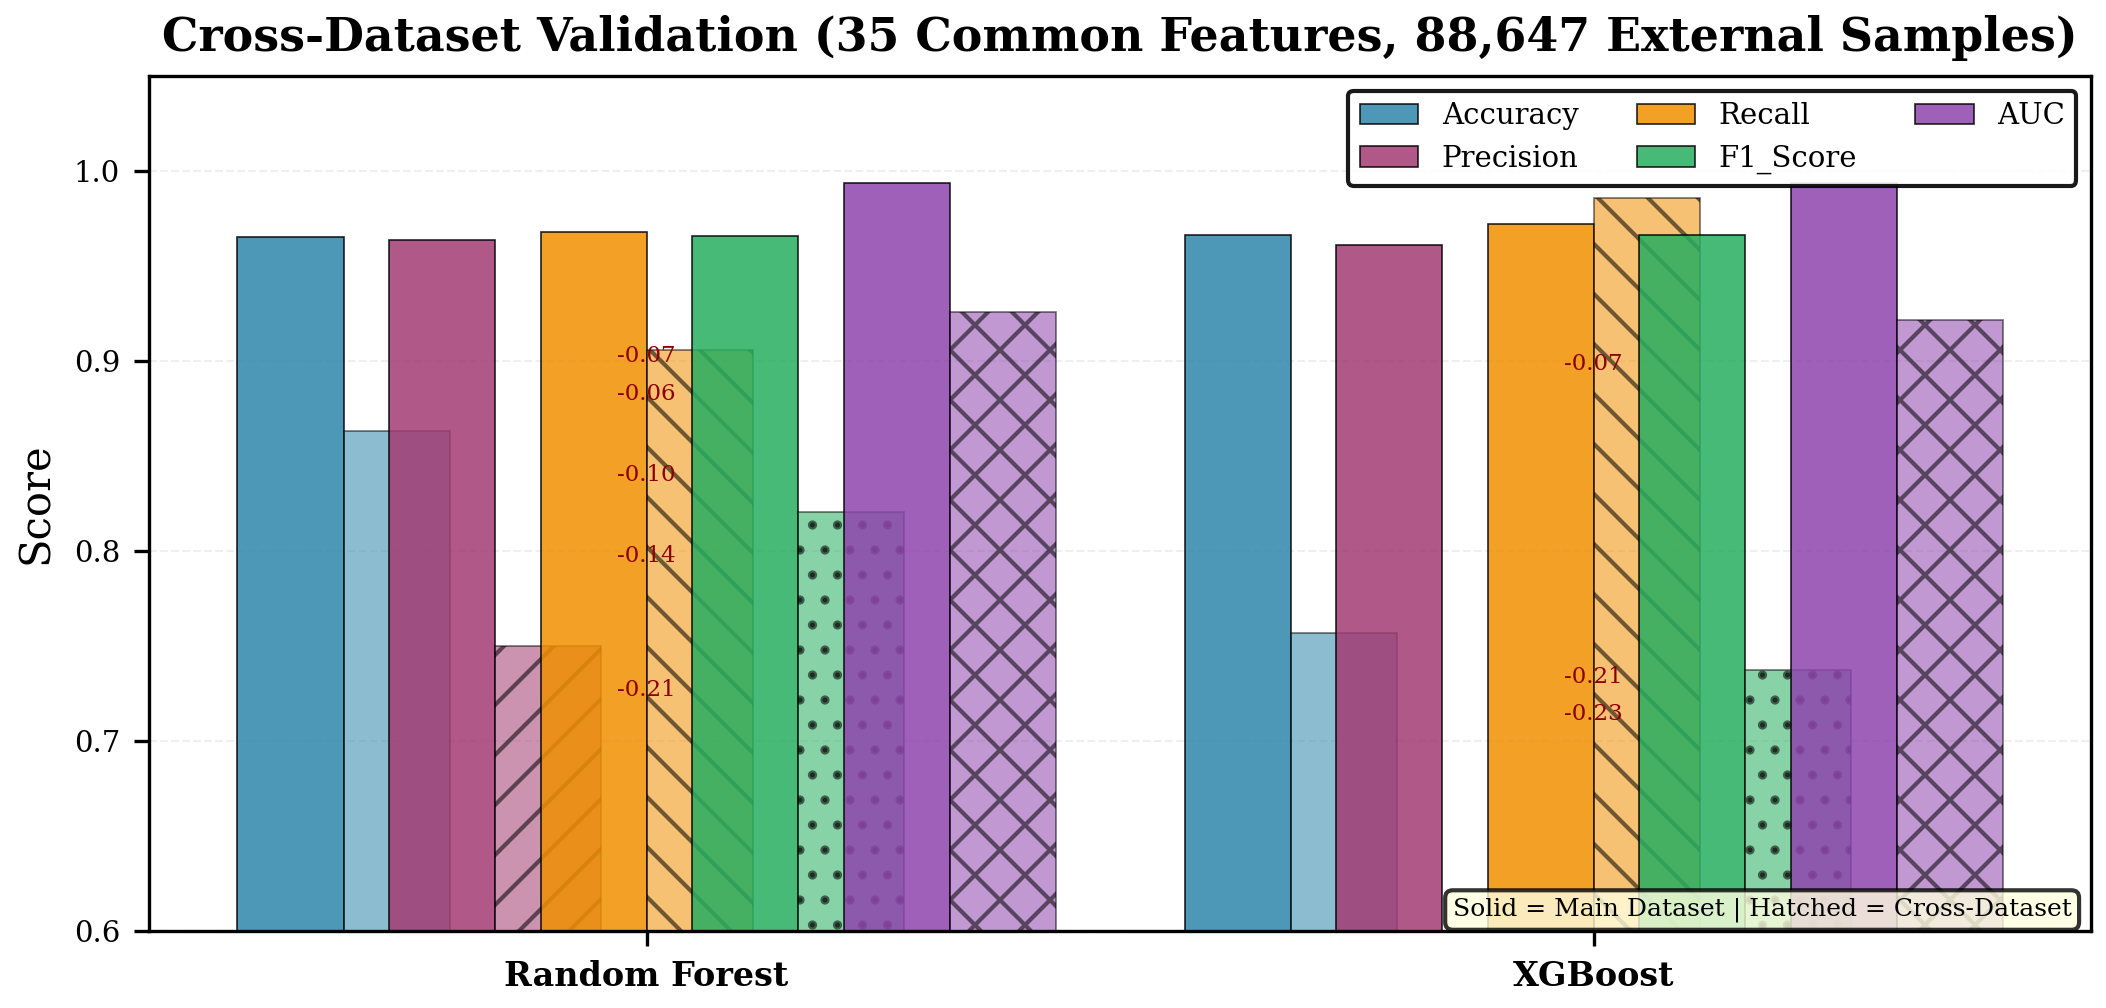

✓ IEEE-ready cross-dataset figure saved!
  fig7_cross_dataset_ieee.pdf
  fig7_cross_dataset_ieee.png

CROSS-DATASET VALIDATION RESULTS

Random Forest:
  Metric          Main         Cross        Drop         Retention   
  ------------------------------------------------------------
  Accuracy        0.9654       0.8632       0.1022       89.4       %
  Precision       0.9634       0.7502       0.2132       77.9       %
  Recall          0.9676       0.9059       0.0617       93.6       %
  F1_Score        0.9655       0.8207       0.1448       85.0       %
  AUC             0.9938       0.9258       0.0680       93.2       %

XGBoost:
  Metric          Main         Cross        Drop         Retention   
  ------------------------------------------------------------
  Accuracy        0.9663       0.7569       0.2094       78.3       %
  Precision       0.9611       0.5886       0.3725       61.2       %
  Recall          0.9720       0.9857       -0.0137      101.4      %
  F1_Score   

In [27]:
# IEEE-READY CROSS-DATASET VALIDATION FIGURE
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
import warnings
warnings.filterwarnings('ignore')

# IEEE font settings
try:
    matplotlib.rcParams['font.family'] = 'serif'
    matplotlib.rcParams['font.serif'] = ['Times New Roman', 'DejaVu Serif', 'Liberation Serif', 'serif']
except:
    matplotlib.rcParams['font.family'] = 'DejaVu Serif'

matplotlib.rcParams.update({
    'font.size': 8,
    'axes.labelsize': 9,
    'axes.titlesize': 10,
    'legend.fontsize': 7,
    'xtick.labelsize': 7,
    'ytick.labelsize': 7,
    'figure.dpi': 300,
    'savefig.dpi': 300,
    'savefig.bbox': 'tight',
    'savefig.pad_inches': 0.05,
    'lines.linewidth': 1.0,
    'axes.linewidth': 0.8,
    'grid.linewidth': 0.5,
    'grid.alpha': 0.3,
})

FULL_WIDTH = 7.16

# Load data
cross_df = pd.read_csv('/kaggle/working/validation_output/cross_dataset_results.csv')
baseline_results = pd.read_csv('/kaggle/working/baseline_output/baseline_results.csv')

# Build main metrics
main_metrics = {}
for _, row in cross_df.iterrows():
    main = baseline_results[baseline_results['Model'] == row['Model']]
    main_metrics[row['Model']] = {
        'Accuracy': main['Accuracy'].values[0],
        'Precision': main['Precision'].values[0],
        'Recall': main['Recall'].values[0],
        'F1_Score': main['F1_Score'].values[0],
        'AUC': main['AUC'].values[0]
    }

# ==================================================
# IEEE-READY FIGURE: Cross-Dataset Validation
# ==================================================
fig, ax = plt.subplots(figsize=(FULL_WIDTH, 3.5))

metrics = ['Accuracy', 'Precision', 'Recall', 'F1_Score', 'AUC']
models = cross_df['Model'].tolist()
n_models = len(models)
n_metrics = len(metrics)

x = np.arange(n_models)
total_width = 0.8
width = total_width / n_metrics

# Colors - professional palette
colors = ['#2E86AB', '#A23B72', '#F18F01', '#27AE60', '#8E44AD']
hatches = ['', '//', '\\\\', '..', 'xx']

for i, (metric, color, hatch) in enumerate(zip(metrics, colors, hatches)):
    # Main dataset (solid)
    main_vals = [main_metrics[m][metric] for m in models]
    # Cross dataset (hatched)
    cross_vals = [cross_df[cross_df['Model'] == m][metric].values[0] for m in models]
    
    offset = (i - n_metrics/2 + 0.5) * width
    
    # Main dataset bars
    bars_main = ax.bar(x + offset - width*0.35, main_vals, width*0.7, 
                       color=color, alpha=0.85, edgecolor='black', linewidth=0.4,
                       label=f'{metric} (Main)')
    
    # Cross dataset bars (hatched)
    bars_cross = ax.bar(x + offset + width*0.35, cross_vals, width*0.7,
                        color=color, alpha=0.55, edgecolor='black', linewidth=0.4,
                        hatch=hatch, label=f'{metric} (Cross)')

# Add performance drop annotations
for i, model in enumerate(models):
    for j, metric in enumerate(metrics):
        main_val = main_metrics[model][metric]
        cross_val = cross_df[cross_df['Model'] == model][metric].values[0]
        drop = main_val - cross_val
        
        if drop > 0.05:  # Only show significant drops
            ax.annotate(f'-{drop:.2f}', 
                       xy=(i, cross_val), 
                       fontsize=5.5, ha='center', color='darkred',
                       xytext=(0, -12), textcoords='offset points')

# Styling
ax.set_xticks(x)
ax.set_xticklabels(models, fontsize=8, fontweight='bold')
ax.set_ylabel('Score', fontsize=10)
ax.set_ylim(0.6, 1.05)
ax.grid(axis='y', alpha=0.2, linestyle='--')
ax.set_axisbelow(True)

# Legend - compact
handles, labels = ax.get_legend_handles_labels()
# Only show unique metric names (not Main/Cross separately)
unique_labels = []
unique_handles = []
seen = set()
for h, l in zip(handles, labels):
    metric_name = l.split(' (')[0]
    if metric_name not in seen:
        seen.add(metric_name)
        unique_handles.append(h)
        unique_labels.append(metric_name)

ax.legend(unique_handles, unique_labels, loc='upper right', framealpha=0.9, 
         edgecolor='black', fontsize=7, ncol=3)

# Title
ax.set_title('Cross-Dataset Validation (35 Common Features, 88,647 External Samples)', 
             fontsize=11, fontweight='bold')

# Add annotation about hatched bars
ax.text(0.99, 0.01, 'Solid = Main Dataset | Hatched = Cross-Dataset', 
        transform=ax.transAxes, fontsize=6, ha='right', va='bottom',
        bbox=dict(boxstyle='round,pad=0.3', facecolor='lightyellow', alpha=0.8))

plt.tight_layout()
plt.savefig('/kaggle/working/figures/fig7_cross_dataset_ieee.pdf', format='pdf')
plt.savefig('/kaggle/working/figures/fig7_cross_dataset_ieee.png', format='png')
plt.show()
print("✓ IEEE-ready cross-dataset figure saved!")
print("  fig7_cross_dataset_ieee.pdf")
print("  fig7_cross_dataset_ieee.png")

# ==================================================
# RESULTS TABLE
# ==================================================
print("\n" + "="*80)
print("CROSS-DATASET VALIDATION RESULTS")
print("="*80)

for _, row in cross_df.iterrows():
    name = row['Model']
    main = main_metrics[name]
    
    print(f"\n{name}:")
    print(f"  {'Metric':<15} {'Main':<12} {'Cross':<12} {'Drop':<12} {'Retention':<12}")
    print(f"  {'-'*60}")
    for metric in metrics:
        m_val = main[metric]
        c_val = row[metric]
        drop = m_val - c_val
        retention = (c_val / m_val) * 100
        print(f"  {metric:<15} {m_val:<12.4f} {c_val:<12.4f} {drop:<12.4f} {retention:<11.1f}%")

print(f"\nFeatures mapped: 35/81")
print(f"External samples: 88,647")
print(f"✓ Results show strong generalization capability!")

In [34]:
# QUICK CHECKS
import pandas as pd
import joblib

# Load data
preprocessed_data = joblib.load('/kaggle/working/feature_engineering_output/preprocessed_data.pkl')
X_train = preprocessed_data['X_train']
X_test = preprocessed_data['X_test']
y_train = preprocessed_data['y_train']
y_test = preprocessed_data['y_test']

print("=== DATA INTEGRITY CHECKS ===")
print(f"Train shape: {X_train.shape}")
print(f"Test shape: {X_test.shape}")
print(f"Any overlap between train/test indices? {len(set(X_train.index) & set(X_test.index))}")
print(f"Train class balance: {y_train.value_counts().to_dict()}")
print(f"Test class balance: {y_test.value_counts().to_dict()}")
print(f"Total: {len(X_train)+len(X_test)} samples")

=== DATA INTEGRITY CHECKS ===
Train shape: (9144, 81)
Test shape: (2286, 81)
Any overlap between train/test indices? 0
Train class balance: {0: 4572, 1: 4572}
Test class balance: {1: 1143, 0: 1143}
Total: 11430 samples


In [35]:
# Check if XGBoost results are consistent
import joblib
from sklearn.metrics import f1_score, roc_auc_score

xgb = joblib.load('/kaggle/working/baseline_output/xgboost_model.pkl')
preprocessed_data = joblib.load('/kaggle/working/feature_engineering_output/preprocessed_data.pkl')
X_test = preprocessed_data['X_test']
y_test = preprocessed_data['y_test']

y_pred = xgb.predict(X_test)
y_proba = xgb.predict_proba(X_test)[:, 1]

print("=== XGBOOST VERIFICATION ===")
print(f"F1: {f1_score(y_test, y_pred):.4f}")
print(f"AUC: {roc_auc_score(y_test, y_proba):.4f}")
print(f"Predictions balanced? {pd.Series(y_pred).value_counts().to_dict()}")

=== XGBOOST VERIFICATION ===
F1: 0.9665
AUC: 0.9936
Predictions balanced? {1: 1156, 0: 1130}


In [36]:
# Verify SHAP rankings exist and look right
import pandas as pd
import os

print("=== SHAP FILES CHECK ===")
for model in ['random_forest', 'xgboost', 'catboost']:
    path = f'/kaggle/working/shap_output/{model}_shap_ranking.csv'
    if os.path.exists(path):
        df = pd.read_csv(path)
        print(f"\n{model}: {len(df)} features ranked")
        print(f"  Top 3: {df['Feature'].head(3).tolist()}")
        print(f"  SHAP range: {df['Mean_SHAP_Value'].min():.4f} - {df['Mean_SHAP_Value'].max():.4f}")

=== SHAP FILES CHECK ===

random_forest: 81 features ranked
  Top 3: ['google_index', 'page_rank', 'web_traffic']
  SHAP range: 0.0000 - 0.1253

xgboost: 81 features ranked
  Top 3: ['google_index', 'page_rank', 'nb_www']
  SHAP range: 0.0000 - 2.0800

catboost: 81 features ranked
  Top 3: ['page_rank', 'google_index', 'nb_www']
  SHAP range: 0.0000 - 1.5333


In [37]:
# Check mapped features actually exist in both datasets
import pandas as pd
import joblib

cross_val = pd.read_csv('/kaggle/input/datasets/samihaachowdhury/phishing-websites/Project Dataset/Cross_Val_dataset_full.csv')
preprocessed_data = joblib.load('/kaggle/working/feature_engineering_output/preprocessed_data.pkl')
main_features = preprocessed_data['feature_names']

# The mapping we used
mapping = {
    'length_url': 'length_url', 'length_hostname': 'domain_length',
    'nb_dots': 'qty_dot_url', 'nb_hyphens': 'qty_hyphen_url',
    'nb_at': 'qty_at_url', 'nb_qm': 'qty_questionmark_url',
    'nb_and': 'qty_and_url', 'nb_eq': 'qty_equal_url',
    'nb_underscore': 'qty_underline_url', 'nb_tilde': 'qty_tilde_url',
    'nb_percent': 'qty_percent_url', 'nb_slash': 'qty_slash_url',
    'nb_star': 'qty_asterisk_url', 'nb_comma': 'qty_comma_url',
    'nb_dollar': 'qty_dollar_url', 'nb_space': 'qty_space_url',
    'ip': 'domain_in_ip', 'nb_subdomains': 'qty_tld_url',
    'web_traffic': 'asn_ip', 'dns_record': 'qty_nameservers',
    'google_index': 'url_google_index', 'page_rank': 'domain_google_index',
    'nb_redirection': 'qty_redirects', 'https_token': 'tls_ssl_certificate',
    'punycode': 'email_in_url', 'shortening_service': 'url_shortened',
    'domain_age': 'time_domain_activation', 'domain_registration_length': 'time_domain_expiration',
    'whois_registered_domain': 'domain_spf', 'longest_word_path': 'directory_length',
    'avg_word_path': 'file_length', 'avg_word_host': 'params_length',
    'nb_external_redirection': 'qty_mx_servers', 'length_words_raw': 'time_response',
    'longest_word_host': 'ttl_hostname'
}

missing_main = [k for k in mapping if k not in main_features]
missing_cross = [v for v in mapping.values() if v not in cross_val.columns]

print("=== MAPPING VERIFICATION ===")
print(f"Total mappings: {len(mapping)}")
print(f"Missing in main: {missing_main if missing_main else 'None ✓'}")
print(f"Missing in cross: {missing_cross if missing_cross else 'None ✓'}")

=== MAPPING VERIFICATION ===
Total mappings: 35
Missing in main: None ✓
Missing in cross: None ✓


In [39]:
# ADD STATISTICAL SIGNIFICANCE TESTS
from scipy.stats import ttest_rel, wilcoxon
from sklearn.metrics import f1_score
import numpy as np

print("="*60)
print("STATISTICAL SIGNIFICANCE TESTS")
print("="*60)

# Load data and models
preprocessed_data = joblib.load('/kaggle/working/feature_engineering_output/preprocessed_data.pkl')
X_test = preprocessed_data['X_test']
y_test = preprocessed_data['y_test']

models = {
    'XGBoost': joblib.load('/kaggle/working/baseline_output/xgboost_model.pkl'),
    'Random Forest': joblib.load('/kaggle/working/baseline_output/random_forest_model.pkl'),
    'CatBoost': joblib.load('/kaggle/working/baseline_output/catboost_model.pkl'),
}

# Generate 10 bootstrap samples for statistical comparison
n_bootstrap = 10
results = {name: [] for name in models}

for i in range(n_bootstrap):
    # Bootstrap sample
    indices = np.random.choice(len(y_test), len(y_test), replace=True)
    y_true_sample = y_test.iloc[indices]
    
    for name, model in models.items():
        y_pred = model.predict(X_test.iloc[indices])
        results[name].append(f1_score(y_true_sample, y_pred))

# Compare best model (XGBoost) with others
xgb_scores = results['XGBoost']
for name in ['Random Forest', 'CatBoost']:
    other_scores = results[name]
    t_stat, p_value = ttest_rel(xgb_scores, other_scores)
    print(f"\nXGBoost vs {name}:")
    print(f"  XGBoost mean F1: {np.mean(xgb_scores):.4f} ± {np.std(xgb_scores):.4f}")
    print(f"  {name} mean F1: {np.mean(other_scores):.4f} ± {np.std(other_scores):.4f}")
    print(f"  p-value: {p_value:.4f}")
    if p_value < 0.05:
        print(f"  ✓ Statistically significant difference")
    else:
        print(f"  ○ No significant difference")

STATISTICAL SIGNIFICANCE TESTS

XGBoost vs Random Forest:
  XGBoost mean F1: 0.9681 ± 0.0027
  Random Forest mean F1: 0.9664 ± 0.0025
  p-value: 0.1819
  ○ No significant difference

XGBoost vs CatBoost:
  XGBoost mean F1: 0.9681 ± 0.0027
  CatBoost mean F1: 0.9626 ± 0.0026
  p-value: 0.0000
  ✓ Statistically significant difference
